# $\nu_e$ CC Inclusive — Systematics

Loads pre-saved `sel_topo` and the mcnu weights file.  
**Outputs:** `saved_syst/` (NPZ) · `plots_syst/` (PNG)

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os, sys, gc, warnings
import numpy as np
import pandas as pd
# import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import nue_selection as nue_sel
import nue_helpers as nh

CAFPYANA_WD = '/home/castalyf/cafpyana'
for p in [CAFPYANA_WD, CAFPYANA_WD + '/pyanalib']:
    if p not in sys.path:
        sys.path.insert(0, p)

from analysis_village.unfolding.covariance import (
    get_covariance_matrix_self, get_covariance_matrix)
from analysis_village.unfolding.utils import plot_univ_hists, plot_heatmap

# ── Paths ──────────────────────────────────────────────────────────────────────
DF_OUT_DIR   = './nuecc_dfs'
SYST_DIR     = './saved_syst'
PLOT_DIR     = './plots_syst'
TARGET_POT   = 6.6e20
TITLE        = r'SBND $\nu_e$ CC Inclusive'
POT_LABEL    = r'$6.6\times10^{20}$ POT'

# sel_qual: the ONLY file needed for all analysis (POT, events, truth)
SEL_FILE = f'{DF_OUT_DIR}/selected_nuecc_qual.df'

# DF_FILE: ONLY used in Cell 3 (mct_index for weight alignment).
# MUST be the same file used when sel_qual was generated.
# DF_FILE      = '/home/castalyf/cafpyana_out/mc1e20_nueCC_test_small.df'
DF_FILE      = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC_v2.df'
LOWE_FILE        = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_lowE.df'

DATA_FILE = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/data_dev.df'
OFFBEAM_FILE = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/data_offbeamlight.df'

# WEIGHTS_FILE: universe weights (flux/GENIE reweighting)
# WEIGHTS_FILE = '/home/castalyf/cafpyana_out/mc1e20_nueCC_sys_test_small.df'
WEIGHTS_FILE = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC_sys_v2.df'
WEIGHTS_FILE_lowE = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_lowE_sys.df'

for d in [SYST_DIR, PLOT_DIR,
          f'{PLOT_DIR}/univ', f'{PLOT_DIR}/cov', f'{PLOT_DIR}/fracunc']:
    os.makedirs(d, exist_ok=True)
print('Paths OK')


Paths OK


In [2]:
def _load_hdf_key(hdf_file, key_prefix):
    with pd.HDFStore(hdf_file, mode="r") as store:
        keys = store.keys()

        # /split may exist as a raw PyTables node (not a pandas DataFrame),
        # so guard the read — don't just check membership.
        if '/split' in keys:
            try:
                split_df = store['split']
                n = int(split_df['n_split'].iloc[0])
                return pd.concat([store[f'{key_prefix}_{k}'] for k in range(n)])
            except (AttributeError, KeyError, TypeError):
                pass   # fall through to prefix-matching below

        matching = sorted(
            k for k in keys
            if k.lstrip('/').startswith(key_prefix.lstrip('/'))
        )
        if not matching:
            raise KeyError(f"No keys matching {key_prefix!r} in {hdf_file}")
        return pd.concat([store[k] for k in matching])

histpotdf = _load_hdf_key(DF_FILE, 'histpotdf')
# statsdf   = _load_hdf_key(DF_FILE, 'stats')
statsdf   = _load_hdf_key(DF_FILE, 'truth_info')

# ── Load sel_qual (the only file we need for syst analysis) ───────────────────
sel_topo = pd.read_hdf(SEL_FILE)

# Deduplicate safety guard
if sel_topo.index.duplicated().any():
    print(f'WARNING: {sel_topo.index.duplicated().sum()} duplicate rows — deduplicating')
    sel_topo = sel_topo[~sel_topo.index.duplicated(keep='first')]

print(f'sel_topo shape : {sel_topo.shape}')
print(f'sel_topo cols  : {list(sel_topo.columns)}')

# ── pot_scale: read from sel_qual — avoids any DF_FILE mismatch ───────────────
pot_scale = float(sel_topo['pot_scale'].iloc[0])

# ── n_true_signal: all is_sig==True rows (presel denominator) ─────────────────
n_true_signal = int(sel_topo['is_sig'].sum())

# ── TARGET_POT back-computed so labels are consistent ─────────────────────────
# (sel_qual stores pot_scale = TARGET_POT / sample_POT, so we use stored value)
print(f'\npot_scale     : {pot_scale:.4f}')
print(f'n_true_signal : {n_true_signal:,}  (signal in presel — efficiency denominator)')

# Quick sanity check: signal at each stage
for col in [c for c in sel_topo.columns if c.startswith('sel_')]:
    n_sig = int((sel_topo[col] & sel_topo['is_sig']).sum())
    n_tot = int(sel_topo[col].sum())
    print(f'  {col:<35} sig={n_sig:>6,}  total={n_tot:>9,}  '
          f'weighted_sig={n_sig*pot_scale:.1f}')


sel_topo shape : (980816, 16)
sel_topo cols  : ['truth_cat', 'is_sig', 'reco_ke', 'reco_costheta', 'reco_p', 'true_ke', 'true_costheta', 'true_p', 'sel_precut', 'sel_valid_flashmatch', 'sel_fiducial', 'sel_single_electron', 'sel_electron_primary_score', 'sel_electron_pid_score', 'sel_vertex_distance', 'pot_scale']

pot_scale     : 4.3862
n_true_signal : 3,797  (signal in presel — efficiency denominator)
  sel_precut                          sig= 3,797  total=  980,816  weighted_sig=16654.3
  sel_valid_flashmatch                sig= 3,797  total=  980,816  weighted_sig=16654.3
  sel_fiducial                        sig= 3,797  total=  980,816  weighted_sig=16654.3
  sel_single_electron                 sig= 3,589  total=   28,494  weighted_sig=15742.0
  sel_electron_primary_score          sig= 3,054  total=   15,278  weighted_sig=13395.4
  sel_electron_pid_score              sig= 2,484  total=    4,476  weighted_sig=10895.3
  sel_vertex_distance                 sig= 2,336  total=    3,800

In [3]:
sel_topo.to_pickle('./nuecc_dfs/selected_nuecc_qual.pkl')
print(f"Saved pickle: {sel_topo.shape}")

Saved pickle: (980816, 16)


## 2.Load all weight files and classify columns

In [31]:
def _is_univ(c):
    return isinstance(c, tuple) and any('univ' in str(p).lower() for p in c)

def _matches(c, kws):
    return isinstance(c, tuple) and any(
        any(kw in str(p).lower() for kw in kws) for p in c)

def _classify_weight_cols(all_cols, verbose=True):
    """
    Classify universe weight columns by source.

    Strategy: group by the first tuple element (knob/systematic name),
    then assign groups to sources based on keyword matching of the group name.
    Anything unrecognized goes into 'g4' as the catch-all.
    """
    univ_cols = [c for c in all_cols if _is_univ(c)]

    # Group by first element of the tuple (= the systematic/knob name)
    from collections import defaultdict
    groups = defaultdict(list)
    for c in univ_cols:
        groups[c[0]].append(c)

    if verbose:
        print(f"  Systematic groups ({len(groups)} total):")
        for name, cols in sorted(groups.items()):
            print(f"    {name:<60s}: {len(cols)} universes")

    flux_cols, genie_cols, extra_cols, g4_cols = [], [], [], []

    _FLUX_KWS   = ['flux', 'expskin', 'horncurrent', 'kplus', 'kminus', 'kzero',
                   'piplus', 'piminus', 'nucleon', 'pion', 'hadronic']
    _GENIE_KWS  = ['genie', 'reweight_sbn', 'zexp', 'rpa', 'coulomb', 'mec',
                   'ncel', 'ccres', 'ncres', 'nonres', 'rdecbr', 'theta_delta',
                   'normc', 'mfp', 'frabs', 'frcel', 'frinel', 'frpiprod',
                   'ahtby', 'bhtby', 'cv1u', 'cv2u', 'qe', 'dis', 'fsi',
                   'coh', 'nccoh', 'cccoh', 'intf', 'valenciaweight',
                   'martini', 'sf_q', 'hf_q', 'crpa', 'edepfsi', 'zexpa']
    _EXTRA_KWS  = ['extra_xsec', 'minervae2p2h', 'minerva', 'miscinteraction',
                   'novastylenon', 'novastyle', 'spplowq2', 'c12toar40',
                   'nuenuebar', 'nuenumu']
    _G4_KWS     = ['reinteraction', 'geant4', 'g4', 'g4reweight']

    for group_name, cols in groups.items():
        name_lower = str(group_name).lower()

        if any(kw in name_lower for kw in _G4_KWS):
            g4_cols.extend(cols)
        elif any(kw in name_lower for kw in _EXTRA_KWS):
            extra_cols.extend(cols)
        elif any(kw in name_lower for kw in _GENIE_KWS):
            genie_cols.extend(cols)
        elif any(kw in name_lower for kw in _FLUX_KWS):
            flux_cols.extend(cols)
        else:
            # Unknown — print a warning and assign to extra as safe default
            warnings.warn(f"_classify_weight_cols: unknown group '{group_name}' "
                          f"({len(cols)} cols) — assigning to 'extra_xsec'")
            extra_cols.extend(cols)

    result = {'flux': flux_cols, 'genie': genie_cols,
              'extra_xsec': extra_cols, 'g4': g4_cols}

    if verbose:
        print(f"\n  Classification result:")
        for src, cols in result.items():
            print(f"    {src:<12}: {len(cols)} cols")

    return result

# ── Load and classify main MC weights ────────────────────────────────────────
print('Loading main MC weights ...')
mcnu_df  = _load_hdf_key(WEIGHTS_FILE, 'mcnu')
all_cols = list(mcnu_df.columns)
_main_src_cols = _classify_weight_cols(all_cols)

print(f'Main MC weights: {mcnu_df.shape}  index={mcnu_df.index.names}')
for src, cols in _main_src_cols.items():
    print(f'  {src:<12}: {len(cols)} cols'
          + (f'  e.g. {cols[0]}' if cols else '  (none)'))

# ── Load and classify lowE weights ───────────────────────────────────────────
print('\nLoading lowE weights ...')
lowE_mcnu_df  = _load_hdf_key(WEIGHTS_FILE_lowE, 'mcnu')
lowE_all_cols = list(lowE_mcnu_df.columns)
_lowE_src_cols = _classify_weight_cols(lowE_all_cols)

print(f'LowE weights: {lowE_mcnu_df.shape}  index={lowE_mcnu_df.index.names}')
for src, cols in _lowE_src_cols.items():
    print(f'  {src:<12}: {len(cols)} cols'
          + (f'  e.g. {cols[0]}' if cols else '  (none)'))

# ── Summary: which sources are available per sample ───────────────────────────
print('\nSystematic source availability:')
all_srcs = sorted(set(_main_src_cols) | set(_lowE_src_cols))
for src in all_srcs:
    main_n = len(_main_src_cols.get(src, []))
    lowe_n = len(_lowE_src_cols.get(src, []))
    print(f'  {src:<12}: main MC = {main_n:>3}  lowE = {lowe_n:>3}'
          + ('  ← lowE only' if main_n == 0 and lowe_n > 0 else '')
          + ('  ← not yet in either' if main_n == 0 and lowe_n == 0 else ''))

Loading main MC weights ...
  Systematic groups (3 total):
    Flux                                                        : 100 universes
    GENIE                                                       : 100 universes
    extra_xsec                                                  : 100 universes

  Classification result:
    flux        : 100 cols
    genie       : 100 cols
    extra_xsec  : 100 cols
    g4          : 0 cols
Main MC weights: (938898, 300)  index=['__ntuple', 'entry', 'rec.mc.nu..index']
  flux        : 100 cols  e.g. ('Flux', 'univ_0')
  genie       : 100 cols  e.g. ('GENIE', 'univ_0')
  extra_xsec  : 100 cols  e.g. ('extra_xsec', 'univ_0')
  g4          : 0 cols  (none)

Loading lowE weights ...
  Systematic groups (6 total):
    Flux                                                        : 100 universes
    GENIE                                                       : 100 universes
    extra_xsec                                                  : 100 universes
    

## 3. Align Weights to sel_topo

Reads **only** the `mct_index` column from `evtdf` (chunked). Frees everything temporary afterwards.
### 3.0 Weight alignment helper (shared by main MC and lowE)

In [32]:
def _flat(cols):
    return ['|'.join(str(p) for p in c).strip('|') if isinstance(c, tuple) else str(c)
            for c in cols]

def _align_weights(evtdf_file, mcnu_df_in, src_cols_dict):
    """
    Align mcnu universe weights to the interaction-level index of evtdf_file,
    via mct_index matching.

    Parameters
    ----------
    evtdf_file    : path to the .df file whose evt_* keys contain mct_index
    mcnu_df_in    : the mcnu weight DataFrame (will be consumed/deleted inside)
    src_cols_dict : dict of source→list of column tuples from _classify_weight_cols

    Returns
    -------
    wgt_aligned      : DataFrame indexed like evtdf interactions, weight cols as tuple index
    aligned_src_cols : dict of source→list of aligned column tuples (may be subset if missing)
    """
    # ── Step 1: read mct_index from evtdf ────────────────────────────────────
    with pd.HDFStore(evtdf_file, mode='r') as store:
        keys = store.keys()
        if '/split' in keys:
            n = int(store['split']['n_split'].iloc[0])
            evt_keys = [f'/evt_{k}' for k in range(n)]
        else:
            evt_keys = sorted(k for k in keys if k.lstrip('/').startswith('evt'))

    with pd.HDFStore(evtdf_file, mode='r') as store:
        sample_cols = store[evt_keys[0]].columns.tolist()

    mct_col = next((c for c in sample_cols
                    if 'mct_index' in str(c) and 'dlp_true' in str(c)), None)
    if mct_col is None:
        mct_col = next((c for c in sample_cols if 'mct_index' in str(c)), None)
    print(f'  mct_index column: {mct_col}')

    mct_frames = []
    for ek in tqdm(evt_keys, desc='  reading mct_index', leave=False):
        with pd.HDFStore(evtdf_file, mode='r') as store:
            chunk = store[ek][[mct_col]]
        il = chunk.index.names[:-1] if chunk.index.nlevels > 1 else chunk.index.names
        mct_frames.append(chunk.groupby(level=il).first()); del chunk
    mct_inter = pd.concat(mct_frames); del mct_frames; gc.collect()
    print(f'  mct_inter: {mct_inter.shape}')

    # ── Step 2: flatten and deduplicate weight columns ────────────────────────
    all_src_cols = list(dict.fromkeys(
        c for cols in src_cols_dict.values() for c in cols
    ))
    mcnu_sub = mcnu_df_in[all_src_cols].copy() if all_src_cols else pd.DataFrame(index=mcnu_df_in.index)
    print(f'  mcnu_sub: {mcnu_sub.shape}')

    mcnu_idx  = list(mcnu_sub.index.names)
    inter_idx = list(mct_inter.index.names)

    mct_r  = mct_inter.reset_index()
    mcnu_r = mcnu_sub.reset_index()
    mct_r.columns  = _flat(mct_r.columns)
    mcnu_r.columns = _flat(mcnu_r.columns)

    inter_idx_flat = _flat(inter_idx)
    mcnu_idx_flat  = _flat(mcnu_idx)
    mct_col_flat   = _flat([mct_col])[0]

    # Drop any columns that appear on both sides (prevents _x/_y suffixes)
    _right_drop = [c for c in mcnu_r.columns
                   if c in mct_r.columns and c not in mcnu_idx_flat]
    if _right_drop:
        mcnu_r = mcnu_r.drop(columns=_right_drop)

    # ── Step 3: merge ─────────────────────────────────────────────────────────
    merged = mct_r.merge(
        mcnu_r,
        left_on  = [inter_idx_flat[0], inter_idx_flat[1], mct_col_flat],
        right_on = [mcnu_idx_flat[0],  mcnu_idx_flat[1],  mcnu_idx_flat[2]],
        how='left',
    )
    merged = merged.set_index(inter_idx_flat)

    # ── Step 4: recover tuple columns (handle any _x/_y if still present) ────
    all_src_flat = _flat(all_src_cols)
    available_flat, available_tuple = [], []
    for fk, tk in zip(all_src_flat, all_src_cols):
        for candidate in [fk, fk + '_x', fk + '_y']:
            if candidate in merged.columns:
                available_flat.append(candidate)
                available_tuple.append(tk)
                break

    wgt_aligned = merged[available_flat].copy()
    wgt_aligned.columns     = available_tuple
    wgt_aligned.index.names = inter_idx

    nan_frac = wgt_aligned.isna().mean().mean()
    print(f'  wgt_aligned: {wgt_aligned.shape}  NaN frac: {nan_frac:.1%}')
    if nan_frac > 0.5:
        warnings.warn('More than 50% NaN weights — check evtdf_file matches WEIGHTS_FILE')

    # ── Step 5: filter per-source to what's actually available ───────────────
    aligned_set = set(available_tuple)
    aligned_src_cols = {
        src: [c for c in cols if c in aligned_set]
        for src, cols in src_cols_dict.items()
    }

    del mct_r, mcnu_r, merged, mct_inter, mcnu_sub; gc.collect()
    return wgt_aligned, aligned_src_cols

### 3.1 Align main MC weights

In [33]:
print('=== Aligning main MC weights ===')
wgt_aligned, _main_aligned = _align_weights(DF_FILE, mcnu_df, _main_src_cols)
del mcnu_df; gc.collect()

bnb_cols_aligned   = _main_aligned['flux']
genie_cols_aligned = _main_aligned['genie']
extra_cols_aligned = _main_aligned['extra_xsec']
g4_cols_aligned    = _main_aligned['g4']

print('\nMain MC aligned:')
for src, cols in _main_aligned.items():
    status = '✓' if cols else '— (not available yet)'
    print(f'  {src:<12}: {len(cols):>3}  {status}')

=== Aligning main MC weights ===
  mct_index column: ('rec', 'dlp_true', 'mct_index', '', '')


  reading mct_index:   0%|          | 0/1 [00:00<?, ?it/s]

  mct_inter: (980816, 1)
  mcnu_sub: (938898, 300)
  wgt_aligned: (980816, 300)  NaN frac: 4.0%

Main MC aligned:
  flux        : 100  ✓
  genie       : 100  ✓
  extra_xsec  : 100  ✓
  g4          :   0  — (not available yet)


### 3.2 Load on-beam data

In [34]:
_m_e = 0.511  # MeV/c²

def _extract_reco(evtdf, stage_idx, il):
    """Extract reco KE, costheta, p for leading electron at a given stage."""
    rp    = evtdf["rec"]["dlp"]["particles"]
    ke_c  = ('ke','')      if ('ke','')      in rp.columns else 'ke'
    pid_c = ('pid','')     if ('pid','')     in rp.columns else 'pid'
    cal_c = ('calo_ke','') if ('calo_ke','') in rp.columns else 'calo_ke'

    ele = rp[rp.index.droplevel(-1).isin(stage_idx) & (rp[pid_c] == 1)]
    if ele.empty:
        return {'reco_ke': np.array([]), 'reco_costheta': np.array([]),
                'reco_p':  np.array([])}

    ke_src   = ele[cal_c] if cal_c in ele.columns else ele[ke_c]
    lead_idx = ke_src.groupby(level=il).idxmax().dropna()
    if lead_idx.empty:
        return {'reco_ke': np.array([]), 'reco_costheta': np.array([]),
                'reco_p':  np.array([])}

    lmi  = pd.MultiIndex.from_tuples(lead_idx.values, names=ele.index.names)
    ld   = ele.loc[lmi]; ld.index = lead_idx.index
    reco_ke = ld[cal_c if cal_c in ld.columns else ke_c].dropna()
    reco_p  = np.sqrt(((reco_ke + _m_e)**2 - _m_e**2).clip(0))

    try:
        dx = [c for c in rp.columns if 'start_dir' in str(c) and 'I0' in str(c)][0]
        dy = [c for c in rp.columns if 'start_dir' in str(c) and 'I1' in str(c)][0]
        dz = [c for c in rp.columns if 'start_dir' in str(c) and 'I2' in str(c)][0]
        dd = ele.loc[lmi, [dx,dy,dz]]; dd.index = lead_idx.index
        pm = np.sqrt(dd[dx]**2 + dd[dy]**2 + dd[dz]**2).replace(0, np.nan)
        reco_cos = (dd[dz] / pm).dropna()
    except Exception:
        reco_cos = pd.Series(np.nan, index=reco_ke.index)

    return {
        'reco_ke':       reco_ke.values,
        'reco_costheta': reco_cos.dropna().values,
        'reco_p':        reco_p.values,
    }

In [35]:
print('=== Loading on-beam data ===')
import nue_selection as ns
FINAL_STAGE = 'sel_vertex_distance'

data_evtdf = pd.read_hdf(DATA_FILE, key="evt_0")

# POT
with pd.HDFStore(DATA_FILE, mode="r") as store:
    data_potdf = store["pot_0"]
data_total_pot = float(data_potdf["TOR860"].sum()) if "TOR860" in data_potdf.columns \
    else float(data_potdf.select_dtypes("number").iloc[:, 0].sum())
pot_scale_to_data = data_total_pot / (TARGET_POT / pot_scale)

print(f'Data: {data_evtdf.shape}  POT={data_total_pot:.3e}  '
      f'pot_scale_to_data={pot_scale_to_data:.4f}')

# Patch vertex I0/I1/I2 → x/y/z
def _patch_vertex_cols(evtdf):
    rename_map = {}
    for c in evtdf.columns:
        if isinstance(c, tuple) and 'vertex' in c:
            for old, new in [('I0','x'), ('I1','y'), ('I2','z')]:
                if old in c:
                    parts = list(c); parts[parts.index(old)] = new
                    rename_map[c] = tuple(parts)
    if rename_map:
        evtdf.columns = pd.MultiIndex.from_tuples(
            [rename_map.get(c, c) for c in evtdf.columns])
    return evtdf, len(rename_map)

data_evtdf, n_renamed = _patch_vertex_cols(data_evtdf)
data_evtdf_patched = data_evtdf
print(f'  Renamed {n_renamed} vertex columns')

# Run selection
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    data_cut_flow = ns.shower_qual_cuts(data_evtdf)

data_il = list(range(data_evtdf.index.nlevels - 1))

print('\nData cut flow:')
for stage, d in data_cut_flow.items():
    print(f'  {stage:<30s}: {len(d["inter_index"]):>8,}')

# Extract reco at all stages via shared helper
DATA_RECO      = _extract_reco(data_evtdf,
                               data_cut_flow[FINAL_STAGE.replace('sel_','')]['inter_index'],
                               data_il)
DATA_RECO_TOPO = _extract_reco(data_evtdf,
                               data_cut_flow['single_electron']['inter_index'],
                               data_il)

print(f'\nData at final: ke={len(DATA_RECO["reco_ke"]):,}  '
      f'cos={len(DATA_RECO["reco_costheta"]):,}')
print(f'Data at topo:  ke={len(DATA_RECO_TOPO["reco_ke"]):,}  '
      f'cos={len(DATA_RECO_TOPO["reco_costheta"]):,}')

=== Loading on-beam data ===
Data: (159108, 100)  POT=4.535e+18  pot_scale_to_data=0.0301
  Renamed 3 vertex columns


Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]

Shower quality cuts:   0%|          | 0/3 [00:00<?, ?it/s]


Data cut flow:
  precut                        :   38,585
  valid_flashmatch              :   38,585
  fiducial                      :   35,037
  single_electron               :      922
  electron_primary_score        :      541
  electron_pid_score            :      137
  vertex_distance               :      110

Data at final: ke=110  cos=110
Data at topo:  ke=922  cos=922


### 3.3 Load off-beam data

In [36]:
print('=== Loading off-beam data ===')
BEAM_DUTY_FRACTION = 0.0725

offbeam_evtdf, _ = _patch_vertex_cols(pd.read_hdf(OFFBEAM_FILE, key="evt_0"))

def _count_gates(hdf_file):
    with pd.HDFStore(hdf_file, "r") as store:
        for key in store.keys():
            if "pot" in key.lower():
                df = store[key]
                for col in ["nspills","n_spills","NSpills","Nspills"]:
                    if col in df.columns:
                        return int(df[col].sum())
        return store["hdr_0"][["run","subrun"]].drop_duplicates().shape[0]

n_gates_onbeam  = _count_gates(DATA_FILE)
n_gates_offbeam = _count_gates(OFFBEAM_FILE)
offbeam_scale   = (1 - BEAM_DUTY_FRACTION) * n_gates_onbeam / n_gates_offbeam

print(f'Offbeam: {offbeam_evtdf.shape}  '
      f'gates on={n_gates_onbeam} off={n_gates_offbeam}  scale={offbeam_scale:.6f}')

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    offbeam_cut_flow = nue_sel.shower_qual_cuts(offbeam_evtdf)

offbeam_il = list(range(offbeam_evtdf.index.nlevels - 1))

print('\nOffbeam cut flow (raw → scaled):')
for stage, d in offbeam_cut_flow.items():
    n = len(d['inter_index'])
    print(f'  {stage:<30s}: {n:>8,}  →  {n*offbeam_scale:>7.1f}')

OFFBEAM_RECO      = _extract_reco(offbeam_evtdf,
                                   offbeam_cut_flow[FINAL_STAGE.replace('sel_','')]['inter_index'],
                                   offbeam_il)
OFFBEAM_RECO_TOPO = _extract_reco(offbeam_evtdf,
                                   offbeam_cut_flow['single_electron']['inter_index'],
                                   offbeam_il)
OFFBEAM_RECO_FV   = _extract_reco(offbeam_evtdf,
                                   offbeam_cut_flow['fiducial']['inter_index'],
                                   offbeam_il)

# Vertex, multiplicity, shower vars for unblinding cells
_fv_idx = offbeam_cut_flow['fiducial']['inter_index']
_ob_ri  = offbeam_evtdf["rec"]["dlp"]
OFFBEAM_VERTEX = {}
for coord, cands in [('x',[('vertex','x',''),('vertex','x')]),
                     ('y',[('vertex','y',''),('vertex','y')]),
                     ('z',[('vertex','z',''),('vertex','z')])]:
    for cc in cands:
        if cc in _ob_ri.columns:
            vals = _ob_ri[cc].groupby(level=offbeam_il).first().reindex(_fv_idx).dropna()
            OFFBEAM_VERTEX[coord] = vals.values; break

def _count_offbeam_parts(evtdf, idx, il, ptype):
    rp = nh.reco_particles(evtdf)._df
    pid_col = ('pid','') if ('pid','') in rp.columns else 'pid'
    parts = rp[rp.index.droplevel(-1).isin(idx)]
    mask  = parts[pid_col].isin([0,1] if ptype=='shower' else [2,3,4])
    return mask.groupby(level=il).sum().reindex(idx, fill_value=0).values

OFFBEAM_MULT = {
    'shower': _count_offbeam_parts(offbeam_evtdf, _fv_idx, offbeam_il, 'shower'),
    'track':  _count_offbeam_parts(offbeam_evtdf, _fv_idx, offbeam_il, 'track'),
}

_topo_idx_ob = offbeam_cut_flow['single_electron']['inter_index']
OFFBEAM_SHOWER_VARS = {}
for col_key in [('primary_scores','I1'), ('pid_scores','I1'),
                ('vertex_distance',''), ('start_dedx',''), ('calo_ke','')]:
    vals = nh._get_leading_electron_var(offbeam_evtdf, col_key, _topo_idx_ob, offbeam_il)
    OFFBEAM_SHOWER_VARS[col_key[0]] = vals.dropna().values if not vals.empty else np.array([])

del offbeam_evtdf; gc.collect()
print(f'\nOffbeam loaded: FV={len(OFFBEAM_RECO_FV["reco_ke"]):,}  '
      f'topo={len(OFFBEAM_RECO_TOPO["reco_ke"]):,}  '
      f'final={len(OFFBEAM_RECO["reco_ke"]):,}')

=== Loading off-beam data ===
Offbeam: (589732, 100)  gates on=2 off=164  scale=0.011311


Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]

Shower quality cuts:   0%|          | 0/3 [00:00<?, ?it/s]


Offbeam cut flow (raw → scaled):
  precut                        :  219,517  →   2483.0
  valid_flashmatch              :  219,517  →   2483.0
  fiducial                      :  186,762  →   2112.5
  single_electron               :    6,236  →     70.5
  electron_primary_score        :    4,776  →     54.0
  electron_pid_score            :      768  →      8.7
  vertex_distance               :      527  →      6.0

Offbeam loaded: FV=139,052  topo=6,236  final=527


### 3.4 Load lowE dirt sample

In [37]:
print('=== Loading lowE dirt sample ===')
from mem_optimizer import load_evtdf_slim

lowE_evtdf      = load_evtdf_slim(LOWE_FILE, key="evt_0", mode="reco_min_true")
lowE_truth_info = pd.read_hdf(LOWE_FILE, key="truth_info_0")

# POT
lowE_histpotdf  = _load_hdf_key(LOWE_FILE, 'histpotdf')
_lp_col = "pot" if "pot" in lowE_histpotdf.columns else lowE_histpotdf.select_dtypes("number").columns[0]
lowE_total_pot       = float(lowE_histpotdf[_lp_col].sum())
lowE_pot_scale       = TARGET_POT / lowE_total_pot
lowE_pot_scale_to_data = data_total_pot / lowE_total_pot

print(f'LowE: {lowE_evtdf.shape}  POT={lowE_total_pot:.3e}  '
      f'scale={lowE_pot_scale:.4f}  scale_to_data={lowE_pot_scale_to_data:.6f}')

# Run selection
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lowE_cut_flow = nue_sel.shower_qual_cuts(lowE_evtdf)

lowE_il = list(range(lowE_evtdf.index.nlevels - 1))

print('\nLowE cut flow:')
for stage, d in lowE_cut_flow.items():
    print(f'  {stage:<30s}: {len(d["inter_index"]):>8,}')

# Extract reco observables
lowE_final_stage = FINAL_STAGE.replace('sel_', '')
lowE_final_idx   = lowE_cut_flow[lowE_final_stage]['inter_index']
lowE_topo_idx    = lowE_cut_flow['single_electron']['inter_index']

lowE_reco_ke  = nue_sel.leading_electron_ke(lowE_evtdf)
lowE_reco_cos = nue_sel.leading_electron_costheta(lowE_evtdf)
lowE_reco_p   = nue_sel.leading_electron_p(lowE_evtdf)

# Build lowE_sel (mini sel_topo, used by build_univ_hists)
lowE_presel_inter = lowE_evtdf.groupby(level=lowE_il).size().index
lowE_truth_cat    = lowE_truth_info['truth_cat'].reindex(lowE_presel_inter)

lowE_sel = pd.DataFrame(index=lowE_presel_inter)
lowE_sel['truth_cat']     = lowE_truth_cat.fillna(7).astype('int8')
lowE_sel['is_sig']        = (lowE_sel['truth_cat'] == 0)
lowE_sel['reco_ke']       = lowE_reco_ke.reindex(lowE_presel_inter).astype('float32')
lowE_sel['reco_costheta'] = lowE_reco_cos.reindex(lowE_presel_inter).astype('float32')
lowE_sel['reco_p']        = lowE_reco_p.reindex(lowE_presel_inter).astype('float32')
for stage_name in lowE_cut_flow:
    lowE_sel[f'sel_{stage_name}'] = lowE_presel_inter.isin(
        lowE_cut_flow[stage_name]['inter_index'])
lowE_sel['pot_scale'] = np.float32(lowE_pot_scale)

LOWE_RECO_FINAL = _extract_reco(lowE_evtdf, lowE_final_idx, lowE_il)
LOWE_RECO_TOPO  = _extract_reco(lowE_evtdf, lowE_topo_idx,  lowE_il)

# LowE dirt vertex variables
LOWE_VERTEX = {}

_lowE_ri = nh.reco_interactions(lowE_evtdf)._df

for coord, cands in [
    ('x',[('vertex','x',''),('vertex','x')]),
    ('y',[('vertex','y',''),('vertex','y')]),
    ('z',[('vertex','z',''),('vertex','z')])
]:
    for cc in cands:
        if cc in _lowE_ri.columns:
            vals = (
                _lowE_ri[cc]
                .groupby(level=lowE_il)
                .first()
                .reindex(lowE_cut_flow['fiducial']['inter_index'])
                .dropna()
            )
            LOWE_VERTEX[coord] = vals.values
            break

print({k: len(v) for k,v in LOWE_VERTEX.items()})
print(f'\nlowE_sel: {lowE_sel.shape}')
print(f'LowE final: ke={len(LOWE_RECO_FINAL["reco_ke"]):,}  '
      f'cos={len(LOWE_RECO_FINAL["reco_costheta"]):,}')
print(f'LowE topo:  ke={len(LOWE_RECO_TOPO["reco_ke"]):,}  '
      f'cos={len(LOWE_RECO_TOPO["reco_costheta"]):,}')

# Align lowE weights
print('\n=== Aligning lowE weights ===')
lowE_wgt_aligned, _lowE_aligned = _align_weights(LOWE_FILE, lowE_mcnu_df, _lowE_src_cols)
del lowE_mcnu_df; gc.collect()

lowE_bnb_cols_aligned   = _lowE_aligned['flux']
lowE_genie_cols_aligned = _lowE_aligned['genie']
lowE_extra_cols_aligned = _lowE_aligned['extra_xsec']
lowE_g4_cols_aligned    = _lowE_aligned['g4']

print('\nLowE aligned:')
for src, cols in _lowE_aligned.items():
    status = '✓' if cols else '— (none)'
    print(f'  {src:<12}: {len(cols):>3}  {status}')

=== Loading lowE dirt sample ===

load_evtdf_slim  mode='reco_min_true'  key='evt_0'
  Total cols :  393  →  kept:  124  dropped:  269  (68% reduced)
  Group                            all   kept
  ------------------------------------------
  dlp_reco_interaction              32     32
  dlp_reco_particle                 72     72
  dlp_true_interaction              68      0  ← dropped 68
  dlp_true_particle                113     16  ← dropped 97
  mcnu                             104      0  ← dropped 104
  index_artifact                     4      4
  other                              0      0

  Loading full df then dropping columns (fixed-format HDF5) …
  Post-drop complete. Final shape: (857988, 124)
LowE: (857988, 124)  POT=3.400e+20  scale=1.9415  scale_to_data=0.013340


Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]

Shower quality cuts:   0%|          | 0/3 [00:00<?, ?it/s]


LowE cut flow:
  precut                        :  382,592
  valid_flashmatch              :  382,592
  fiducial                      :  382,592
  single_electron               :    6,950
  electron_primary_score        :    5,607
  electron_pid_score            :      834
  vertex_distance               :      585
{'x': 382592, 'y': 382592, 'z': 382592}

lowE_sel: (382592, 13)
LowE final: ke=585  cos=0
LowE topo:  ke=6,950  cos=0

=== Aligning lowE weights ===
  mct_index column: ('rec', 'dlp_true', 'mct_index', '', '')


  reading mct_index:   0%|          | 0/1 [00:00<?, ?it/s]

  mct_inter: (382592, 1)
  mcnu_sub: (39784, 600)
  wgt_aligned: (382592, 600)  NaN frac: 99.4%

LowE aligned:
  flux        : 100  ✓
  genie       : 100  ✓
  extra_xsec  : 100  ✓
  g4          : 300  ✓


/tmp/ipykernel_2165/2206534721.py:99: UserWarning: More than 50% NaN weights — check evtdf_file matches WEIGHTS_FILE
  warnings.warn('More than 50% NaN weights — check evtdf_file matches WEIGHTS_FILE')


In [38]:
# ── Final load summary ────────────────────────────────────────────────────────
print('\n' + '='*60)
print('LOAD SUMMARY')
print('='*60)
mc_sample_pot = TARGET_POT / pot_scale
print(f'Main MC:  sample POT={mc_sample_pot:.3e}  '
      f'→ scale to 6.6e20={pot_scale:.4f}  '
      f'→ scale to data={pot_scale_to_data:.4f}')
print(f'LowE:     sample POT={lowE_total_pot:.3e}  '
      f'→ scale to 6.6e20={lowE_pot_scale:.4f}  '
      f'→ scale to data={lowE_pot_scale_to_data:.6f}')
print(f'Data:     POT={data_total_pot:.3e}')
print(f'Offbeam:  scale={offbeam_scale:.6f}')
print('\nSystematic sources available:')
all_srcs = sorted(set(_main_aligned) | set(_lowE_aligned))
for src in all_srcs:
    m = len(_main_aligned.get(src, []))
    l = len(_lowE_aligned.get(src, []))
    tag = ' ← lowE only' if m == 0 and l > 0 else ''
    print(f'  {src:<12}: main={m:>3}  lowE={l:>3}{tag}')
print('='*60)


LOAD SUMMARY
Main MC:  sample POT=1.505e+20  → scale to 6.6e20=4.3862  → scale to data=0.0301
LowE:     sample POT=3.400e+20  → scale to 6.6e20=1.9415  → scale to data=0.013340
Data:     POT=4.535e+18
Offbeam:  scale=0.011311

Systematic sources available:
  extra_xsec  : main=100  lowE=100
  flux        : main=100  lowE=100
  g4          : main=  0  lowE=300 ← lowE only
  genie       : main=100  lowE=100


## 4. Binning & Variable Configs

In [39]:
RECO_BINS   = np.linspace(0, 2000, 8)
TRUE_BINS   = np.linspace(0, 2000, 8)
COS_BINS    = np.linspace(-1, 1, 11)

class VarConfig:
    def __init__(self, name, bins, xlabel):
        self.name          = name
        self.bins          = bins
        self.bin_centers   = 0.5 * (bins[:-1] + bins[1:])
        self.var_plot_name = xlabel
        self.var_labels    = [xlabel, xlabel, xlabel.replace('Reco','True')]
        self.pot_label     = POT_LABEL

VAR_CFGS = [
    VarConfig('reco_ke',       RECO_BINS, r'Reco leading-$e^-$ KE [MeV]'),
    VarConfig('reco_costheta', COS_BINS,  r'Reco leading-$e^-$ $\cos\theta$'),
]
print('VarConfigs ready:')
for v in VAR_CFGS:
    print(f'  {v.name}  n_bins={len(v.bins)-1}')


VarConfigs ready:
  reco_ke  n_bins=7
  reco_costheta  n_bins=10


In [40]:
for c in genie_cols_aligned[:5]:
    print(
        c,
        wgt_aligned[c].mean(),
        wgt_aligned[c].std()
    )

('GENIE', 'univ_0') 1.0754453225179745 1.0677042574527447
('GENIE', 'univ_1') 1.0424503614497427 1.027092893631785
('GENIE', 'univ_2') 1.0608739063000365 1.0256605243897614
('GENIE', 'univ_3') 1.0509164903707289 0.9777080593855549
('GENIE', 'univ_4') 1.0535683044376933 0.9864196110219013


In [41]:
from scipy.stats import chi2 as chi2_dist

def chi2_text(obs, exp, cov, label=""):
    """Return a string 'χ²/ndof = X.X/N (p = 0.XX)' for plot annotation."""
    diff = obs - exp
    try:
        cov_inv = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        cov_inv = np.linalg.pinv(cov)
    chi2_val = float(diff @ cov_inv @ diff)
    ndof = len(diff)
    pval = 1.0 - chi2_dist.cdf(chi2_val, ndof)
    return f"{label}$\\chi^2$/ndof = {chi2_val:.1f}/{ndof} (p = {pval:.2f})"

## 5. CV Histograms & Response Matrix

In [42]:
_eps = 1e-8

def build_cv(sel_df, stage_col, var_col, bins, ps,
             true_col=None, true_bins=None):
    sel  = sel_df[sel_df[stage_col]]
    smk  = (sel['truth_cat'] == 0).values
    bmk  = sel['truth_cat'].between(1, 6).values
    reco = sel[var_col].clip(bins[0], bins[-1] - _eps).values
    w    = np.full(len(sel), ps)
    sig_cv, _ = np.histogram(reco[smk], bins=bins, weights=w[smk])
    bkg_cv, _ = np.histogram(reco[bmk], bins=bins, weights=w[bmk])
    out = dict(sig_cv=sig_cv, bkg_cv=bkg_cv)
    if true_col and true_bins is not None:
        tv = sel.loc[smk, true_col].dropna()
        true_cv, _ = np.histogram(
            tv.clip(true_bins[0], true_bins[-1] - _eps),
            bins=true_bins, weights=np.full(len(tv), ps))
        valid = smk & sel[var_col].notna().values & sel[true_col].notna().values
        r2d, _, _ = np.histogram2d(
            sel.loc[valid, true_col].clip(true_bins[0], true_bins[-1] - _eps),
            sel.loc[valid, var_col].clip(bins[0], bins[-1] - _eps),
            bins=[true_bins, bins])
        out['true_sig_cv'] = true_cv
        out['response']    = r2d / r2d.sum(axis=1, keepdims=True).clip(1)
    return out

cv_results = {}
for vcfg in VAR_CFGS:
    tc = 'true_ke' if vcfg.name == 'reco_ke' else 'true_costheta'
    tb = TRUE_BINS if vcfg.name == 'reco_ke'  else vcfg.bins
    cv_results[vcfg.name] = build_cv(
        sel_topo, FINAL_STAGE, vcfg.name, vcfg.bins, pot_scale, tc, tb)
    cv = cv_results[vcfg.name]
    print(f'{vcfg.name}: sig={cv["sig_cv"].sum():.1f}  bkg={cv["bkg_cv"].sum():.1f}')
print('CV done.')


reco_ke: sig=10246.1  bkg=4430.0
reco_costheta: sig=10246.1  bkg=4430.0
CV done.


In [43]:
# ── LowE dirt CV contribution ─────────────────────────────────────────────────
# Dirt events are almost entirely background (true vertex outside FV).
# We histogram them as a flat addition to the background CV.

_eps = 1e-8
lowE_cv = {}
for vcfg in VAR_CFGS:
    sel = lowE_sel[lowE_sel[FINAL_STAGE]]
    reco = sel[vcfg.name].clip(vcfg.bins[0], vcfg.bins[-1] - _eps).dropna().values
    w = np.full(len(reco), lowE_pot_scale)
    dirt_cv, _ = np.histogram(reco, bins=vcfg.bins, weights=w)
    lowE_cv[vcfg.name] = dirt_cv
    print(f'{vcfg.name}: dirt CV = {dirt_cv.sum():.1f} weighted events')

reco_ke: dirt CV = 1135.7 weighted events
reco_costheta: dirt CV = 1135.7 weighted events


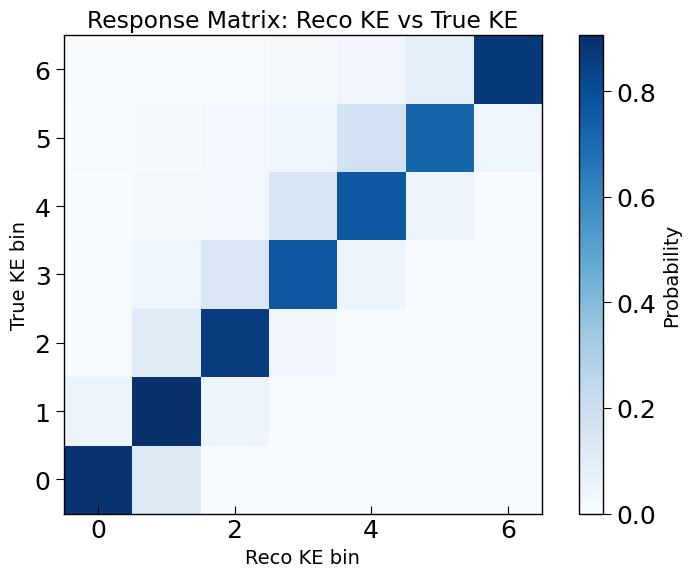

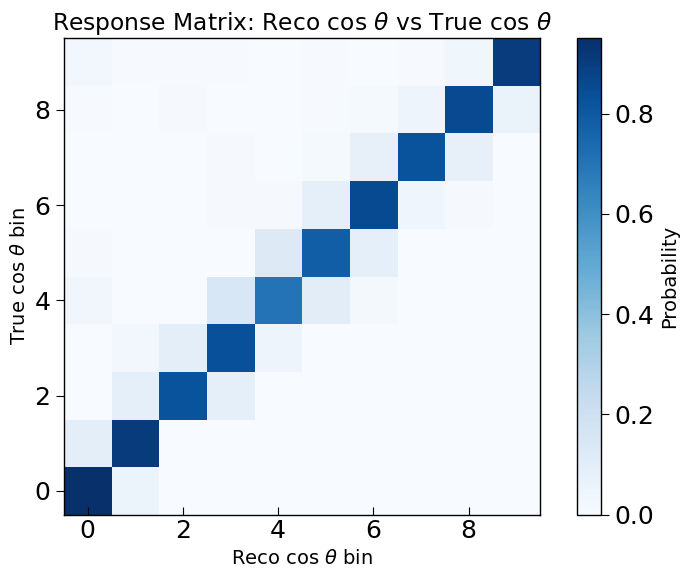

In [44]:
R = cv_results['reco_ke']['response']
plt.imshow(R,
           origin='lower',
           cmap='Blues')
plt.xlabel('Reco KE bin')
plt.ylabel('True KE bin')
plt.title('Response Matrix: Reco KE vs True KE')
plt.colorbar(label='Probability')
plt.tight_layout()
fig = os.path.join(PLOT_DIR, 'response_matrix_reco_ke.png')
plt.savefig(fig, dpi=300, bbox_inches='tight')
plt.show()

R = cv_results['reco_costheta']['response']
plt.imshow(R,
           origin='lower',
           cmap='Blues')
plt.xlabel(r'Reco cos $\theta$ bin')
plt.ylabel(r'True cos $\theta$ bin')
plt.title(r'Response Matrix: Reco cos $\theta$ vs True cos $\theta$')
plt.colorbar(label='Probability')
plt.tight_layout()
fig = os.path.join(PLOT_DIR, 'response_matrix_reco_costheta.png')
plt.savefig(fig, dpi=300, bbox_inches='tight')
plt.show()

In [45]:
for v in ['reco_ke','reco_costheta']:
    R = cv_results[v]['response']

    print(v)
    print(R.shape)
    print("diag =", np.diag(R))
    print("mean =", np.mean(np.diag(R)))

reco_ke
(7, 7)
diag = [0.88709677 0.90540541 0.8596882  0.76578947 0.764      0.71808511
 0.86968839]
mean = 0.8242504772751938
reco_costheta
(10, 10)
diag = [0.95       0.90625    0.82352941 0.83333333 0.70491803 0.78021978
 0.85271318 0.82352941 0.85714286 0.90539484]
mean = 0.8437030845025371


In [46]:
import uproot
from makedf.getsyst import print_syst_all

f = uproot.open("/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/input598.caf.root")
print_syst_all(f)

Index: 0   | Name: GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE                   | Type: 3     | Univ: 6
Index: 1   | Name: GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE                   | Type: 3     | Univ: 6
Index: 2   | Name: GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE                   | Type: 3     | Univ: 6
Index: 3   | Name: GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE                   | Type: 3     | Univ: 6
Index: 4   | Name: GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape               | Type: 3     | Univ: 1
Index: 5   | Name: GENIEReWeight_SBN_v1_multisigma_RPA_CCQE                     | Type: 3     | Univ: 6
Index: 6   | Name: GENIEReWeight_SBN_v1_multisigma_CoulombCCQE                  | Type: 3     | Univ: 6
Index: 7   | Name: GENIEReWeight_SBN_v1_multisigma_NormCCMEC                    | Type: 3     | Univ: 6
Index: 8   | Name: GENIEReWeight_SBN_v1_multisigma_NormNCMEC                    | Type: 3     | Univ: 6
Index: 9   | Name: GENIEReWeight_SBN_v1_multisigma_DecayAngMEC  

## 6. Universe Histograms (Flux & GENIE)

In [47]:

# def build_univ_hists(sel_df, stage_col, wgt_aligned, univ_cols,
#                      var_col, bins, ps, clip=10.0):
#     sel  = sel_df[sel_df[stage_col]]
#     smk  = (sel['truth_cat'] == 0).values
#     bmk  = sel['truth_cat'].between(1, 6).values
#     reco = sel[var_col].clip(bins[0], bins[-1] - 1e-8).values
#     nwl  = wgt_aligned.index.nlevels
#     sidx = (sel.index.droplevel(list(range(nwl, sel.index.nlevels)))
#             if sel.index.nlevels > nwl else sel.index)
#     wmat = wgt_aligned[univ_cols].reindex(sidx).values.astype(np.float32)
#     nu   = len(univ_cols); nb = len(bins) - 1
#     su   = np.zeros((nu, nb)); bu = np.zeros((nu, nb))
#     for ui in tqdm(range(nu), desc=var_col, leave=False):
#         w = np.where(np.isfinite(wmat[:, ui]), wmat[:, ui].astype(float), 1.0)
#         w = np.clip(w, 0.0, clip) * ps
#         su[ui], _ = np.histogram(reco[smk], bins=bins, weights=w[smk])
#         bu[ui], _ = np.histogram(reco[bmk], bins=bins, weights=w[bmk])
#     return su, bu


In [48]:
def build_univ_hists(sel_df, stage_col, wgt_aligned, univ_cols,
                     var_col, bins, ps, clip=10.0):
    sel  = sel_df[sel_df[stage_col]]
    if sel.empty:
        nb = len(bins) - 1; nu = len(univ_cols)
        return np.zeros((nu, nb)), np.zeros((nu, nb))

    smk  = (sel['truth_cat'] == 0).values
    bmk  = sel['truth_cat'].between(1, 6).values
    reco = sel[var_col].clip(bins[0], bins[-1] - 1e-8).values

    # ── align sel index levels to wgt_aligned index levels ───────────────────
    nwl = wgt_aligned.index.nlevels
    if sel.index.nlevels > nwl:
        sidx = sel.index.droplevel(list(range(nwl, sel.index.nlevels)))
    elif sel.index.nlevels == nwl:
        sidx = sel.index
    else:
        # sel has FEWER levels than wgt — unexpected; fall back to unweighted
        warnings.warn(
            f"build_univ_hists: sel has {sel.index.nlevels} index levels but "
            f"wgt_aligned has {nwl}. Returning unit weights."
        )
        nb = len(bins) - 1; nu = len(univ_cols)
        return np.zeros((nu, nb)), np.zeros((nu, nb))

    # Add this at the TOP of build_univ_hists, right after computing sidx:
    print(f"  sel index nlevels: {sel.index.nlevels}, names: {sel.index.names}")
    print(f"  wgt index nlevels: {wgt_aligned.index.nlevels}, names: {wgt_aligned.index.names}")
    print(f"  sidx nlevels: {sidx.nlevels}, names: {sidx.names}")
    print(f"  sel first 3 indices:  {list(sel.index[:3])}")
    print(f"  sidx first 3 indices: {list(sidx[:3])}")
    print(f"  wgt first 3 indices:  {list(wgt_aligned.index[:3])}")
    
    # Check overlap
    overlap = sidx.isin(wgt_aligned.index)
    print(f"  sidx ∩ wgt_aligned: {overlap.sum()} / {len(sidx)} "
          f"({overlap.mean()*100:.1f}%)")
    
    # ── guard against duplicate wgt_aligned index (merged files) ─────────────
    wgt_sub = wgt_aligned[univ_cols]
    if wgt_sub.index.duplicated().any():
        wgt_sub = wgt_sub[~wgt_sub.index.duplicated(keep='first')]

    # reindex: rows in sel that have no weight match get NaN → replaced by 1.0
    wmat = wgt_sub.reindex(sidx).values.astype(np.float32)

    # sanity: warn if most weights are missing (likely file mismatch)
    nan_frac = np.isnan(wmat).mean()
    if nan_frac > 0.5:
        warnings.warn(
            f"build_univ_hists [{var_col}]: {nan_frac*100:.0f}% of weights "
            "are NaN after reindex — check that DF_FILE and WEIGHTS_FILE "
            "correspond to the same MC sample."
        )

    nu = len(univ_cols); nb = len(bins) - 1
    su = np.zeros((nu, nb)); bu = np.zeros((nu, nb))

    for ui in tqdm(range(nu), desc=var_col, leave=False):
        w = np.where(np.isfinite(wmat[:, ui]), wmat[:, ui].astype(float), 1.0)
        w = np.clip(w, 0.0, clip) * ps
        su[ui], _ = np.histogram(reco[smk], bins=bins, weights=w[smk])
        bu[ui], _ = np.histogram(reco[bmk], bins=bins, weights=w[bmk])

    return su, bu

In [49]:
SRC_LABEL = {'flux': 'BNB Flux', 'genie': 'GENIE', 'extra_xsec': 'Other Xsec Syst.',
             'g4': 'Geant4', 'mcstat': 'MCstat'}
univ_results = {}
lowE_univ_results = {}

# ── Main MC universes ─────────────────────────────────────────────────────────
for vcfg in VAR_CFGS:
    univ_results[vcfg.name] = {}
    for src, cols in [('flux',      bnb_cols_aligned),
                      ('genie',     genie_cols_aligned),
                      ('extra_xsec', extra_cols_aligned),
                      ('g4',        g4_cols_aligned)]:
        if not cols:
            continue
        print(f'[{vcfg.name}] {src} ({len(cols)} cols) ...')
        su, bu = build_univ_hists(sel_topo, FINAL_STAGE, wgt_aligned,
                                  cols, vcfg.name, vcfg.bins, pot_scale)
        univ_results[vcfg.name][src] = {'sig': su, 'bkg': bu}
    gc.collect()

# ── LowE dirt universes ──────────────────────────────────────────────────────
for vcfg in VAR_CFGS:
    lowE_univ_results[vcfg.name] = {}
    for src, cols in [('flux',       lowE_bnb_cols_aligned),
                      ('genie',      lowE_genie_cols_aligned),
                      ('extra_xsec', lowE_extra_cols_aligned),
                      ('g4',         lowE_g4_cols_aligned)]:
        if not cols:
            continue
        print(f'[{vcfg.name}] LowE {src} ({len(cols)} cols) ...')
        su, bu = build_univ_hists(lowE_sel, FINAL_STAGE, lowE_wgt_aligned,
                                  cols, vcfg.name, vcfg.bins, lowE_pot_scale)
        lowE_univ_results[vcfg.name][src] = {'sig': su, 'bkg': bu}
    gc.collect()

print('All universes done (main MC + lowE).')

[reco_ke] flux (100 cols) ...
  sel index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  wgt index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sidx nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sel first 3 indices:  [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  sidx first 3 indices: [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  wgt first 3 indices:  [(0, 2, 0), (0, 3, 6), (0, 4, 12)]
  sidx ∩ wgt_aligned: 3800 / 3800 (100.0%)


reco_ke:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_ke] genie (100 cols) ...
  sel index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  wgt index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sidx nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sel first 3 indices:  [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  sidx first 3 indices: [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  wgt first 3 indices:  [(0, 2, 0), (0, 3, 6), (0, 4, 12)]
  sidx ∩ wgt_aligned: 3800 / 3800 (100.0%)


reco_ke:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_ke] extra_xsec (100 cols) ...
  sel index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  wgt index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sidx nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sel first 3 indices:  [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  sidx first 3 indices: [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  wgt first 3 indices:  [(0, 2, 0), (0, 3, 6), (0, 4, 12)]
  sidx ∩ wgt_aligned: 3800 / 3800 (100.0%)


...

reco_costheta:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_costheta] LowE g4 (300 cols) ...
  sel index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  wgt index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sidx nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sel first 3 indices:  [(192, 5, 0), (293, 2, 0), (315, 14, 0)]
  sidx first 3 indices: [(192, 5, 0), (293, 2, 0), (315, 14, 0)]
  wgt first 3 indices:  [(0, 0, 1), (0, 8, 3), (0, 12, 0)]
  sidx ∩ wgt_aligned: 585 / 585 (100.0%)


/tmp/ipykernel_2165/1571029388.py:51: UserWarning: build_univ_hists [reco_costheta]: 100% of weights are NaN after reindex — check that DF_FILE and WEIGHTS_FILE correspond to the same MC sample.
  warnings.warn(


reco_costheta:   0%|          | 0/300 [00:00<?, ?it/s]

All universes done (main MC + lowE).


## 7. MCstat Universes (Poisson resampling)

In [50]:
from numpy.random import Generator, PCG64, SeedSequence

def build_mcstat_univs(sel_df, stage_col, var_col, bins, ps, nu=100, seed=42):
    sel  = sel_df[sel_df[stage_col]]
    smk  = (sel['truth_cat'] == 0).values
    bmk  = sel['truth_cat'].between(1, 6).values
    reco = sel[var_col].clip(bins[0], bins[-1] - 1e-8).values
    ne   = len(sel); ss = SeedSequence(seed); kids = ss.spawn(nu)
    nb   = len(bins) - 1; su = np.zeros((nu, nb)); bu = np.zeros((nu, nb))
    for u in tqdm(range(nu), desc=f'{var_col} MCstat', leave=False):
        w = Generator(PCG64(kids[u])).poisson(1.0, size=ne) * ps
        su[u], _ = np.histogram(reco[smk], bins=bins, weights=w[smk])
        bu[u], _ = np.histogram(reco[bmk], bins=bins, weights=w[bmk])
    return su, bu

for vcfg in VAR_CFGS:
    print(f'[{vcfg.name}] MCstat ...')
    su, bu = build_mcstat_univs(sel_topo, FINAL_STAGE, vcfg.name, vcfg.bins, pot_scale)
    univ_results[vcfg.name]['mcstat'] = {'sig': su, 'bkg': bu}

for vcfg in VAR_CFGS:
    print(f'[{vcfg.name}] LowE MCstat ...')
    su, bu = build_mcstat_univs(lowE_sel, FINAL_STAGE, vcfg.name,
                                vcfg.bins, lowE_pot_scale, seed=137)
    lowE_univ_results[vcfg.name]['mcstat'] = {'sig': su, 'bkg': bu}

del wgt_aligned
del lowE_wgt_aligned
gc.collect()
print('MCstat done. Weights freed.')

[reco_ke] MCstat ...


reco_ke MCstat:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_costheta] MCstat ...


reco_costheta MCstat:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_ke] LowE MCstat ...


reco_ke MCstat:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_costheta] LowE MCstat ...


reco_costheta MCstat:   0%|          | 0/100 [00:00<?, ?it/s]

MCstat done. Weights freed.


## 8. Covariance Matrices

In [24]:
def _mat(block):
    return block.get('cov', block) if isinstance(block, dict) else block

def compute_covs(su, bu, s_cv, b_cv):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        return {
            'cov_ms_ms': get_covariance_matrix_self(su, s_cv),
            'cov_bs_bs': get_covariance_matrix_self(bu, b_cv),
            'cov_ms_bs': get_covariance_matrix(su, s_cv, bu, b_cv),
            'cov_bs_ms': get_covariance_matrix(bu, b_cv, su, s_cv),
        }

cov_results = {}

# ── Main MC covariances ──────────────────────────────────────────────────────
for vcfg in VAR_CFGS:
    cov_results[vcfg.name] = {}
    cv = cv_results[vcfg.name]
    for src, ud in univ_results[vcfg.name].items():
        print(f'[{vcfg.name}] cov: {src} ...')
        cov_results[vcfg.name][src] = compute_covs(
            ud['sig'], ud['bkg'], cv['sig_cv'], cv['bkg_cv'])

# ── LowE dirt covariances → add to main MC covariances ───────────────────────
for vcfg in VAR_CFGS:
    dirt_cv = lowE_cv[vcfg.name]
    zero_cv = np.zeros_like(dirt_cv)

    for src, ud in lowE_univ_results[vcfg.name].items():
        print(f'[{vcfg.name}] lowE cov: {src} ...')
        lowE_covs = compute_covs(ud['sig'], ud['bkg'], zero_cv, dirt_cv)

        if src in cov_results[vcfg.name]:
            for bk in ['cov_ms_ms', 'cov_bs_bs', 'cov_ms_bs', 'cov_bs_ms']:
                cov_results[vcfg.name][src][bk] = (
                    _mat(cov_results[vcfg.name][src][bk]) + _mat(lowE_covs[bk])
                )
            print(f'  [{vcfg.name}] {src}: added lowE contribution')
        else:
            cov_results[vcfg.name][src] = lowE_covs
            print(f'  [{vcfg.name}] {src}: new source from lowE')

print('All covariances computed (main MC + lowE combined).')

[reco_ke] cov: genie ...
[reco_ke] cov: extra_xsec ...
[reco_ke] cov: g4 ...
[reco_ke] cov: mcstat ...
[reco_costheta] cov: genie ...
[reco_costheta] cov: extra_xsec ...
[reco_costheta] cov: g4 ...
[reco_costheta] cov: mcstat ...
[reco_ke] lowE cov: genie ...
  [reco_ke] genie: added lowE contribution
[reco_ke] lowE cov: extra_xsec ...
  [reco_ke] extra_xsec: added lowE contribution
[reco_ke] lowE cov: g4 ...
  [reco_ke] g4: added lowE contribution
[reco_ke] lowE cov: mcstat ...
  [reco_ke] mcstat: added lowE contribution
[reco_costheta] lowE cov: genie ...
  [reco_costheta] genie: added lowE contribution
[reco_costheta] lowE cov: extra_xsec ...
  [reco_costheta] extra_xsec: added lowE contribution
[reco_costheta] lowE cov: g4 ...
  [reco_costheta] g4: added lowE contribution
[reco_costheta] lowE cov: mcstat ...
  [reco_costheta] mcstat: added lowE contribution
All covariances computed (main MC + lowE combined).


In [25]:
# ── N_targets calculation from your FV definition ────────────────────────────
# FV from _fiducial_cut_tmp in make_nueCC_df.py:
#   |x| in (5, 190), combined z/y regions

# Region 1: z in (10,250), y in (-190,190), full x  
V1 = (2 * 185.0) * 380.0 * 240.0   # cm³

# Region 2: z in (250,450), y in (-190,100), x < 0 only
V2 = 185.0 * 290.0 * 200.0         # cm³

# Region 3: z in (250,450), y in (-190,190), x > 0 only
V3 = 185.0 * 380.0 * 200.0         # cm³

V_FV = V1 + V2 + V3
rho_LAr = 1.3954    # g/cm³  (SBND LAr density)
N_A     = 6.022e23  # Avogadro
A_Ar    = 39.948     # g/mol

M_FV = rho_LAr * V_FV
N_targets = M_FV * N_A / A_Ar
print(f"FV volume:  {V_FV:.2e} cm³")
print(f"LAr mass:   {M_FV:.2e} g = {M_FV/1e6:.3f} tonnes")
print(f"N_targets:  {N_targets:.4e}")

FRAC_POT      = 0.02    # 2% POT counting uncertainty
FRAC_NTARGETS = 0.01    # 1% fiducial mass / number of targets uncertainty

for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    sig_cv = cv['sig_cv']
    bkg_cv = cv['bkg_cv']

    for src_name, frac in [('pot', FRAC_POT), ('ntargets', FRAC_NTARGETS)]:
        cov_ms = frac**2 * np.outer(sig_cv, sig_cv)
        cov_bs = frac**2 * np.outer(bkg_cv, bkg_cv)

        cov_results[vcfg.name][src_name] = {
            'cov_ms_ms': cov_ms,
            'cov_bs_bs': cov_bs,
            'cov_ms_bs': frac**2 * np.outer(sig_cv, bkg_cv),
            'cov_bs_ms': frac**2 * np.outer(bkg_cv, sig_cv),
        }
        print(f'[{vcfg.name}] {src_name}: frac_unc={frac}, '
              f'diag sig = {np.sqrt(np.diag(cov_ms))}')

    # Also add to univ_results so the save/plot loop picks them xup
    # (these don't have universe histograms, so we skip the universe plots)

print('POT + N_targets covariance matrices added.')


FV volume:  5.85e+07 cm³
LAr mass:   8.17e+07 g = 81.678 tonnes
N_targets:  1.2313e+30
[reco_ke] pot: frac_unc=0.02, diag sig = [12.7199038  54.30083072 41.75637386 31.05410997 22.28176252 15.26388456
 27.54517099]
[reco_ke] ntargets: frac_unc=0.01, diag sig = [ 6.3599519  27.15041536 20.87818693 15.52705499 11.14088126  7.63194228
 13.7725855 ]
[reco_costheta] pot: frac_unc=0.02, diag sig = [  5.52657889   3.85983288   3.7721094    4.91251457   5.175685
   8.68462398  12.63218033  18.68510007  37.80881751 103.86459381]
[reco_costheta] ntargets: frac_unc=0.01, diag sig = [ 2.76328945  1.92991644  1.8860547   2.45625729  2.5878425   4.34231199
  6.31609016  9.34255003 18.90440876 51.93229691]
POT + N_targets covariance matrices added.


### 7.1 Export output for Omnifold

In [51]:
# ── Sanity check before running universes ─────────────────────────────────────
print("Column alignment check:")
print(f"  bnb_cols_aligned:   {len(bnb_cols_aligned)}")
print(f"  genie_cols_aligned: {len(genie_cols_aligned)}")
print(f"  extra_cols_aligned: {len(extra_cols_aligned)}")
print(f"  g4_cols_aligned:    {len(g4_cols_aligned)}")

if len(bnb_cols_aligned) == 0:
    print("\nERROR: bnb_cols_aligned is empty.")
    print("First 3 cols in wgt_aligned:", list(wgt_aligned.columns[:3]))
    print("First 3 cols in _main_aligned['flux']:", _main_aligned['flux'][:3])
    raise RuntimeError("Re-run Section 2 and Section 3.1 before running this cell.")

Column alignment check:
  bnb_cols_aligned:   100
  genie_cols_aligned: 100
  extra_cols_aligned: 100
  g4_cols_aligned:    0



true_p efficiency:
     100.0: 0.0879  (24/273)
     300.0: 0.4632  (346/747)
     500.0: 0.5849  (396/677)
     700.0: 0.6079  (324/533)
     900.0: 0.7139  (277/388)
    1200.0: 0.7859  (411/523)
    1700.0: 0.8150  (326/400)

true_costheta efficiency:
      -0.9: 0.3333  (20/60)
      -0.7: 0.4156  (32/77)
      -0.5: 0.2857  (34/119)
      -0.3: 0.3590  (42/117)
      -0.1: 0.4388  (61/139)
       0.1: 0.5112  (91/178)
       0.3: 0.4743  (129/272)
       0.5: 0.5470  (221/404)
       0.7: 0.6364  (427/671)
       0.9: 0.7267  (1279/1760)
OmniFold events: 2,336
BNB p-bins:   (100, 7)
GENIE p-bins: (100, 7)
BNB cos-bins: (100, 10)

Saved universe weights:
  BNB (2D): shape=(2336, 100), univ0 mean=1.0318, std=0.0142
  GENIE (2D): shape=(2336, 100), univ0 mean=1.1020, std=0.0746


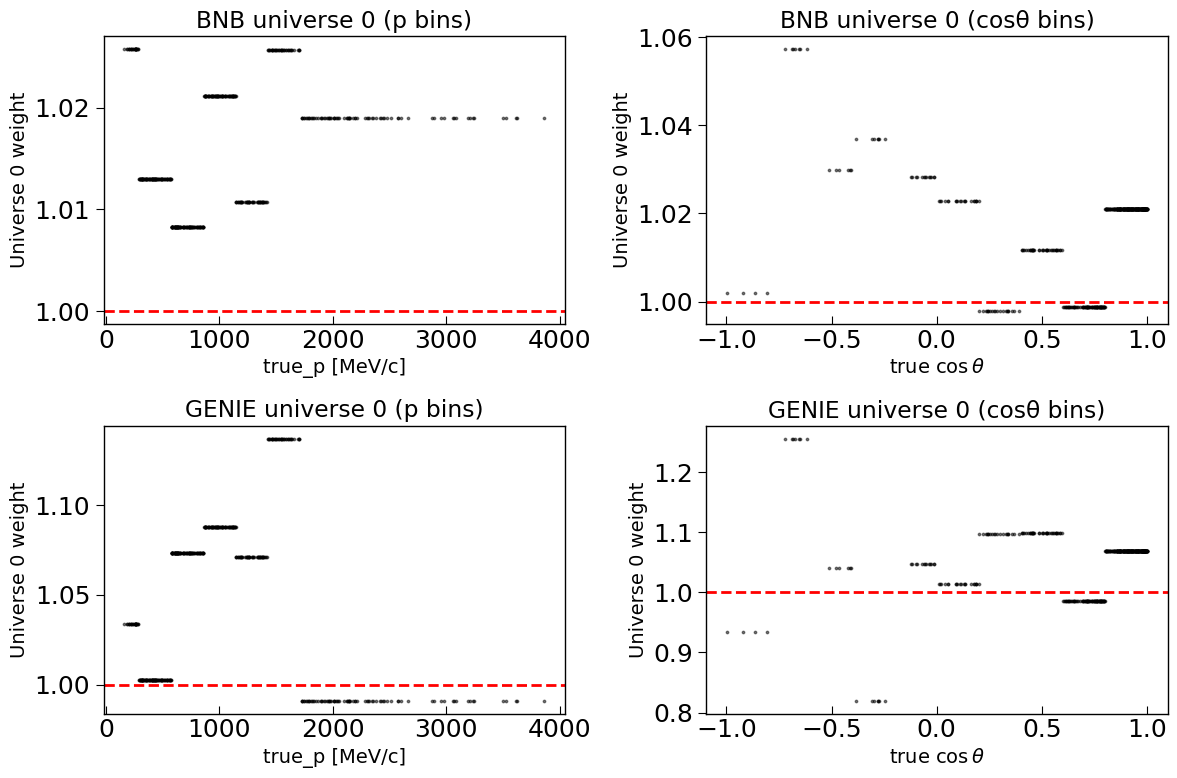

Done.


In [52]:
# ── Export binned fake data weights for OmniFold ─────────────────────────────
import numpy as np, os, matplotlib.pyplot as plt

OMNIFOLD_OUT  = '/home/castalyf/Omnifold_SBND/sbnd/exported_weights/'
OMNIFOLD_DATA = '/home/castalyf/FormattedData_SBND/'
os.makedirs(OMNIFOLD_OUT, exist_ok=True)


RECO_VARS = ['reco_p', 'reco_costheta']
FINAL_STAGE = 'sel_vertex_distance'

sig_all = sel_topo[sel_topo['is_sig']]
sig_sel = sel_topo[sel_topo['is_sig'] & sel_topo[FINAL_STAGE]].copy()
reco_raw = sig_sel[RECO_VARS].values.astype(np.float32)
sig_sel_valid = sig_sel[~np.isnan(reco_raw).any(axis=1)]

bins_p   = np.array([0, 200, 400, 600, 800, 1000, 1400, 2000])
bins_cos = np.linspace(-1, 1, 11)

for var, bins, label in [('true_p', bins_p, 'true_p'),
                          ('true_costheta', bins_cos, 'true_costheta')]:
    N_all, _ = np.histogram(sig_all[var].dropna(), bins=bins)
    N_sel, _ = np.histogram(sig_sel_valid[var].dropna(), bins=bins)
    eff = N_sel / N_all.clip(1)
    np.save(OMNIFOLD_OUT + f'efficiency_{label}.npy', eff)
    centers = 0.5 * (bins[:-1] + bins[1:])
    print(f"\n{label} efficiency:")
    for c, e, na, ns in zip(centers, eff, N_all, N_sel):
        print(f"  {c:8.1f}: {e:.4f}  ({ns}/{na})")

# 1. Load OmniFold events
# Column order matches FormatData_SBND.py:
#   col 0 = true_p, col 1 = true_costheta
truth_raw  = np.load(OMNIFOLD_DATA + 'mc_vals_truth_NoNorm.npy')  # (6399, 2)
mc_weights = np.load(OMNIFOLD_DATA + 'mc_weights_reco.npy')       # (6399,)
true_p        = truth_raw[:, 0]
true_costheta = truth_raw[:, 1]
n_events = len(true_p)
print(f"OmniFold events: {n_events:,}")

# 2. Get universe histograms — with graceful fallback if flux missing
def _require_src(univ_dict, src, var_name):
    if src not in univ_dict:
        raise KeyError(
            f"Source '{src}' missing from univ_results['{var_name}']. "
            f"Available: {list(univ_dict.keys())}. "
            f"Re-run Cell 6 after ensuring {src}_cols_aligned is non-empty."
        )
    return univ_dict[src]

su_bnb_p   = _require_src(univ_results['reco_ke'],       'flux',  'reco_ke')['sig']
su_genie_p = _require_src(univ_results['reco_ke'],       'genie', 'reco_ke')['sig']
su_bnb_cos = _require_src(univ_results['reco_costheta'], 'flux',  'reco_costheta')['sig']
su_genie_cos = _require_src(univ_results['reco_costheta'], 'genie', 'reco_costheta')['sig']

sig_cv_p   = cv_results['reco_ke']['sig_cv']
sig_cv_cos = cv_results['reco_costheta']['sig_cv']

print(f"BNB p-bins:   {su_bnb_p.shape}")
print(f"GENIE p-bins: {su_genie_p.shape}")
print(f"BNB cos-bins: {su_bnb_cos.shape}")

# 3. Per-bin ratios
ratio_bnb_p    = su_bnb_p    / np.clip(sig_cv_p[np.newaxis, :],   1.0, None)
ratio_genie_p  = su_genie_p  / np.clip(sig_cv_p[np.newaxis, :],   1.0, None)
ratio_bnb_cos  = su_bnb_cos  / np.clip(sig_cv_cos[np.newaxis, :], 1.0, None)
ratio_genie_cos= su_genie_cos / np.clip(sig_cv_cos[np.newaxis, :], 1.0, None)

# 4. Assign per-event weights by bin
# p-binning (matches reco_ke bins — same MeV range)
bins_p   = np.linspace(0, 2000, 8)       # must match RECO_BINS from cell 4
bins_cos = np.linspace(-1, 1, 11)        # must match COS_BINS from cell 4

def assign_bin_weights(var_vals, bins, ratio_matrix):
    """Map each event to its bin and return per-event weights (N_events, N_universes)."""
    idx = np.digitize(var_vals.clip(bins[0], bins[-1] - 1e-8), bins) - 1
    idx = np.clip(idx, 0, len(bins) - 2)
    n_u = ratio_matrix.shape[0]
    out = np.ones((len(var_vals), n_u), dtype=np.float32)
    for u in range(n_u):
        out[:, u] = ratio_matrix[u, idx]
    return out

bnb_per_event_p    = assign_bin_weights(true_p,        bins_p,   ratio_bnb_p)
genie_per_event_p  = assign_bin_weights(true_p,        bins_p,   ratio_genie_p)
bnb_per_event_cos  = assign_bin_weights(true_costheta, bins_cos, ratio_bnb_cos)
genie_per_event_cos= assign_bin_weights(true_costheta, bins_cos, ratio_genie_cos)

# Combined: use the geometric mean of p and costheta weights as the 2D weight
# This approximates a 2D binned fake data from two 1D universe projections
bnb_2d   = bnb_per_event_p   * bnb_per_event_cos
genie_2d = genie_per_event_p * genie_per_event_cos

# 5. Save — keep both 1D projections and the 2D combined
np.save(OMNIFOLD_OUT + 'bnb_universe_weights.npy',     bnb_2d)
np.save(OMNIFOLD_OUT + 'genie_universe_weights.npy',   genie_2d)

# Also save 1D versions for diagnostics
np.save(OMNIFOLD_OUT + 'bnb_universe_weights_p.npy',       bnb_per_event_p)
np.save(OMNIFOLD_OUT + 'bnb_universe_weights_costheta.npy', bnb_per_event_cos)

print(f"\nSaved universe weights:")
for name, vals in [('BNB (2D)', bnb_2d), ('GENIE (2D)', genie_2d)]:
    u0 = vals[:, 0]
    print(f"  {name}: shape={vals.shape}, "
          f"univ0 mean={u0.mean():.4f}, std={u0.std():.4f}")

# 6. Diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (name, vals_p, vals_cos) in enumerate([
    ('BNB',   bnb_per_event_p,   bnb_per_event_cos),
    ('GENIE', genie_per_event_p, genie_per_event_cos)
]):
    axes[row][0].scatter(true_p[::5],        vals_p[::5, 0],   s=3, alpha=0.5)
    axes[row][0].axhline(1.0, color='r', linestyle='--')
    axes[row][0].set_xlabel('true_p [MeV/c]')
    axes[row][0].set_ylabel('Universe 0 weight')
    axes[row][0].set_title(f'{name} universe 0 (p bins)')

    axes[row][1].scatter(true_costheta[::5], vals_cos[::5, 0], s=3, alpha=0.5)
    axes[row][1].axhline(1.0, color='r', linestyle='--')
    axes[row][1].set_xlabel(r'true $\cos\theta$')
    axes[row][1].set_ylabel('Universe 0 weight')
    axes[row][1].set_title(f'{name} universe 0 (cosθ bins)')

plt.tight_layout()
plt.savefig(OMNIFOLD_OUT + 'binned_fakedata_diagnostic.png', dpi=100)
plt.show()
print("Done.")

In [30]:
# ── What's actually in the weight files? ─────────────────────────────────────
print("=== Main MC: first 10 universe col names ===")
with pd.HDFStore(WEIGHTS_FILE, mode='r') as store:
    _tmp = store[store.keys()[0]] if store.keys() else None
_tmp_mcnu = _load_hdf_key(WEIGHTS_FILE, 'mcnu')
_all = list(_tmp_mcnu.columns)
_univ_cols = [c for c in _all if _is_univ(c)]
for c in _univ_cols[:10]:
    print(' ', c)

print(f"\n=== Main MC: total univ cols = {len(_univ_cols)} ===")
print("\nUnique first-level names:")
_first = sorted(set(c[0] for c in _univ_cols if isinstance(c, tuple)))
for f in _first:
    n = sum(1 for c in _univ_cols if isinstance(c, tuple) and c[0] == f)
    print(f"  {f:<60s}: {n}")
del _tmp_mcnu

=== Main MC: first 10 universe col names ===
  ('Flux', 'univ_0')
  ('Flux', 'univ_1')
  ('Flux', 'univ_2')
  ('Flux', 'univ_3')
  ('Flux', 'univ_4')
  ('Flux', 'univ_5')
  ('Flux', 'univ_6')
  ('Flux', 'univ_7')
  ('Flux', 'univ_8')
  ('Flux', 'univ_9')

=== Main MC: total univ cols = 300 ===

Unique first-level names:
  Flux                                                        : 100
  GENIE                                                       : 100
  extra_xsec                                                  : 100


In [53]:
# ── Export MCstat universe weights for OmniFold ──────────────────────────────
from numpy.random import Generator, PCG64, SeedSequence

sig_sel = sel_topo[sel_topo['is_sig'] & sel_topo['sel_vertex_distance']].copy()
reco_raw = sig_sel[['reco_ke', 'reco_costheta', 'reco_p']].values.astype(np.float32)
valid = ~np.isnan(reco_raw).any(axis=1)
sig_sel = sig_sel[valid]
n = len(sig_sel)

n_univ = 100
seed = 42
ss = SeedSequence(seed)
kids = ss.spawn(n_univ)

mcstat_weights = np.zeros((n, n_univ), dtype=np.float32)
for u in range(n_univ):
    mcstat_weights[:, u] = Generator(PCG64(kids[u])).poisson(1.0, size=n).astype(np.float32)

np.save(OMNIFOLD_OUT + 'mcstat_universe_weights.npy', mcstat_weights)
print(f"MCstat saved: {mcstat_weights.shape}")
print(f"  Univ 0: mean={mcstat_weights[:,0].mean():.4f}, std={mcstat_weights[:,0].std():.4f}")

MCstat saved: (2336, 100)
  Univ 0: mean=0.9953, std=1.0015


In [54]:
print(f"Notebook sel_topo shape: {sel_topo.shape}")
print(f"sel_topo['sel_vertex_distance'].sum(): {sel_topo['sel_vertex_distance'].sum()}")
print(f"sel_topo is_sig & sel_vertex_distance: {(sel_topo['is_sig'] & sel_topo['sel_vertex_distance']).sum()}")

# Check if sel_topo has been further filtered vs the raw pkl
df_raw = pd.read_pickle('/home/castalyf/cafpyana/analysis_village/nueCC/nuecc_dfs/selected_nuecc_qual.pkl')
print(f"\nRaw pkl shape: {df_raw.shape}")
print(f"Raw pkl is_sig & sel_vertex_distance: {(df_raw['is_sig'] & df_raw['sel_vertex_distance']).sum()}")

Notebook sel_topo shape: (980816, 16)
sel_topo['sel_vertex_distance'].sum(): 3800
sel_topo is_sig & sel_vertex_distance: 2336

Raw pkl shape: (980816, 16)
Raw pkl is_sig & sel_vertex_distance: 2336


## 9. Save NPZ Files

In [55]:

def save_npz(path, cv, covs, extra=None):
    p = dict(ms=cv['sig_cv'], bs=cv['bkg_cv'])
    if 'true_sig_cv' in cv: p['true_signal'] = cv['true_sig_cv']
    if 'response'    in cv: p['response']    = cv['response']
    for bk, bv in covs.items():
        if isinstance(bv, dict):
            for k, v in bv.items():
                if isinstance(v, np.ndarray): p[f'{bk}_{k}'] = v
        else:
            p[bk] = bv
    if extra: p.update(extra)
    np.savez(path, **p)
    print(f'  {os.path.basename(path)}  ({os.path.getsize(path)/1024:.0f} KB)')

for vcfg in VAR_CFGS:
    vd = os.path.join(SYST_DIR, vcfg.name); os.makedirs(vd, exist_ok=True)
    cv = cv_results[vcfg.name]
    for src, covs in cov_results[vcfg.name].items():
        save_npz(os.path.join(vd, f'{src}_cov_matrices.npz'), cv, covs)
        # In the total covariance computation, replace the existing sum:
    if len(cov_results[vcfg.name]) > 1:
        ts = sum(_mat(cov_results[vcfg.name][s]['cov_ms_ms'])
                 for s in cov_results[vcfg.name])
        tb = sum(_mat(cov_results[vcfg.name][s]['cov_bs_bs'])
                 for s in cov_results[vcfg.name])
        save_npz(os.path.join(vd, 'total_cov_matrices.npz'), cv, {},
                 extra=dict(total_cov_ms_ms=ts, total_cov_bs_bs=tb))
print(f'\nAll NPZ saved to {SYST_DIR}/')


  genie_cov_matrices.npz  (4 KB)
  extra_xsec_cov_matrices.npz  (4 KB)
  g4_cov_matrices.npz  (4 KB)
  mcstat_cov_matrices.npz  (4 KB)
  pot_cov_matrices.npz  (4 KB)
  ntargets_cov_matrices.npz  (4 KB)
  total_cov_matrices.npz  (3 KB)
  genie_cov_matrices.npz  (6 KB)
  extra_xsec_cov_matrices.npz  (6 KB)
  g4_cov_matrices.npz  (6 KB)
  mcstat_cov_matrices.npz  (6 KB)
  pot_cov_matrices.npz  (6 KB)
  ntargets_cov_matrices.npz  (6 KB)
  total_cov_matrices.npz  (4 KB)

All NPZ saved to ./saved_syst/


## 10. Plots: Universe Spreads

In [56]:
def savefig(fig, name, sub=''):
    d = os.path.join(PLOT_DIR, sub) if sub else PLOT_DIR
    os.makedirs(d, exist_ok=True)
    fig.savefig(os.path.join(d, f'{name}.png'), dpi=150, bbox_inches='tight')
    display(fig)       # show inline in notebook
    plt.close(fig)

# for vcfg in VAR_CFGS:
#     cv = cv_results[vcfg.name]
#     for src, ud in univ_results[vcfg.name].items():
#         for categ, cv_arr, ua in [
#             ('Signal',     cv['sig_cv'], ud['sig']),
#             ('Background', cv['bkg_cv'], ud['bkg']),
#         ]:
#             try:
#                 plot_univ_hists(ua, cv_arr, SRC_LABEL[src], vcfg, categ_name=categ)
#                 fig = plt.gcf()   # grab whatever was just created
#                 savefig(fig, f'{vcfg.name}_{src}_{categ.lower()}_univs', 'univ')
#             except Exception as e:
#                 print(f'  [WARN] {vcfg.name}/{src}/{categ}: {e}')
#                 plt.close('all')

# print('Universe plots -> plots_syst/univ/')

## 11. Plots: Covariance Heatmaps

In [57]:
import re

def format_heatmap_value(v):
    if np.isnan(v): return ""
    av = abs(v)
    if av == 0: return "0"
    if av < 1:
        return f"{v:.4f}"
    elif av < 1e3:
        return f"{v:.2f}"
    mantissa, exponent = f"{v:.2e}".split("e")
    return rf"${mantissa}\times10^{{{int(exponent)}}}$"

def plot_heatmap_custom(matrix, title, vcfg, axis_labels=None,
                        cmap='viridis', vmin=None, vmax=None):
    """Heatmap with bin-range tick labels and formatted cell annotations."""
    try:
        from analysis_village.unfolding.utils import bin_range_labels, get_text_color
        raw     = bin_range_labels(vcfg.bins)
        t_lbls  = [re.sub(r'(\d+)\.0+(?!\d)', r'\1', l) for l in raw]
        _get_tc = get_text_color
    except Exception:
        t_lbls  = [f'{vcfg.bins[i]:.0f}–{vcfg.bins[i+1]:.0f}'
                   for i in range(len(vcfg.bins)-1)]
        _get_tc = lambda v: 'white'

    n        = len(vcfg.bins) - 1
    unif     = np.arange(n + 1, dtype=float)
    tick_pos = 0.5 * (unif[:-1] + unif[1:])
    extent   = [unif[0], unif[-1], unif[0], unif[-1]]

    fig, ax = plt.subplots(figsize=(max(6, n*0.8), max(5, n*0.7)))
    im = ax.imshow(matrix, extent=extent, origin='lower',
                   cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.tick_params(labelsize=9)

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(t_lbls, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(tick_pos)
    ax.set_yticklabels(t_lbls, fontsize=8)
    ax.tick_params(axis='both', labelsize=8)

    xlbl, ylbl = axis_labels if axis_labels else [vcfg.var_plot_name]*2
    ax.set_xlabel(xlbl, fontsize=11)
    ax.set_ylabel(ylbl, fontsize=11)
    ax.set_title(title, fontsize=12)

    # Cell annotations
    fsize = max(5, 9 - n//3)   # shrink font for more bins
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            v = matrix[i, j]
            if not np.isnan(v):
                try:    tc = _get_tc(v)
                except: tc = 'white'
                ax.text(tick_pos[j], tick_pos[i],
                        format_heatmap_value(v),
                        ha='center', va='center',
                        color=tc, fontsize=fsize)
    fig.tight_layout()
    return fig, ax

## 12. Plots: Fractional Uncertainties per Bin

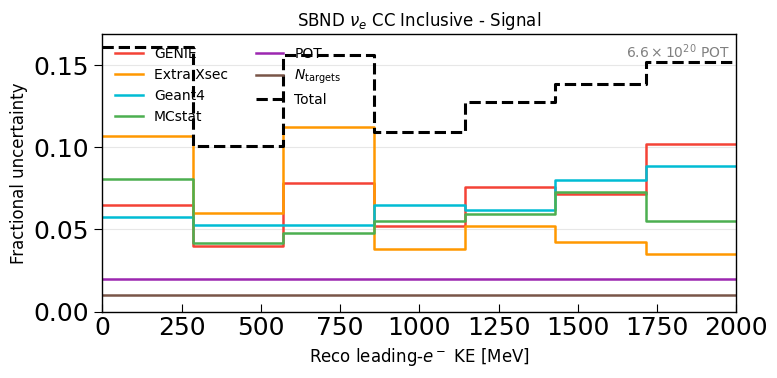

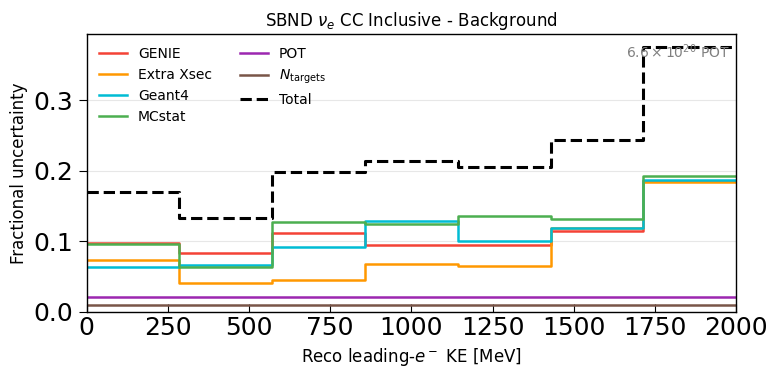

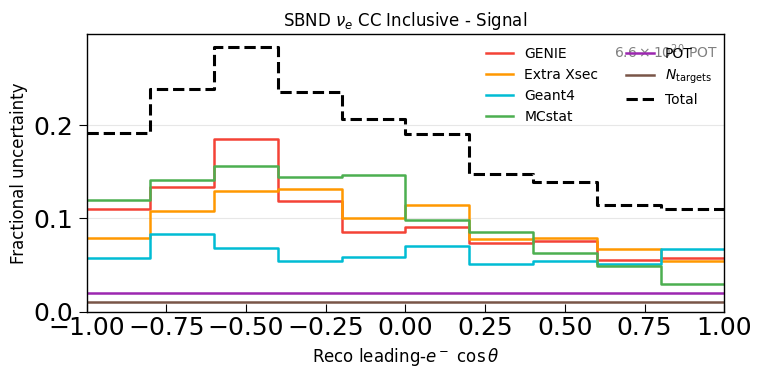

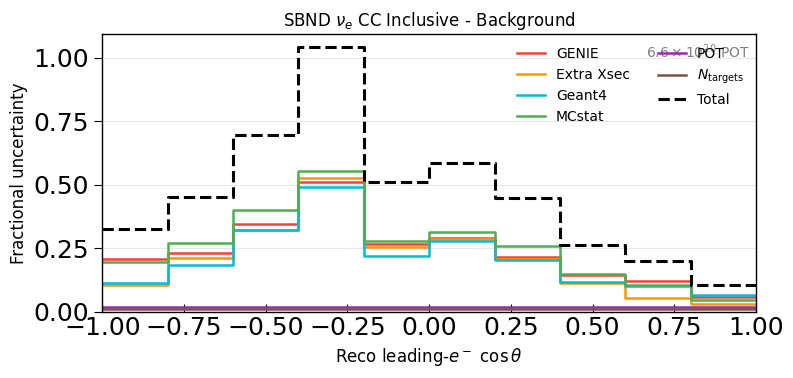

Fracunc plots -> plots_syst/fracunc/


In [58]:
SRC_LABEL = {
    'flux':       'BNB Flux',
    'genie':      'GENIE',
    'extra_xsec': 'Extra Xsec',
    'g4':         'Geant4',          
    'mcstat':     'MCstat',
    'pot':        'POT',
    'ntargets':   r'$N_\mathrm{targets}$',
}
COLORS = {
    'flux':       '#2196F3',
    'genie':      '#F44336',
    'extra_xsec': '#FF9800',
    'g4':         '#00BCD4',        
    'mcstat':     '#4CAF50',
    'pot':        '#9C27B0',
    'ntargets':   '#795548',
}
def plot_fracunc(vcfg, cv_arr, cov_results_var, block_key, categ):
    fig, ax = plt.subplots(figsize=(8, 4))
    total_var = np.zeros(len(vcfg.bin_centers))
    for src, covs in cov_results_var.items():
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            diag = np.diag(_mat(covs[block_key])).clip(0)
            frac = np.where(cv_arr > 0, np.sqrt(diag) / cv_arr, 0.0)
        xe = np.append(vcfg.bins[:-1], vcfg.bins[-1])
        ye = np.append(frac, frac[-1])
        ax.step(xe, ye, where='post', label=SRC_LABEL[src],
                color=COLORS.get(src, 'gray'), lw=1.8)
        total_var += diag
    tot = np.where(cv_arr > 0, np.sqrt(total_var) / cv_arr, 0.0)
    ax.step(np.append(vcfg.bins[:-1], vcfg.bins[-1]),
            np.append(tot, tot[-1]),
            where='post', label='Total', color='black', lw=2.2, ls='--')
    ax.set_xlabel(vcfg.var_plot_name, fontsize=12)
    ax.set_ylabel('Fractional uncertainty', fontsize=12)
    ax.set_title(f'{TITLE} - {categ}', fontsize=12)
    ax.legend(fontsize=10, ncol=2)
    ax.set_xlim(vcfg.bins[0], vcfg.bins[-1]); ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3)
    ax.text(0.99, 0.97, vcfg.pot_label, transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='gray')
    fig.tight_layout(); return fig

for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]; covs_var = cov_results[vcfg.name]
    for bk, categ, cv_arr in [
        ('cov_ms_ms', 'Signal',     cv['sig_cv']),
        ('cov_bs_bs', 'Background', cv['bkg_cv']),
    ]:
        fig = plot_fracunc(vcfg, cv_arr, covs_var, bk, categ)
        savefig(fig, f'{vcfg.name}_fracunc_{categ.lower()}', 'fracunc')
print('Fracunc plots -> plots_syst/fracunc/')


In [59]:
# After computing universe histograms, add chi2 for each source
import nue_helpers as nh
for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    for src, ud in univ_results[vcfg.name].items():
        if src in ('pot', 'ntargets'):
            continue  # no universes for flat systs
        # chi2 of each universe vs CV, take median
        chi2s = []
        for u in range(ud['sig'].shape[0]):
            c2, _, _ = nh.chi2_pvalue(ud['sig'][u], cv['sig_cv'])
            chi2s.append(c2)
        print(f"  [{vcfg.name}] {src}: median χ²/ndof = "
              f"{np.median(chi2s):.1f}/{len(cv['sig_cv'])}")

  [reco_ke] flux: median χ²/ndof = 16.1/7
  [reco_ke] genie: median χ²/ndof = 44.3/7
  [reco_ke] extra_xsec: median χ²/ndof = 50.5/7
  [reco_ke] mcstat: median χ²/ndof = 25.9/7
  [reco_costheta] flux: median χ²/ndof = 13.9/10
  [reco_costheta] genie: median χ²/ndof = 44.0/10
  [reco_costheta] extra_xsec: median χ²/ndof = 51.2/10
  [reco_costheta] mcstat: median χ²/ndof = 42.7/10


## 13. CV Stacked Histogram + Systematic Band

In [60]:
print(f"sel_topo shape        : {sel_topo.shape}")
print(f"Index names           : {sel_topo.index.names}")
print(f"Index nlevels         : {sel_topo.index.nlevels}")
stage_sum = sel_topo[FINAL_STAGE].sum()
sig_sum   = (sel_topo[FINAL_STAGE] & (sel_topo['truth_cat'] == 0)
             & sel_topo['reco_ke'].notna()).sum()
print(f"Passing {FINAL_STAGE}: {stage_sum}")
print(f"Signal passing stage  : {sig_sum}")
print(f"Expected weighted sig : {sig_sum * pot_scale:.1f}  (should be ~9322)")

sel_topo shape        : (980816, 16)
Index names           : ['__ntuple', 'entry', 'rec.dlp..index']
Index nlevels         : 3
Passing sel_vertex_distance: 3800
Signal passing stage  : 2336
Expected weighted sig : 10246.1  (should be ~9322)


In [61]:
def _build_mc_ob_series(sel_df, stage_col, var_col, mc_weight,
                         offbeam_vals, ob_weight,
                         dirt_vals=LOWE_RECO_FINAL.get(vcfg.name, np.array([])),
                         dirt_weight=lowE_pot_scale_to_data,
                         extra_mask=None):
    """
    Returns (series_list, weights_list, labels, colors) for plot_stacked_hist.
    MC cats 0-6, then dirt (cat 9), then offbeam (cat 7).
    """
    mc_cats = [0, 1, 2, 3, 4, 5, 6]
    series_list, weights_list = [], []
    for cat in mc_cats:
        m = sel_df[stage_col] & (sel_df['truth_cat'] == cat)
        if extra_mask is not None:
            m = m & extra_mask
        vals = sel_df.loc[m, var_col].dropna().values
        series_list.append(vals)
        weights_list.append(np.full(len(vals), mc_weight))

    labels = [nh.CAT_LABELS[c] for c in mc_cats]
    colors = [nh.CAT_COLORS[c] for c in mc_cats]

    # Dirt
    if dirt_vals is not None and dirt_weight is not None:
        dv = np.asarray(dirt_vals, dtype=float)
        dv = dv[~np.isnan(dv)]
        series_list.append(dv)
        weights_list.append(np.full(len(dv), dirt_weight))
        labels.append(nh.CAT_LABELS[9])
        colors.append(nh.CAT_COLORS[9])

    # Offbeam
    ob = np.asarray(offbeam_vals if offbeam_vals is not None else [], dtype=float)
    ob = ob[~np.isnan(ob)]
    series_list.append(ob)
    weights_list.append(np.full(len(ob), ob_weight))
    labels.append(nh.CAT_LABELS[7])
    colors.append(nh.CAT_COLORS[7])

    return series_list, weights_list, labels, colors
 
 
def _total_hist(series_list, weights_list, bins_arr):
    total = np.zeros(len(bins_arr) - 1)
    for s, w in zip(series_list, weights_list):
        v, _ = np.histogram(s, bins=bins_arr, weights=w)
        total += v
    return total


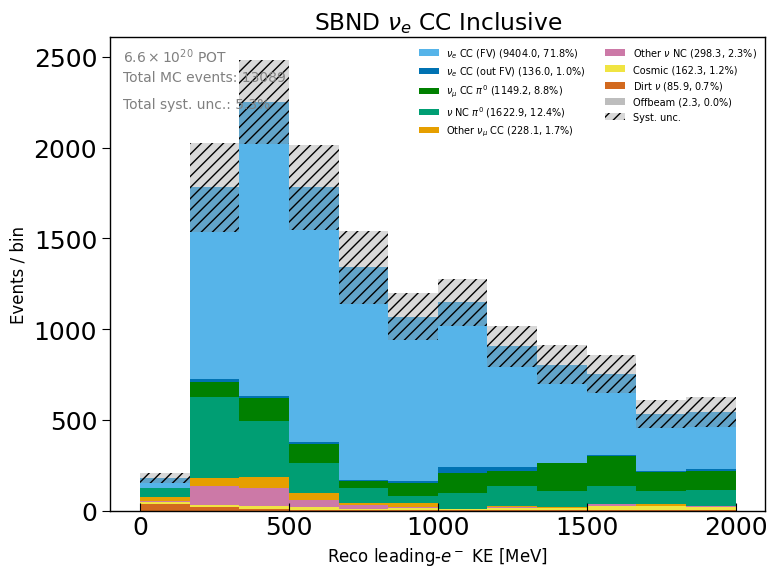

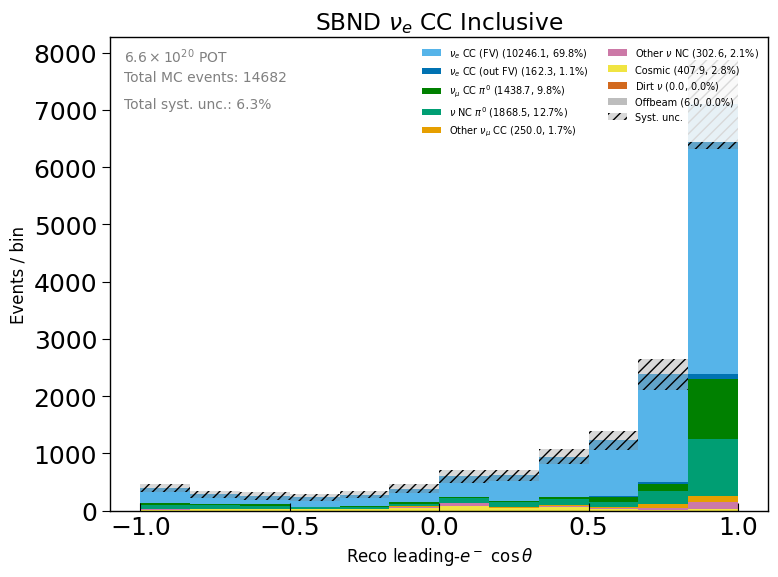

Stacked+syst -> plots_syst/


In [62]:
import nue_helpers as nh
 
DISPLAY_CATS = [0, 1, 2, 3, 4, 5, 6, 9, 7]   # 9=dirt before 7=offbeam
_labels = [nh.CAT_LABELS[c] for c in DISPLAY_CATS]
_colors = [nh.CAT_COLORS[c] for c in DISPLAY_CATS]

 
DISP_KE_BINS  = np.linspace(0, 2000, 13)
DISP_COS_BINS = np.linspace(-1, 1,   13)
DISP_BINS_UNIFORM = {'reco_ke': DISP_KE_BINS, 'reco_costheta': DISP_COS_BINS}
 
_extra_mask = sel_topo['reco_ke'].notna() & sel_topo['reco_costheta'].notna()
 
for vcfg in VAR_CFGS:
    cv        = cv_results[vcfg.name]
    covs_var  = cov_results[vcfg.name]
    total_var = sum(np.diag(_mat(covs_var[s]['cov_ms_ms'])).clip(0) for s in covs_var)

    disp_bins    = DISP_BINS_UNIFORM[vcfg.name]
    disp_centers = 0.5 * (disp_bins[:-1] + disp_bins[1:])
    frac_cv      = np.where(cv['sig_cv'] > 0,
                            np.sqrt(total_var.clip(0)) / cv['sig_cv'], 0.0)
    frac_disp    = np.interp(disp_centers, vcfg.bin_centers, frac_cv)

    series_list, weights_list, labels_all, colors_all = _build_mc_ob_series(
        sel_topo, FINAL_STAGE, vcfg.name,
        mc_weight=pot_scale,
        offbeam_vals=OFFBEAM_RECO.get(vcfg.name, np.array([])), 
        ob_weight=offbeam_scale,
        dirt_vals=LOWE_RECO_TOPO.get(vcfg.name, np.array([])),  # FIX
        dirt_weight=lowE_pot_scale_to_data,
        extra_mask=_extra_mask)

    total_disp = _total_hist(series_list, weights_list, disp_bins)
    unc_disp   = frac_disp * total_disp

    fig, ax = plt.subplots(figsize=(8, 6))
    nh.plot_stacked_hist(
        series_list=series_list, labels=labels_all, colors=colors_all,
        bins=disp_bins, weights=weights_list,
        xlabel=vcfg.var_plot_name, title=TITLE,
        pot_label=POT_LABEL, ax=ax,
        invert_stack_order=True, show_counts=True, show_percentage=True)

    bw = np.diff(disp_bins)
    ax.bar(disp_bins[:-1], 2*unc_disp, bottom=total_disp-unc_disp,
           width=bw, align='edge', alpha=0.3, color='gray',
           hatch='///', label='Syst. unc.', linewidth=0)

    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles, lbls, fontsize=7, ncol=2, loc='upper right',
              frameon=True, framealpha=0.85, edgecolor='none')

    total_frac = np.sqrt(total_var.sum()) / cv['sig_cv'].sum() \
        if cv['sig_cv'].sum() > 0 else 0

    ax.text(0.02, 0.85, f'Total syst. unc.: {total_frac*100:.1f}%',
            transform=ax.transAxes, fontsize=10, color='gray')

    fig.tight_layout()
    savefig(fig, f'{vcfg.name}_cv_with_syst_band')

print('Stacked+syst -> plots_syst/')


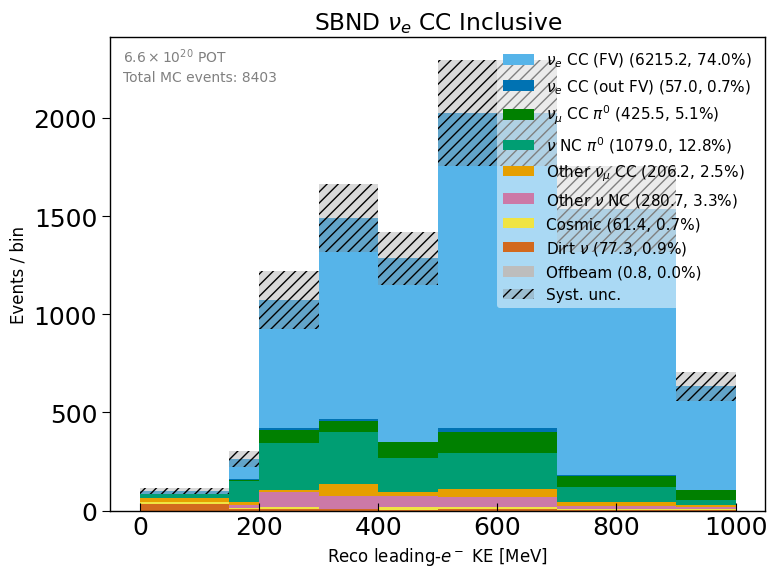

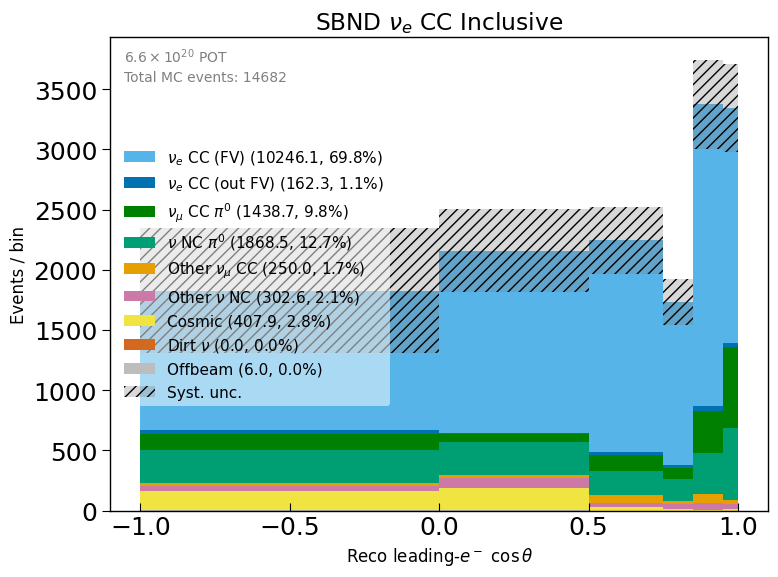

Stacked+syst (xsec bins) -> plots_syst/


In [63]:
from nue_xsec_helpers import make_nuecc_binning2d
_b2d = make_nuecc_binning2d()
_ke_edges  = np.unique(np.concatenate(_b2d.diff_momentum_bins_2d))
_ke_edges  = _ke_edges[_ke_edges <= 1000.0]
_cos_edges = _b2d.diff_costheta_bins.copy(); _cos_edges[-1] = 1.0
 
DISP_BINS_XSEC = {'reco_ke': _ke_edges, 'reco_costheta': _cos_edges, 'reco_p': _ke_edges}
 
for vcfg in VAR_CFGS:
    if vcfg.name not in DISP_BINS_XSEC:
        continue
    cv        = cv_results[vcfg.name]
    covs_var  = cov_results[vcfg.name]
    total_var = sum(np.diag(_mat(covs_var[s]['cov_ms_ms'])).clip(0) for s in covs_var)
 
    disp_bins    = DISP_BINS_XSEC[vcfg.name]
    disp_centers = 0.5 * (disp_bins[:-1] + disp_bins[1:])
    frac_cv      = np.where(cv['sig_cv'] > 0,
                            np.sqrt(total_var.clip(0)) / cv['sig_cv'], 0.0)
    frac_disp    = np.interp(disp_centers, vcfg.bin_centers, frac_cv)
 
    series_list, weights_list, labels_all, colors_all = _build_mc_ob_series(
        sel_topo, FINAL_STAGE, vcfg.name,
        mc_weight=pot_scale,
        offbeam_vals=OFFBEAM_RECO.get(vcfg.name, np.array([])),
        ob_weight=offbeam_scale,
        dirt_vals=LOWE_RECO_TOPO.get(vcfg.name, np.array([])),
        dirt_weight=lowE_pot_scale_to_data,
        extra_mask=_extra_mask)
 
    total_disp = _total_hist(series_list, weights_list, disp_bins)
    unc_disp   = frac_disp * total_disp
 
    fig, ax = plt.subplots(figsize=(8, 6))
    nh.plot_stacked_hist(
        series_list=series_list, labels=labels_all, colors=colors_all,
        bins=disp_bins, weights=weights_list,
        xlabel=vcfg.var_plot_name, title=TITLE,
        pot_label=POT_LABEL, ax=ax,
        invert_stack_order=True, show_counts=True, show_percentage=True)
 
    bw = np.diff(disp_bins)
    ax.bar(disp_bins[:-1], 2*unc_disp, bottom=total_disp-unc_disp,
           width=bw, align='edge', alpha=0.3, color='gray',
           hatch='///', label='Syst. unc.', linewidth=0)
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles, lbls, fontsize=11, ncol=1, loc='best',
              frameon=True, framealpha=0.5, edgecolor='none')
    fig.tight_layout()
    savefig(fig, f'{vcfg.name}_cv_with_syst_band_xsecbins')
 
print('Stacked+syst (xsec bins) -> plots_syst/')


In [64]:
print(f'\n{"="*68}')
print(f'{"Variable":<16} {"Source":<10} {"Category":<14} {"Mean frac. unc.":>16}')
print(f'{"="*68}')
for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    for src, covs in cov_results[vcfg.name].items():
        for bk, categ, cv_arr in [
            ('cov_ms_ms', 'Signal',     cv['sig_cv']),
            ('cov_bs_bs', 'Background', cv['bkg_cv']),
        ]:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                frac = np.where(cv_arr > 0,
                    np.sqrt(np.diag(_mat(covs[bk])).clip(0)) / cv_arr, np.nan)
            fu = float(np.nanmean(frac))
            print(f'  {vcfg.name:<14} {src:<10} {categ:<14} {fu*100:>14.2f}%')
print(f'{"="*68}')
print(f'\nNPZ files -> {SYST_DIR}/')
for vcfg in VAR_CFGS:
    vd = f'{SYST_DIR}/{vcfg.name}'
    if os.path.isdir(vd):
        print(f'  {vcfg.name}: {os.listdir(vd)}')
print(f'Plots     -> {PLOT_DIR}/')
for sub in ['univ', 'cov', 'fracunc']:
    sd = f'{PLOT_DIR}/{sub}'
    if os.path.isdir(sd):
        print(f'  {sub}/: {len(os.listdir(sd))} files')



Variable         Source     Category        Mean frac. unc.
  reco_ke        genie      Signal                   6.92%
  reco_ke        genie      Background              11.15%
  reco_ke        extra_xsec Signal                   6.39%
  reco_ke        extra_xsec Background               8.48%
  reco_ke        g4         Signal                   6.55%
  reco_ke        g4         Background              10.80%
  reco_ke        mcstat     Signal                   5.89%
  reco_ke        mcstat     Background              12.41%
  reco_ke        pot        Signal                   2.00%
  reco_ke        pot        Background               2.00%
  reco_ke        ntargets   Signal                   1.00%
  reco_ke        ntargets   Background               1.00%
  reco_costheta  genie      Signal                   9.86%
  reco_costheta  genie      Background              23.85%
  reco_costheta  extra_xsec Signal                   9.41%
  reco_costheta  extra_xsec Background              21

## 14. Data added: Unblind analysis

In [65]:
# CELL A (unblinding setup) — add offbeam FV/topo/final stage indices
# ══════════════════════════════════════════════════════════════════════════════
 
import nue_selection as nue_sel
import os, gc, warnings
 
UNBLIND_DIR  = f'{PLOT_DIR}/unblinding'
SIDEBAND_DIR = f'{PLOT_DIR}/sideband'
for d in [UNBLIND_DIR, SIDEBAND_DIR]: os.makedirs(d, exist_ok=True)
 
# Fractional syst (sig+bkg) from covariance
def get_total_frac_unc(var_name):
    cv = cv_results[var_name]; covs_var = cov_results[var_name]
    vs = sum(np.diag(_mat(covs_var[s]['cov_ms_ms'])).clip(0) for s in covs_var)
    vb = sum(np.diag(_mat(covs_var[s]['cov_bs_bs'])).clip(0) for s in covs_var)
    tmc = cv['sig_cv'] + cv['bkg_cv']
    frac = np.where(tmc > 0, np.sqrt((vs+vb).clip(0)) / tmc, 0.0)
    vcfg = next(v for v in VAR_CFGS if v.name == var_name)
    return vcfg.bin_centers, frac
 
cov_centers_ke,  frac_unc_ke  = get_total_frac_unc('reco_ke')
cov_centers_cos, frac_unc_cos = get_total_frac_unc('reco_costheta')
 
def interp_frac_unc(disp_bins, proxy='reco_ke'):
    c = 0.5*(disp_bins[:-1]+disp_bins[1:])
    if proxy == 'reco_costheta':
        return np.interp(c, cov_centers_cos, frac_unc_cos,
                         left=frac_unc_cos[0], right=frac_unc_cos[-1])
    return np.interp(c, cov_centers_ke, frac_unc_ke,
                     left=frac_unc_ke[0], right=frac_unc_ke[-1])
 
from nue_xsec_helpers import make_nuecc_binning2d   # already loaded above
XSEC_KE_BINS  = np.unique(np.concatenate(_b2d.diff_momentum_bins_2d))
XSEC_KE_BINS  = XSEC_KE_BINS[XSEC_KE_BINS <= 2000.0]
XSEC_COS_BINS = _b2d.diff_costheta_bins.copy(); XSEC_COS_BINS[-1] = 1.0
 
from mem_optimizer import load_evtdf_slim
mc_evtdf_ub = load_evtdf_slim(DF_FILE, key="evt_0", mode="reco_min_true")
mc_il       = list(range(mc_evtdf_ub.index.nlevels - 1))
data_il_ub  = list(range(data_evtdf_patched.index.nlevels - 1))
 
MC_FV_IDX    = sel_topo.index[sel_topo['sel_fiducial']]
MC_TOPO_IDX  = sel_topo.index[sel_topo['sel_single_electron']]
MC_FINAL_IDX = sel_topo.index[sel_topo[FINAL_STAGE]]
DATA_FV_IDX    = data_cut_flow['fiducial']['inter_index']
DATA_TOPO_IDX  = data_cut_flow['single_electron']['inter_index']
DATA_FINAL_IDX = data_cut_flow[FINAL_STAGE.replace('sel_','')]['inter_index']
 
truth_cat_fv    = sel_topo.loc[MC_FV_IDX,    'truth_cat']
truth_cat_topo  = sel_topo.loc[MC_TOPO_IDX,  'truth_cat']
truth_cat_final = sel_topo.loc[MC_FINAL_IDX, 'truth_cat']
 
KINE_VARS = [
    ('reco_ke',       r'Reco leading-$e^-$ KE [MeV]',     XSEC_KE_BINS,  'reco_ke'),
    ('reco_costheta', r'Reco leading-$e^-$ $\cos\theta$',  XSEC_COS_BINS, 'reco_costheta'),
]
 
print(f"MC  FV={len(MC_FV_IDX):,}  topo={len(MC_TOPO_IDX):,}  final={len(MC_FINAL_IDX):,}")
print(f"Data FV={len(DATA_FV_IDX):,}  topo={len(DATA_TOPO_IDX):,}  final={len(DATA_FINAL_IDX):,}")


load_evtdf_slim  mode='reco_min_true'  key='evt_0'
  Total cols :  393  →  kept:  124  dropped:  269  (68% reduced)
  Group                            all   kept
  ------------------------------------------
  dlp_reco_interaction              32     32
  dlp_reco_particle                 72     72
  dlp_true_interaction              68      0  ← dropped 68
  dlp_true_particle                113     16  ← dropped 97
  mcnu                             104      0  ← dropped 104
  index_artifact                     4      4
  other                              0      0

  Loading full df then dropping columns (fixed-format HDF5) …
  Post-drop complete. Final shape: (4597004, 124)
MC  FV=980,816  topo=28,494  final=3,800
Data FV=35,037  topo=922  final=110



STAGE 1: Vertex (after FV cut)
  After FV cut / Reco vertex x [cm]:
    Data/Pred = 0.997 ± 0.005 (stat.) ± 0.027 (syst.)
    chi2/ndf = 95.7/20  p = 0.000


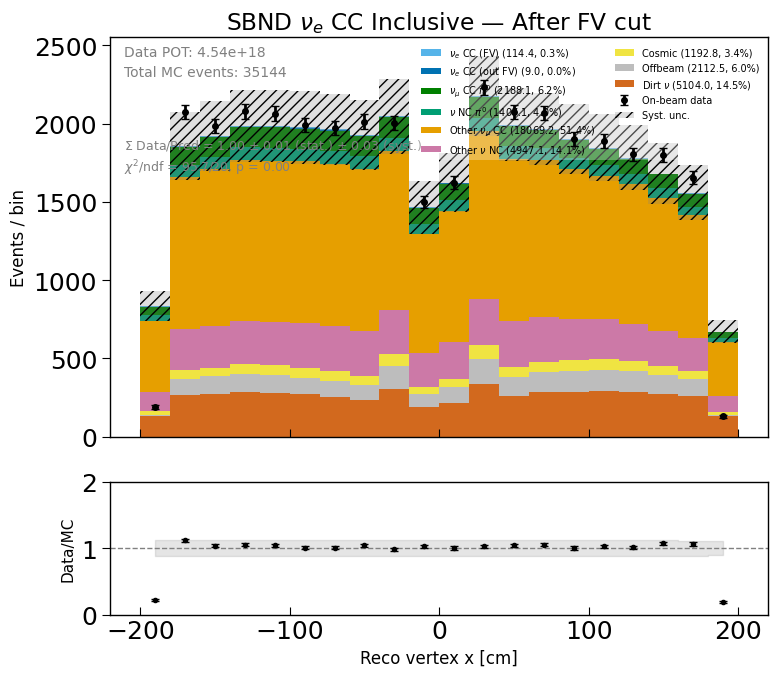

  After FV cut / Reco vertex y [cm]:
    Data/Pred = 0.997 ± 0.005 (stat.) ± 0.027 (syst.)
    chi2/ndf = 154.5/20  p = 0.000


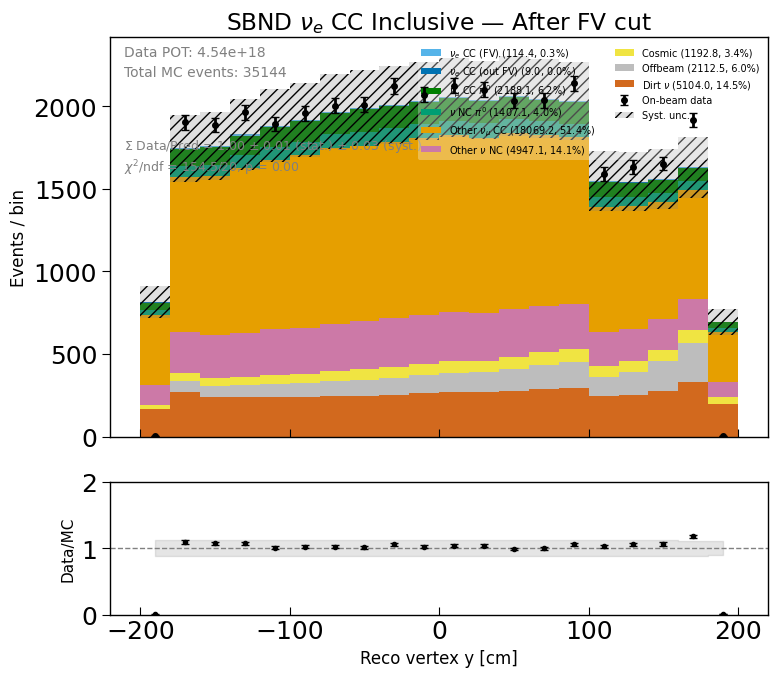

  After FV cut / Reco vertex z [cm]:
    Data/Pred = 0.997 ± 0.005 (stat.) ± 0.023 (syst.)
    chi2/ndf = 9.6/25  p = 0.998


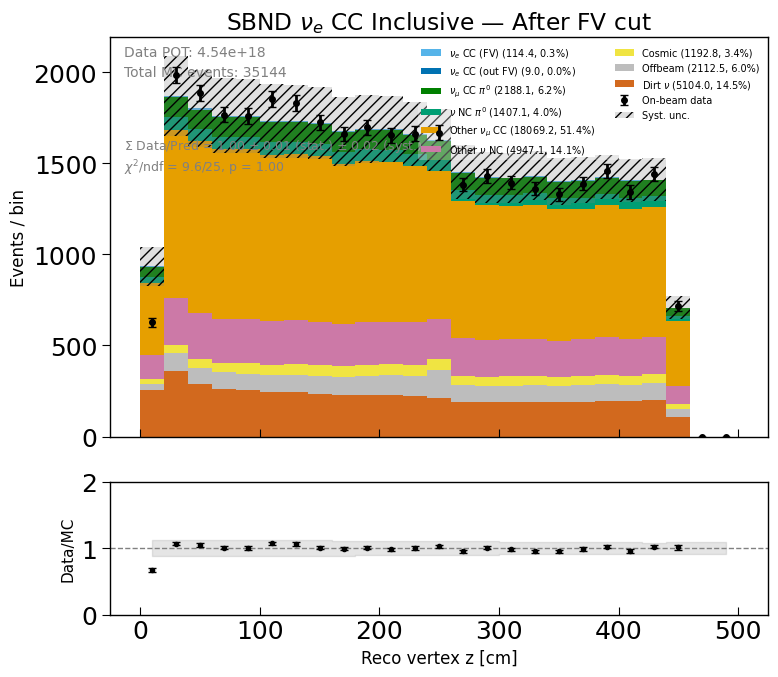

In [66]:
# ── Cell B: Vertex (FV stage) ─────────────────────────────────────────────────
print("\n" + "="*70 + "\nSTAGE 1: Vertex (after FV cut)\n" + "="*70)
 
VCANDS = {
    'x': [('vertex','x',''),('vertex','x'),('vertex','I0',''),('vertex','I0')],
    'y': [('vertex','y',''),('vertex','y'),('vertex','I1',''),('vertex','I1')],
    'z': [('vertex','z',''),('vertex','z'),('vertex','I2',''),('vertex','I2')],
}
VBINS = {'x': np.linspace(-200,200,21),
         'y': np.linspace(-200,200,21),
         'z': np.linspace(0,500,26)}
VLBL  = {'x':'Reco vertex x [cm]',
         'y':'Reco vertex y [cm]',
         'z':'Reco vertex z [cm]'}
 
def _find_col(cols, cands):
    for cc in cands:
        if cc in cols: return cc
    for cc in cols:
        if isinstance(cc, tuple):
            for cand in cands:
                if isinstance(cand, tuple) and cand[0] in cc and cand[1] in cc:
                    return cc
    return None
 
ri_mc   = nh.reco_interactions(mc_evtdf_ub)._df.sort_index()
ri_data = nh.reco_interactions(data_evtdf_patched)._df.sort_index()
 
for coord in ['x', 'y', 'z']:
    mc_col   = _find_col(ri_mc.columns,   VCANDS[coord])
    data_col = _find_col(ri_data.columns, VCANDS[coord])
    if mc_col is None or data_col is None:
        print(f"  vertex {coord} not found"); continue
    mc_v   = ri_mc[mc_col].groupby(level=mc_il).first().reindex(MC_FV_IDX).dropna()
    data_v = ri_data[data_col].groupby(level=data_il_ub).first().reindex(DATA_FV_IDX).dropna()
    nh.plot_unblinding_var(
        mc_vals=mc_v,
        data_vals=data_v.values,
        truth_cat=truth_cat_fv,
        bins=VBINS[coord],
        xlabel=VLBL[coord],
        stage_name='After FV cut',
        pot_scale_data=pot_scale_to_data,
        data_pot=data_total_pot,
    
        frac_unc_per_bin=interp_frac_unc(VBINS[coord]),
    
        offbeam_vals=OFFBEAM_VERTEX.get(coord, np.array([])),
        offbeam_weight=offbeam_scale,
    
        dirt_vals=LOWE_VERTEX.get(coord, np.array([])),
        dirt_weight=lowE_pot_scale_to_data,
    
        savefig_fn=savefig,
        filename=f'vertex_{coord}_fv'
    )


STAGE 2: Multiplicity (after FV cut)
  After FV cut / N showers:
    Data/Pred = 0.996 ± 0.005 (stat.) ± 0.053 (syst.)
    chi2/ndf = 2.2/10  p = 0.994


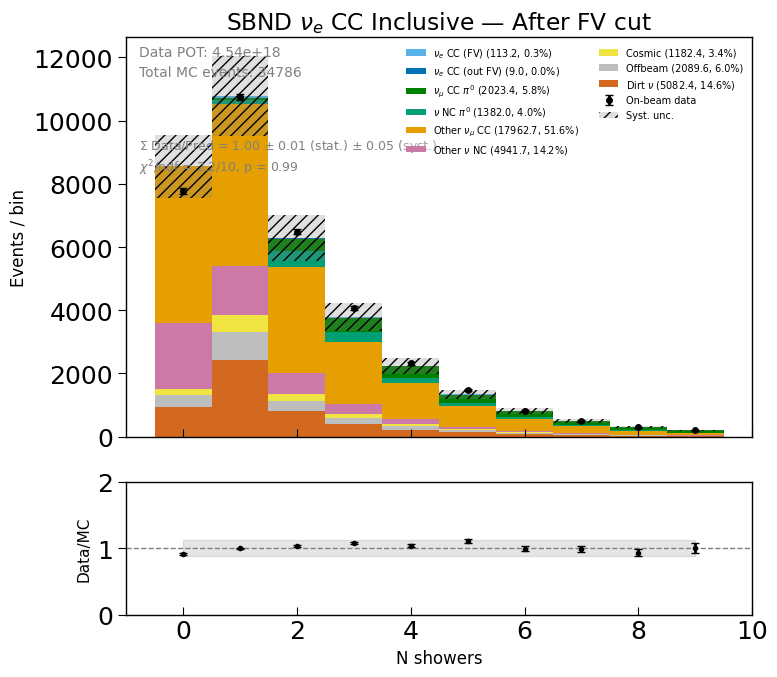

  After FV cut / N tracks:
    Data/Pred = 1.001 ± 0.005 (stat.) ± 0.052 (syst.)
    chi2/ndf = 35.5/10  p = 0.000


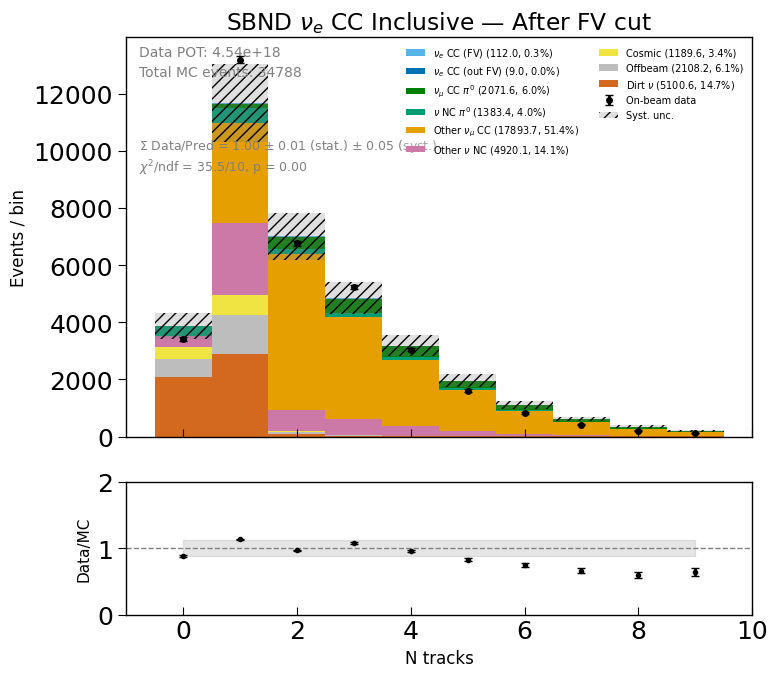

In [68]:
# ── Cell C: Multiplicity (FV stage) ──────────────────────────────────────────
print("\n" + "="*70 + "\nSTAGE 2: Multiplicity (after FV cut)\n" + "="*70)

LOWE_MULT = {}

def _count_parts(evtdf, idx, il, ptype):
    rp      = nh.reco_particles(evtdf)._df
    pid_col = ('pid','') if ('pid','') in rp.columns else 'pid'
    parts   = rp[rp.index.droplevel(-1).isin(idx)]
    mask    = parts[pid_col].isin([0,1] if ptype == 'shower' else [2,3,4])
    return mask.groupby(level=il).sum().reindex(idx, fill_value=0)
    
for pt in ['shower','track']:
    LOWE_MULT[pt] = _count_parts(
        lowE_evtdf,
        lowE_cut_flow['fiducial']['inter_index'],
        lowE_il,
        pt
    ).values

 
bm = np.arange(-0.5, 10.5, 1)
for pt, xl in [('shower', 'N showers'), ('track', 'N tracks')]:
    mc_c   = _count_parts(mc_evtdf_ub,       MC_FV_IDX,   mc_il,      pt)
    data_c = _count_parts(data_evtdf_patched, DATA_FV_IDX, data_il_ub, pt)
    nh.plot_unblinding_var(
        mc_vals=mc_c, data_vals=data_c.values, truth_cat=truth_cat_fv,
        bins=bm, xlabel=xl, stage_name='After FV cut',
        pot_scale_data=pot_scale_to_data, data_pot=data_total_pot,
        frac_unc_per_bin=interp_frac_unc(bm),
        offbeam_vals=OFFBEAM_MULT.get(pt, np.array([])),
        offbeam_weight=offbeam_scale,
        dirt_vals=LOWE_MULT.get(pt, np.array([])),
        dirt_weight=lowE_pot_scale_to_data,
        savefig_fn=savefig, filename=f'mult_{pt}_fv')


STAGE 3: Shower quality (after topology cut)

  primary_scores: MC=28,494  Data=922
  After topology cut / Primary score:
    Data/Pred = 1.025 ± 0.034 (stat.) ± 0.093 (syst.)
    chi2/ndf = 5.3/20  p = 1.000


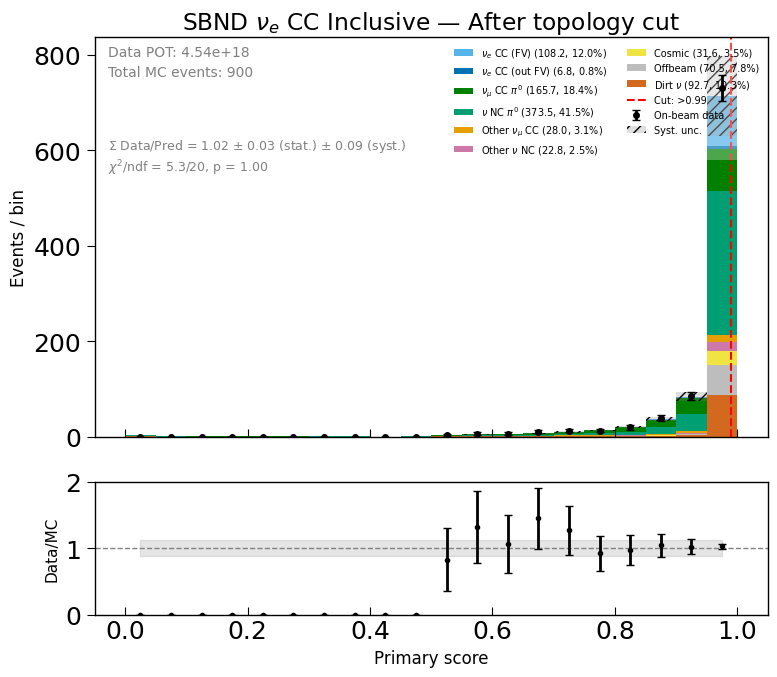


  pid_scores: MC=28,494  Data=922
  After topology cut / PID score:
    Data/Pred = 1.025 ± 0.034 (stat.) ± 0.038 (syst.)
    chi2/ndf = 3.4/20  p = 1.000


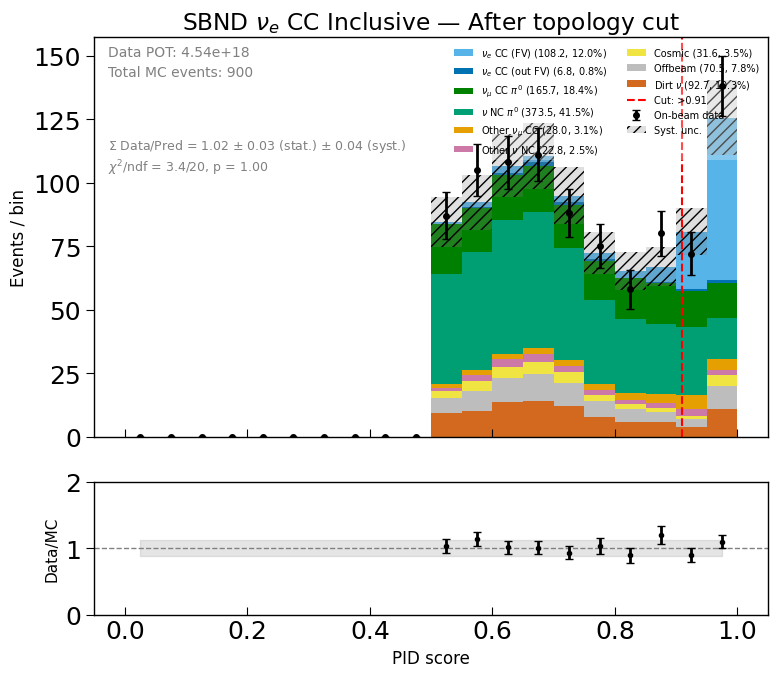


  vertex_distance: MC=28,494  Data=922
  After topology cut / Conversion gap [cm]:
    Data/Pred = 0.996 ± 0.036 (stat.) ± 0.070 (syst.)
    chi2/ndf = 21.7/20  p = 0.356


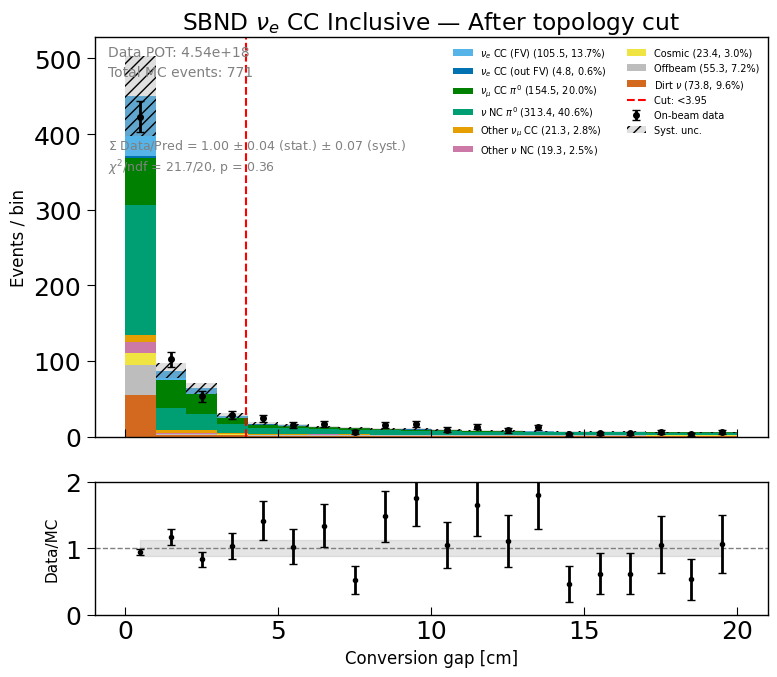


  start_dedx: MC=28,494  Data=922
  After topology cut / Start $dE/dx$ [MeV/cm]:
    Data/Pred = 1.042 ± 0.035 (stat.) ± 0.034 (syst.)
    chi2/ndf = 14.5/20  p = 0.804


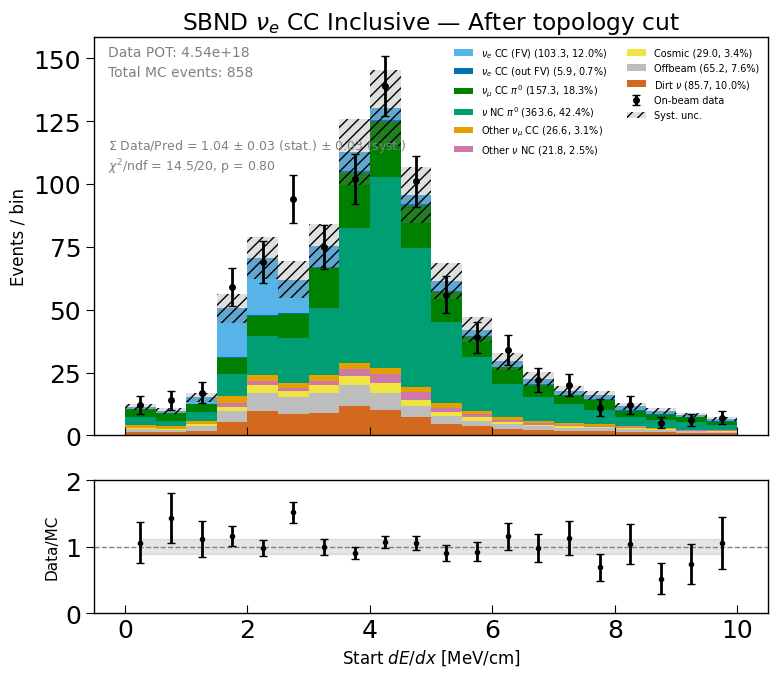


  calo_ke: MC=28,494  Data=922
  After topology cut / Calo KE [MeV]:
    Data/Pred = 1.029 ± 0.034 (stat.) ± 0.046 (syst.)
    chi2/ndf = 32.4/20  p = 0.039


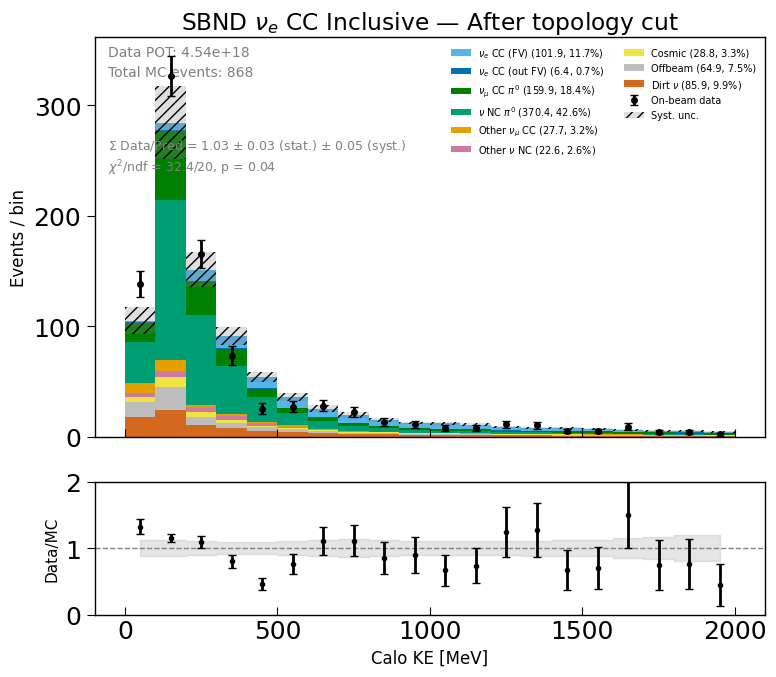

In [69]:
# ── Cell D: Shower quality (topology stage) ───────────────────────────────────
print("\n" + "="*70 + "\nSTAGE 3: Shower quality (after topology cut)\n" + "="*70)
 
import nue_selection as nue_sel
 
SHOWER_VARS = [
    (('primary_scores','I1'), 'Primary score',          np.linspace(0,1,21),    nue_sel.THRESH_PRIMARY_SCORE, '>'),
    (('pid_scores','I1'),     'PID score',               np.linspace(0,1,21),    nue_sel.THRESH_PID_SCORE,     '>'),
    (('vertex_distance',''),  'Conversion gap [cm]',     np.linspace(0,20,21),   nue_sel.THRESH_VERTEX_DIST,   '<'),
    (('start_dedx',''),       r'Start $dE/dx$ [MeV/cm]', np.linspace(0,10,21),  None,                         None),
    (('calo_ke',''),          'Calo KE [MeV]',           np.linspace(0,2000,21), None,                         None),
]

LOWE_SHOWER_VARS = {}

for col_key, _, _, _, _ in SHOWER_VARS:
    vn = col_key[0]

    vals = nh._get_leading_electron_var(
        lowE_evtdf,
        col_key,
        lowE_topo_idx,
        lowE_il
    )

    LOWE_SHOWER_VARS[vn] = (
        vals.dropna().values
        if not vals.empty else np.array([])
    )
for col_key, xlabel, bins, cut_val, cut_dir in SHOWER_VARS:
    mc_var   = nh._get_leading_electron_var(mc_evtdf_ub,       col_key, MC_TOPO_IDX,   mc_il)
    data_var = nh._get_leading_electron_var(data_evtdf_patched, col_key, DATA_TOPO_IDX, data_il_ub)
    vn = col_key[0] if isinstance(col_key, tuple) else col_key
    nm, nd = mc_var.notna().sum(), data_var.notna().sum()
    print(f"\n  {vn}: MC={nm:,}  Data={nd:,}")
    if nm == 0: print("    Not found — skipping"); continue
    nh.plot_unblinding_var(
        mc_vals=mc_var,
        data_vals=data_var.dropna().values if nd > 0 else np.array([]),
        truth_cat=truth_cat_topo,
        bins=bins, xlabel=xlabel, stage_name='After topology cut',
        pot_scale_data=pot_scale_to_data, data_pot=data_total_pot,
        frac_unc_per_bin=interp_frac_unc(bins),
        offbeam_vals=OFFBEAM_SHOWER_VARS.get(vn,np.array([])),
        offbeam_weight=offbeam_scale,
        dirt_vals=LOWE_SHOWER_VARS.get(vn,np.array([])),
        dirt_weight=lowE_pot_scale_to_data,
        savefig_fn=savefig, filename=f'unblind_{vn}_topo',
        cut_val=cut_val, cut_dir=cut_dir)


STAGE 4: Kinematics (final selection, xsec bins)
  Final selection / Reco leading-$e^-$ KE [MeV]:
    Data/Pred = 0.987 ± 0.102 (stat.) ± 0.047 (syst.)
    chi2/ndf = 9.9/10  p = 0.447


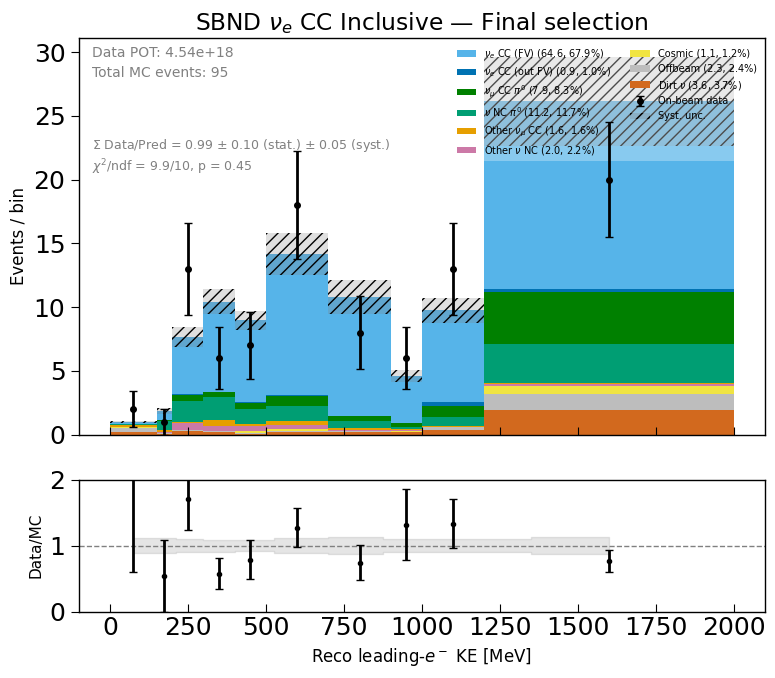

  Final selection / Reco leading-$e^-$ $\cos\theta$:
    Data/Pred = 1.030 ± 0.098 (stat.) ± 0.061 (syst.)
    chi2/ndf = 5.6/6  p = 0.471


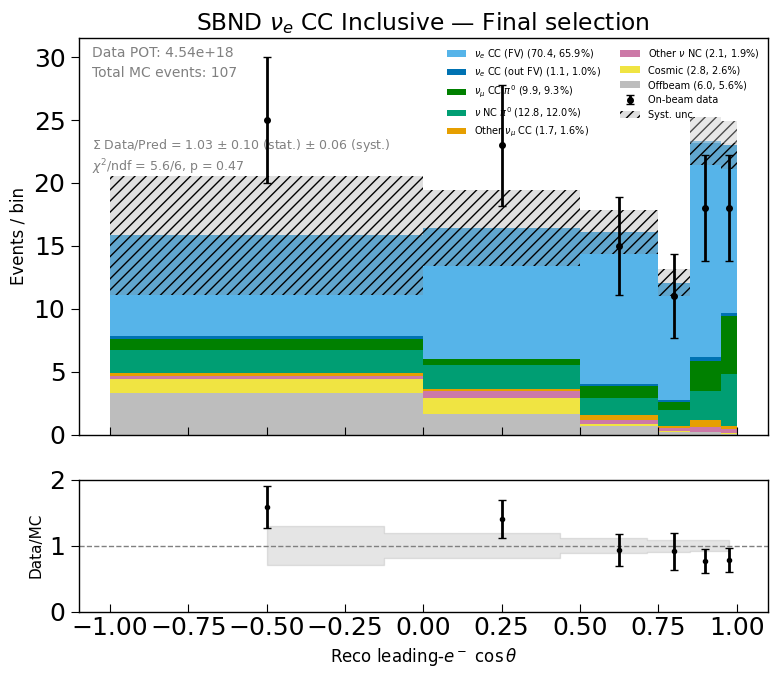

In [70]:
# ── Cell E: Kinematics (final selection) ──────────────────────────────────────
print("\n" + "="*70 + "\nSTAGE 4: Kinematics (final selection, xsec bins)\n" + "="*70)
 
for vn, xl, bins, proxy in KINE_VARS:
    mc_var = sel_topo.loc[MC_FINAL_IDX, vn].dropna()
    nh.plot_unblinding_var(
        mc_vals=mc_var, data_vals=DATA_RECO.get(vn, np.array([])),
        truth_cat=truth_cat_final, bins=bins, xlabel=xl,
        stage_name='Final selection',
        pot_scale_data=pot_scale_to_data, data_pot=data_total_pot,
        frac_unc_per_bin=interp_frac_unc(bins, proxy),
        offbeam_vals=OFFBEAM_RECO.get(vn,np.array([])),
        offbeam_weight=offbeam_scale,
        dirt_vals=LOWE_RECO_FINAL.get(vn,np.array([])),
        dirt_weight=lowE_pot_scale_to_data,
        savefig_fn=savefig, filename=f'unblind_{vn}_final')

## 15. Sideband selection

In [71]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL F: Sideband selection
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70 + "\nSIDEBAND SELECTION\n" + "="*70)
 
_SB_THRESH_VD    = nue_sel.THRESH_VERTEX_DIST
_SB_THRESH_PID   = nue_sel.THRESH_PID_SCORE
_SB_THRESH_DX_LO = nue_sel.THRESH_SB_DEDX_LO
_SB_THRESH_DX_HI = nue_sel.THRESH_SB_DEDX_HI
 
def build_sideband_idx(evtdf, topo_idx, il):
    rp   = nh.reco_particles(evtdf)._df
    ke_c = ('ke','')  if ('ke','')  in rp.columns else 'ke'
    pi_c = ('pid','') if ('pid','') in rp.columns else 'pid'
    ele  = rp[rp.index.droplevel(-1).isin(topo_idx) & (rp[pi_c]==1)]
    if ele.empty: return pd.Index([])
    li  = ele[ke_c].groupby(level=il).idxmax().dropna()
    if li.empty: return pd.Index([])
    lmi = pd.MultiIndex.from_tuples(li.values, names=ele.index.names)
    ld  = ele.loc[lmi].copy(); ld.index = li.index
    vd_c, ps_c, dx_c = ('vertex_distance',''), ('pid_scores','I1'), ('start_dedx','')
    sb = pd.Series(True, index=ld.index)
    if vd_c in ld.columns:
        sb &= (ld[vd_c] > _SB_THRESH_VD)
    else:
        print("  WARNING: vertex_distance not found")
    if ps_c in ld.columns:
        sb &= (ld[ps_c] < _SB_THRESH_PID)
    else:
        print("  WARNING: pid_scores not found")
    if dx_c in ld.columns:
        sb &= (ld[dx_c] > _SB_THRESH_DX_LO) & (ld[dx_c] < _SB_THRESH_DX_HI)
    else:
        print("  WARNING: start_dedx not found — dE/dx cut skipped")
    return ld.index[sb]
 
MC_SB_IDX   = build_sideband_idx(mc_evtdf_ub, MC_TOPO_IDX, mc_il)
DATA_SB_IDX = build_sideband_idx(data_evtdf_patched, DATA_TOPO_IDX, data_il_ub)
LOWE_SB_IDX = build_sideband_idx(lowE_evtdf,lowE_topo_idx,lowE_il)
truth_cat_sb = sel_topo.loc[MC_SB_IDX, 'truth_cat']
 
print(f"Sideband: MC={len(MC_SB_IDX):,}  Data={len(DATA_SB_IDX):,}")
_cn = {0:"νe CC FV",1:"νe CC out-FV",2:"νμ CC π0",3:"NC π0",
       4:"other νμ CC",5:"other NC",6:"cosmic"}
_ns = len(MC_SB_IDX)
for cat in [0,1,2,3,4,5,6]:
    n = (truth_cat_sb==cat).sum()
    if _ns>0: print(f"  cat {cat} ({_cn.get(cat,'?'):<16s}): {n:>6,}  ({n/_ns*100:.1f}%)")
print(f"  Signal contamination: {(truth_cat_sb==0).sum()/_ns*100:.1f}%" if _ns>0 else "")
 
rp_sb = nh.reco_particles(data_evtdf_patched)._df
_kc = ('ke','') if ('ke','') in rp_sb.columns else 'ke'
_pc = ('pid','') if ('pid','') in rp_sb.columns else 'pid'
_cc = ('calo_ke','') if ('calo_ke','') in rp_sb.columns else 'calo_ke'
_esb = rp_sb[rp_sb.index.droplevel(-1).isin(DATA_SB_IDX) & (rp_sb[_pc]==1)]
DATA_SB_RECO = {}
if not _esb.empty:
    _ks = _esb[_cc] if _cc in _esb.columns else _esb[_kc]
    _li = _ks.groupby(level=data_il_ub).idxmax().dropna()
    if not _li.empty:
        _lmi = pd.MultiIndex.from_tuples(_li.values, names=_esb.index.names)
        _ld  = _esb.loc[_lmi].copy(); _ld.index = _li.index
        DATA_SB_RECO['reco_ke'] = _ld[_cc if _cc in _ld.columns else _kc].dropna().values
        _m_e = 0.511
        DATA_SB_RECO['reco_p'] = np.sqrt(((DATA_SB_RECO['reco_ke']+_m_e)**2 - _m_e**2).clip(0))
        try:
            dx=[c for c in rp_sb.columns if 'start_dir' in str(c) and 'I0' in str(c)][0]
            dy=[c for c in rp_sb.columns if 'start_dir' in str(c) and 'I1' in str(c)][0]
            dz=[c for c in rp_sb.columns if 'start_dir' in str(c) and 'I2' in str(c)][0]
            dd=_esb.loc[_lmi,[dx,dy,dz]].copy(); dd.index=_li.index
            pm=np.sqrt(dd[dx]**2+dd[dy]**2+dd[dz]**2).replace(0,np.nan)
            DATA_SB_RECO['reco_costheta']=(dd[dz]/pm).dropna().values
        except: DATA_SB_RECO['reco_costheta']=np.array([])
print(f"Data sideband: KE={len(DATA_SB_RECO.get('reco_ke',[])):,}, "
      f"cos={len(DATA_SB_RECO.get('reco_costheta',[])):,}")


SIDEBAND SELECTION
Sideband: MC=5,063  Data=168
  cat 0 (νe CC FV        ):     33  (0.7%)
  cat 1 (νe CC out-FV    ):     58  (1.1%)
  cat 2 (νμ CC π0        ):    470  (9.3%)
  cat 3 (NC π0           ):  3,333  (65.8%)
  cat 4 (other νμ CC     ):    123  (2.4%)
  cat 5 (other NC        ):    123  (2.4%)
  cat 6 (cosmic          ):    226  (4.5%)
  Signal contamination: 0.7%
Data sideband: KE=168, cos=168



SIDEBAND PLOTS
  Sideband (photon-enriched) / Reco leading-$e^-$ KE [MeV]:
    Data/Pred = 0.765 ± 0.059 (stat.) ± 0.049 (syst.)
    chi2/ndf = 32.5/10  p = 0.000


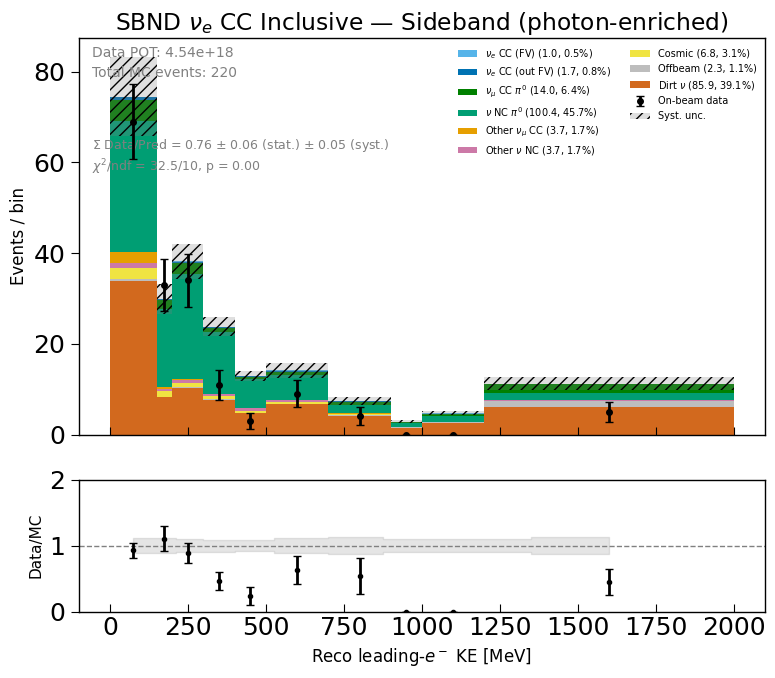

  Sideband (photon-enriched) / Reco leading-$e^-$ $\cos\theta$:
    Data/Pred = 1.221 ± 0.094 (stat.) ± 0.083 (syst.)
    chi2/ndf = 6.0/6  p = 0.423


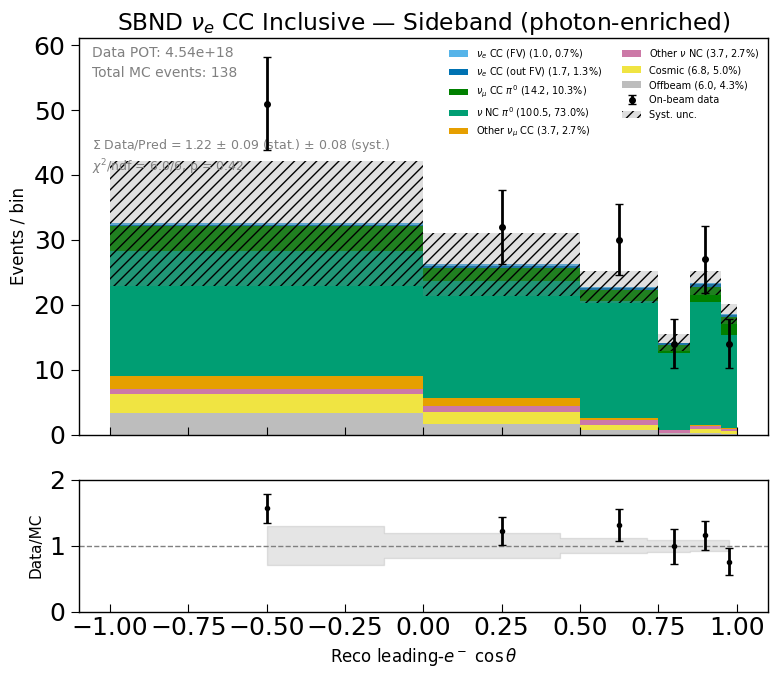


Sideband shower variables:
  primary_scores: MC=5,063  Data=168  Dirt=6,950
  Sideband / Primary score:
    Data/Pred = 0.570 ± 0.044 (stat.) ± 0.103 (syst.)
    chi2/ndf = 15.3/20  p = 0.757


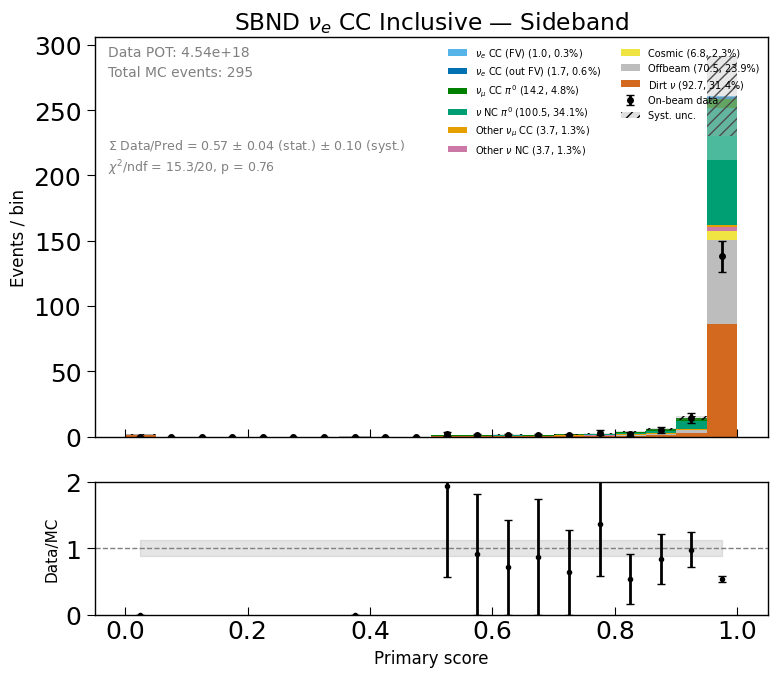

  pid_scores: MC=5,063  Data=168  Dirt=6,950
  Sideband / PID score:
    Data/Pred = 0.570 ± 0.044 (stat.) ± 0.040 (syst.)
    chi2/ndf = 51.6/20  p = 0.000


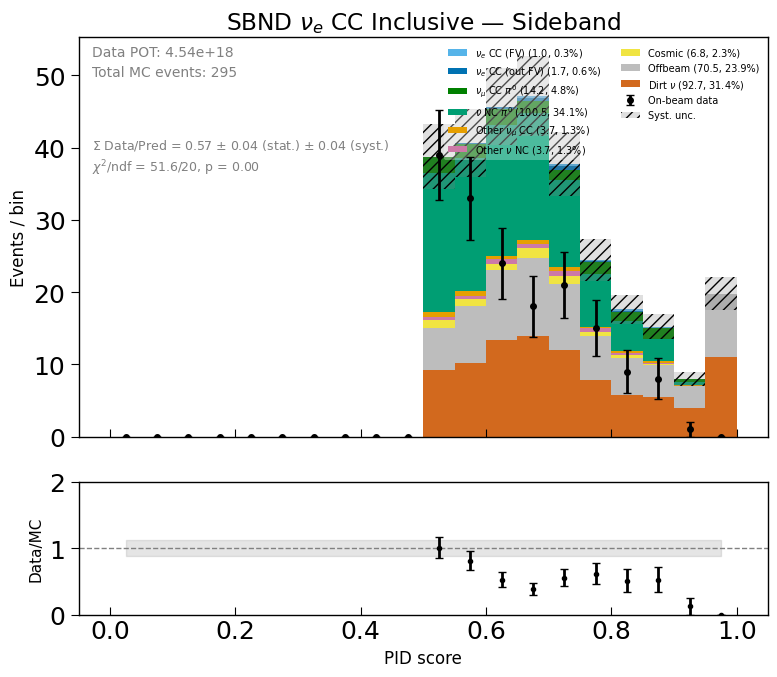

  vertex_distance: MC=5,063  Data=168  Dirt=6,950
  Sideband / Conversion gap [cm]:
    Data/Pred = 0.419 ± 0.046 (stat.) ± 0.057 (syst.)
    chi2/ndf = 68.6/20  p = 0.000


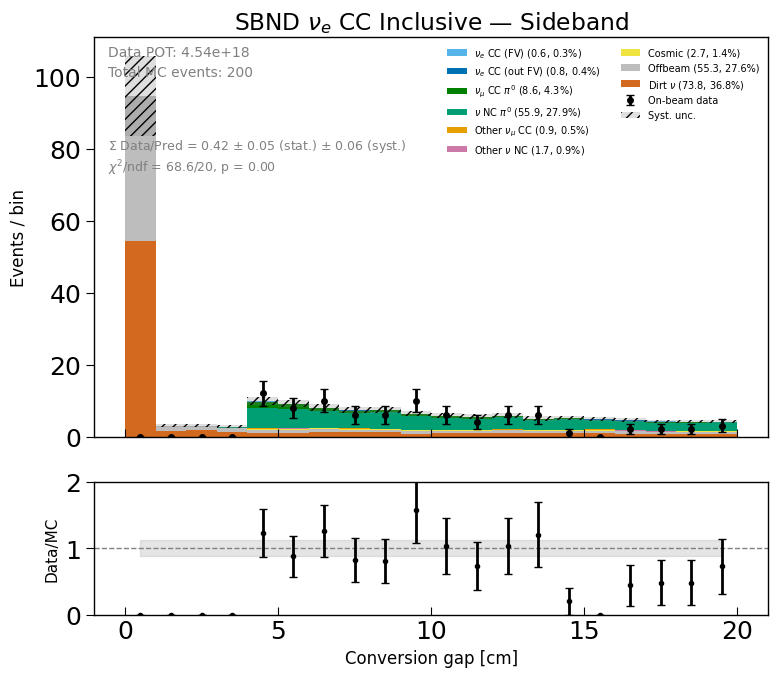

  start_dedx: MC=5,063  Data=168  Dirt=6,950
  Sideband / Start $dE/dx$ [MeV/cm]:
    Data/Pred = 0.595 ± 0.046 (stat.) ± 0.040 (syst.)
    chi2/ndf = 60.1/20  p = 0.000


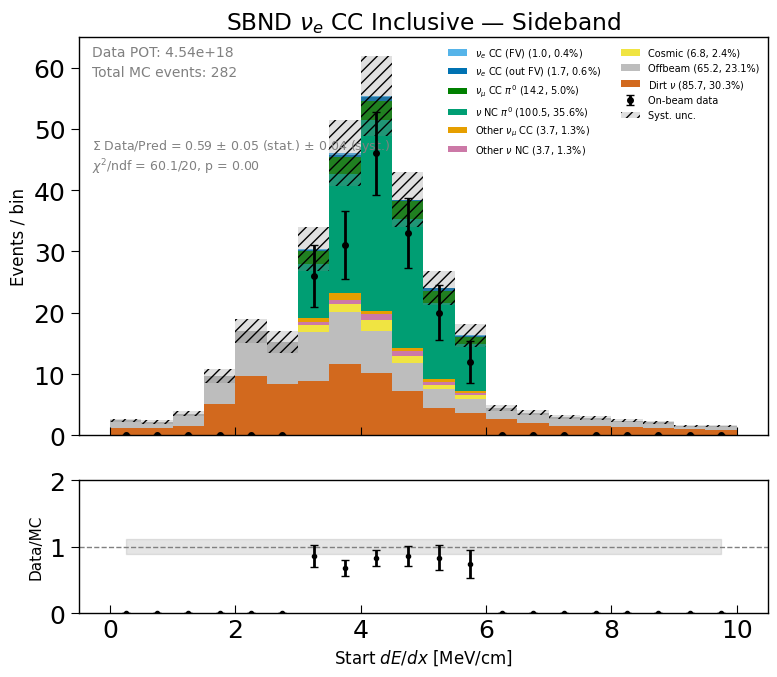

In [72]:
# ══════════════════════════════════════════════════════════════════════════════
# CELLS G-H: Sideband plots + chi2 summary
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70 + "\nSIDEBAND PLOTS\n" + "="*70)

for vn, xl, bins, proxy in KINE_VARS:
    mc_v = sel_topo.loc[MC_SB_IDX, vn].dropna()
    nh.plot_unblinding_var(
        mc_vals=mc_v, data_vals=DATA_SB_RECO.get(vn, np.array([])),
        truth_cat=truth_cat_sb, bins=bins, xlabel=xl,
        stage_name='Sideband (photon-enriched)',
        pot_scale_data=pot_scale_to_data, data_pot=data_total_pot,
        frac_unc_per_bin=interp_frac_unc(bins, proxy),
        offbeam_vals=OFFBEAM_RECO.get(vn,np.array([])),
        offbeam_weight=offbeam_scale,
        dirt_vals=LOWE_RECO_TOPO.get(vn,np.array([])),
        dirt_weight=lowE_pot_scale_to_data,
        savefig_fn=savefig, filename=f'sideband_{vn}', save_subdir='sideband')

SB_SHOWER = [
    (('primary_scores','I1'), 'Primary score',       np.linspace(0,1,21)),
    (('pid_scores','I1'),     'PID score',            np.linspace(0,1,21)),
    (('vertex_distance',''),  'Conversion gap [cm]',  np.linspace(0,20,21)),
    (('start_dedx',''),       r'Start $dE/dx$ [MeV/cm]', np.linspace(0,10,21)),
]

print("\nSideband shower variables:")
for col_key, xl, bins in SB_SHOWER:
    mc_v  = nh._get_leading_electron_var(mc_evtdf_ub, col_key, MC_SB_IDX, mc_il)
    dat_v = nh._get_leading_electron_var(data_evtdf_patched, col_key, DATA_SB_IDX, data_il_ub)
    dirt_v = nh._get_leading_electron_var(lowE_evtdf, col_key, lowE_topo_idx, lowE_il)

    vn = col_key[0]
    nm, nd, nlow = mc_v.notna().sum(), dat_v.notna().sum(), dirt_v.notna().sum()

    print(f"  {vn}: MC={nm:,}  Data={nd:,}  Dirt={nlow:,}")

    if nm == 0:
        print("    Not found")
        continue

    nh.plot_unblinding_var(
        mc_vals=mc_v,
        data_vals=dat_v.dropna().values if nd>0 else np.array([]),
        truth_cat=truth_cat_sb,
        bins=bins,
        xlabel=xl,
        stage_name='Sideband',
        pot_scale_data=pot_scale_to_data,
        data_pot=data_total_pot,
        frac_unc_per_bin=interp_frac_unc(bins),
        offbeam_vals=OFFBEAM_SHOWER_VARS.get(vn,np.array([])),
        offbeam_weight=offbeam_scale,
        dirt_vals=dirt_v.dropna().values if nlow>0 else np.array([]),
        dirt_weight=lowE_pot_scale_to_data,
        savefig_fn=savefig,
        filename=f'sideband_{vn}',
        save_subdir='sideband')

In [73]:
# chi2 summary
print("\n" + "="*70 + "\nCHI2 SUMMARY (stat+syst+offbeam)\n" + "="*70)
 
def _chi2_row(label, mc_s, da, tcat, ba, fa,
              ob_vals=None, ob_w=None,
              dirt_vals=None, dirt_w=None):

    ba = np.asarray(ba)
    tmc = np.zeros(len(ba)-1)

    for c in [0,1,2,3,4,5,6]:
        cv = nh._by_cat_generic(mc_s, tcat, c)
        v,_ = np.histogram(
            cv, bins=ba,
            weights=np.full(len(cv), pot_scale_to_data))
        tmc += v

    extra_stat = np.zeros(len(ba)-1)

    if dirt_vals is not None and dirt_w is not None:
        dh,_ = np.histogram(
            dirt_vals,
            bins=ba,
            weights=np.full(len(dirt_vals), dirt_w))
        tmc += dh

    ob_h = np.zeros(len(ba)-1)

    if ob_vals is not None and ob_w is not None and len(ob_vals)>0:
        ob_h,_ = np.histogram(
            ob_vals,
            bins=ba,
            weights=np.full(len(ob_vals), ob_w))
        tmc += ob_h

    if da is None or len(da)==0:
        return label,'-','-','-'

    dc,_ = np.histogram(da,bins=ba)
    dcf = dc.astype(float)

    cov = np.diag(np.where(dcf>0,dcf,1.0))
    cov += np.diag(ob_h)

    if fa is not None:
        cov += np.diag((fa*tmc)**2)

    c2,nd,pv = nh.chi2_pvalue(dcf,tmc,cov_matrix=cov)

    dp = dcf.sum()/tmc.sum() if tmc.sum()>0 else 0

    return label,f'{dp:.3f}',f'{c2:.1f}/{nd}',f'{pv:.3f}'
 
h = f"{'Region / Variable':<45s} {'Data/Pred':>10s} {'chi2/ndf':>12s} {'p':>8s}"
print(h); print("-"*len(h))
for vn, xl, bins, proxy in KINE_VARS:
    r = _chi2_row(
        f'Signal / {vn}',
        sel_topo.loc[MC_FINAL_IDX,vn].dropna(),
        DATA_RECO.get(vn,np.array([])),
        truth_cat_final,
        bins,
        interp_frac_unc(bins,proxy),
        OFFBEAM_RECO.get(vn,np.array([])),
        offbeam_scale,
        LOWE_RECO_FINAL.get(vn,np.array([])),
        lowE_pot_scale_to_data)
    print(f"  {r[0]:<43s} {r[1]:>10s} {r[2]:>12s} {r[3]:>8s}")
for vn, xl, bins, proxy in KINE_VARS:
    r = _chi2_row(
        f'Sideband / {vn}',
        sel_topo.loc[MC_SB_IDX,vn].dropna(),
        DATA_SB_RECO.get(vn,np.array([])),
        truth_cat_sb,
        bins,
        interp_frac_unc(bins,proxy),
        OFFBEAM_RECO.get(vn,np.array([])),
        offbeam_scale,
        LOWE_RECO_TOPO.get(vn,np.array([])),
        lowE_pot_scale_to_data)
    print(f"  {r[0]:<43s} {r[1]:>10s} {r[2]:>12s} {r[3]:>8s}")
print("="*len(h))


CHI2 SUMMARY (stat+syst+offbeam)
Region / Variable                              Data/Pred     chi2/ndf        p
------------------------------------------------------------------------------
  Signal / reco_ke                                 0.987      10.2/10    0.422
  Signal / reco_costheta                           1.030        5.6/6    0.471
  Sideband / reco_ke                               0.765      65.3/10    0.000
  Sideband / reco_costheta                         1.221        6.0/6    0.423


## 16. MC/data comparison

In [74]:
import nue_helpers as nh
 
DISPLAY_CATS = [0, 1, 2, 3, 4, 5, 6, 9, 7]
_labels = [nh.CAT_LABELS[c] for c in DISPLAY_CATS]
_colors = [nh.CAT_COLORS[c] for c in DISPLAY_CATS]
 
DISP_KE_BINS  = np.linspace(0, 2000, 13)
DISP_COS_BINS = np.linspace(-1, 1,   13)
DISP_BINS = {'reco_ke': DISP_KE_BINS, 'reco_costheta': DISP_COS_BINS}
 
 
def _frac_unc_sig(var_name, disp_bins):
    cv = cv_results[var_name]
    covs_var = cov_results[var_name]
    total_var_sig = sum(np.diag(_mat(covs_var[s]['cov_ms_ms'])).clip(0) for s in covs_var)
    frac_cv = np.where(cv['sig_cv'] > 0,
                       np.sqrt(total_var_sig.clip(0)) / cv['sig_cv'], 0.0)
    vcfg = next(v for v in VAR_CFGS if v.name == var_name)
    return np.interp(0.5*(disp_bins[:-1]+disp_bins[1:]), vcfg.bin_centers, frac_cv)
 
 
def _add_offbeam(series_list, weights_list, ob_vals, ob_w):
    """Append offbeam as category 7 to series/weights lists in-place."""
    ob = np.asarray(ob_vals if ob_vals is not None else [], dtype=float)
    ob = ob[~np.isnan(ob)]
    series_list.append(ob)
    weights_list.append(np.full(len(ob), ob_w))
 
 
def _total_with_offbeam(series_list, weights_list, bins):
    total = np.zeros(len(bins)-1)
    for s, w in zip(series_list, weights_list):
        v, _ = np.histogram(s, bins=bins, weights=w)
        total += v
    return total


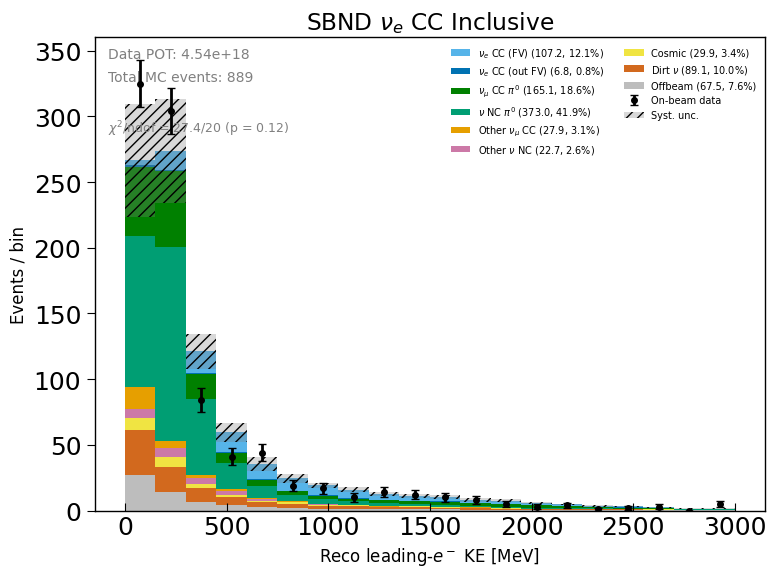

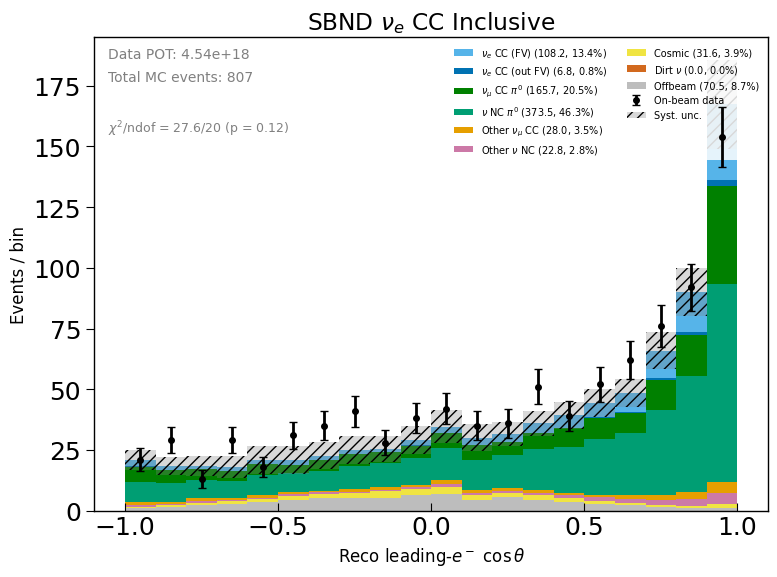

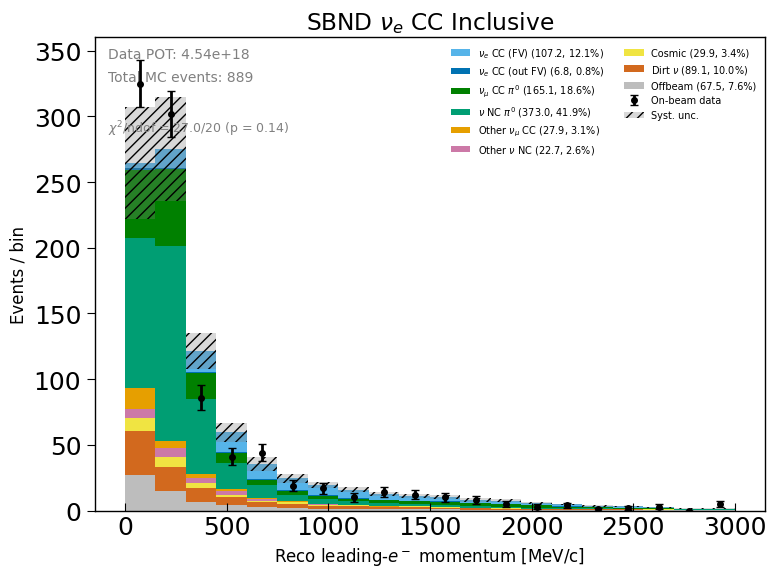

Topology syst+data -> plots_syst/


In [75]:
# ══════════════════════════════════════════════════════════════════════════════
# Topology-stage plots
# ══════════════════════════════════════════════════════════════════════════════
TOPO_STAGE = "sel_single_electron"
TOPO_DISP_BINS = {
    'reco_ke':       np.linspace(0, 3000, 21),
    'reco_costheta': np.linspace(-1, 1,   21),
    'reco_p':        np.linspace(0, 3000, 21),
}
 
for var_name, xlabel in [('reco_ke',       r'Reco leading-$e^-$ KE [MeV]'),
                          ('reco_costheta', r'Reco leading-$e^-$ $\cos\theta$'),
                          ('reco_p',        r'Reco leading-$e^-$ momentum [MeV/c]')]:
    if var_name not in TOPO_DISP_BINS or var_name not in sel_topo.columns:
        continue
    disp_bins = TOPO_DISP_BINS[var_name]
    proxy     = 'reco_costheta' if var_name == 'reco_costheta' else 'reco_ke'
    frac_disp = _frac_unc_sig(proxy, disp_bins)
 
    series_list  = []
    weights_list = []
    for cat in [0,1,2,3,4,5,6]:
        m = sel_topo[TOPO_STAGE] & (sel_topo['truth_cat']==cat) & sel_topo[var_name].notna()
        vals = sel_topo.loc[m,var_name].values
        series_list.append(vals)
        weights_list.append(np.full(len(vals),pot_scale_to_data))
    
    dv = LOWE_RECO_TOPO.get(var_name,np.array([]))
    dv = np.asarray(dv,dtype=float)
    dv = dv[~np.isnan(dv)]
    series_list.append(dv)
    weights_list.append(np.full(len(dv),lowE_pot_scale_to_data))
    
    _add_offbeam(
        series_list,
        weights_list,
        OFFBEAM_RECO_TOPO.get(var_name),
        offbeam_scale)
        
 
    total_cv_t = _total_with_offbeam(series_list, weights_list, disp_bins)
    unc_disp   = frac_disp * total_cv_t
    data_series = DATA_RECO_TOPO.get(var_name)
 
    fig, ax = plt.subplots(figsize=(8, 6))
    nh.plot_stacked_hist(
        series_list=series_list, labels=_labels, colors=_colors,
        bins=disp_bins, weights=weights_list,
        xlabel=xlabel, title=TITLE,
        pot_label=f'Data POT: {data_total_pot:.2e}',
        ax=ax, invert_stack_order=True, show_counts=True, show_percentage=True,
        data_series=data_series, data_label='On-beam data')
    bw = np.diff(disp_bins)
    ax.bar(disp_bins[:-1], 2*unc_disp, bottom=total_cv_t-unc_disp,
           width=bw, align='edge', alpha=0.3, color='gray',
           hatch='///', label='Syst. unc.', linewidth=0)
    if data_series is not None and len(data_series) > 0:
        dc, _ = np.histogram(data_series, bins=disp_bins)
        cov = np.diag(total_cv_t + (frac_disp*total_cv_t)**2)
        ax.text(0.02, 0.80, chi2_text(dc.astype(float), total_cv_t, cov),
                transform=ax.transAxes, fontsize=9, color='gray')
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles, lbls, fontsize=7, ncol=2, loc='upper right',
              frameon=True, framealpha=0.85, edgecolor='none')
    fig.tight_layout()
    savefig(fig, f'{var_name}_topo_with_syst_band_data')
 
print('Topology syst+data -> plots_syst/')

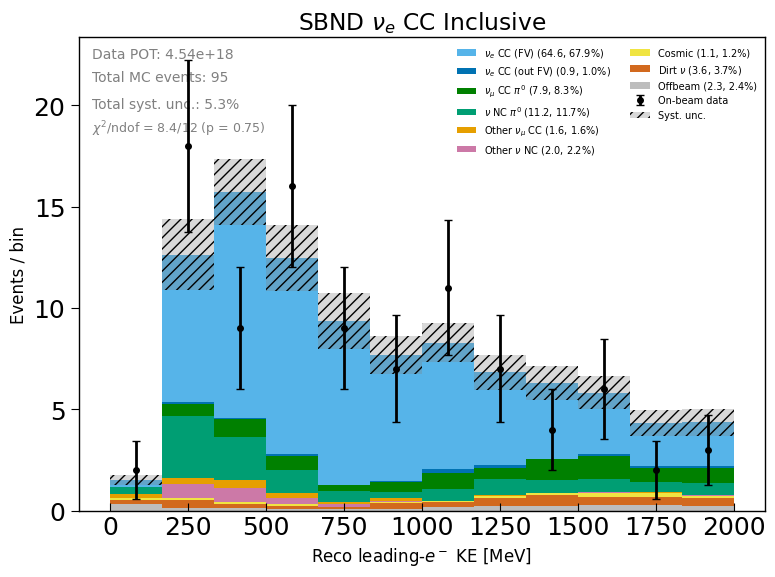

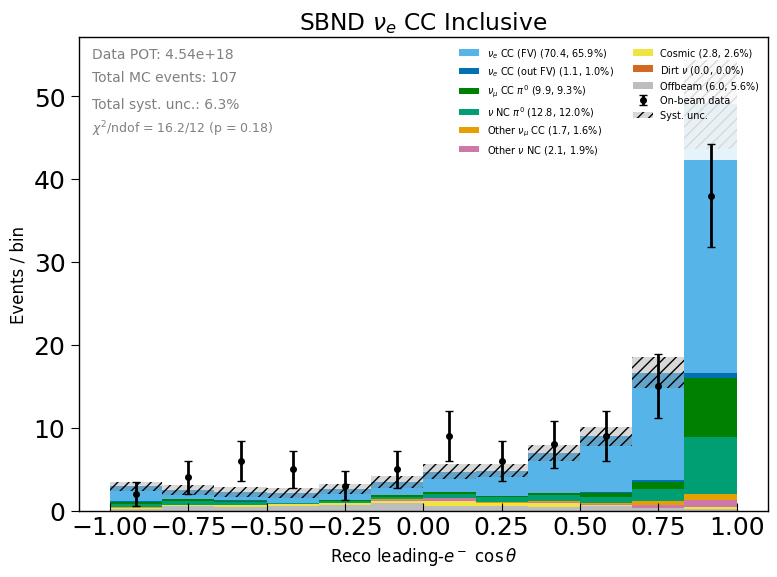

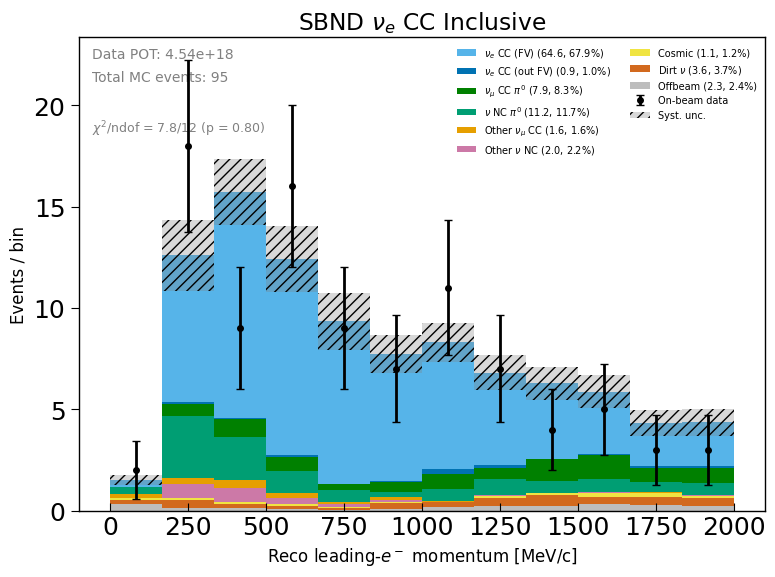

Stacked+syst+data -> plots_syst/


In [76]:
# ══════════════════════════════════════════════════════════════════════════════
# Final-selection plots
# ══════════════════════════════════════════════════════════════════════════════
DISP_BINS_FINAL = {
    'reco_ke':       np.linspace(0, 2000, 13),
    'reco_costheta': np.linspace(-1, 1,   13),
    'reco_p':        np.linspace(0, 2000, 13),
}
_extra_mask = sel_topo['reco_ke'].notna() & sel_topo['reco_costheta'].notna()
 
for var_name, xlabel in [('reco_ke',       r'Reco leading-$e^-$ KE [MeV]'),
                          ('reco_costheta', r'Reco leading-$e^-$ $\cos\theta$'),
                          ('reco_p',        r'Reco leading-$e^-$ momentum [MeV/c]')]:
    if var_name not in DISP_BINS_FINAL or var_name not in sel_topo.columns:
        continue
    disp_bins = DISP_BINS_FINAL[var_name]
    proxy     = 'reco_costheta' if var_name == 'reco_costheta' else 'reco_ke'
    frac_disp = _frac_unc_sig(proxy, disp_bins)
 
    series_list  = []
    weights_list = []
    for cat in [0,1,2,3,4,5,6]:
        m = sel_topo[FINAL_STAGE] & (sel_topo['truth_cat']==cat) & _extra_mask
        vals = sel_topo.loc[m,var_name].dropna().values
        series_list.append(vals)
        weights_list.append(np.full(len(vals),pot_scale_to_data))
    
    dv = LOWE_RECO_FINAL.get(var_name,np.array([]))
    dv = np.asarray(dv,dtype=float)
    dv = dv[~np.isnan(dv)]
    
    series_list.append(dv)
    weights_list.append(np.full(len(dv),lowE_pot_scale_to_data))
    
    _add_offbeam(
        series_list,
        weights_list,
        OFFBEAM_RECO.get(var_name),
        offbeam_scale)
 
    if all(len(s)==0 for s in series_list):
        print(f"  {var_name} empty — skipping"); continue
 
    total_disp = _total_with_offbeam(series_list, weights_list, disp_bins)
    unc_disp   = frac_disp * total_disp
    data_vals  = DATA_RECO.get(var_name)
 
    fig, ax = plt.subplots(figsize=(8, 6))
    nh.plot_stacked_hist(
        series_list=series_list, labels=_labels, colors=_colors,
        bins=disp_bins, weights=weights_list,
        xlabel=xlabel, title=TITLE,
        pot_label=f'Data POT: {data_total_pot:.2e}',
        ax=ax, invert_stack_order=True, show_counts=True, show_percentage=True,
        data_series=data_vals, data_label='On-beam data')
    bw = np.diff(disp_bins)
    ax.bar(disp_bins[:-1], 2*unc_disp, bottom=total_disp-unc_disp,
           width=bw, align='edge', alpha=0.3, color='gray',
           hatch='///', label='Syst. unc.', linewidth=0)
    if data_vals is not None and len(data_vals) > 0:
        dc, _ = np.histogram(data_vals, bins=disp_bins)
        cov = np.diag(total_disp + (frac_disp*total_disp)**2)
        ax.text(0.02, 0.80, chi2_text(dc.astype(float), total_disp, cov),
                transform=ax.transAxes, fontsize=9, color='gray')
    vcfg = next((v for v in VAR_CFGS if v.name == var_name), None)
    if vcfg is not None:
        tv = sum(np.diag(_mat(cov_results[var_name][s]['cov_ms_ms'])).clip(0)
                 for s in cov_results[var_name])
        cv = cv_results[var_name]
        tf = np.sqrt(tv.sum())/cv['sig_cv'].sum() if cv['sig_cv'].sum()>0 else 0
        ax.text(0.02, 0.85, f'Total syst. unc.: {tf*100:.1f}%',
                transform=ax.transAxes, fontsize=10, color='gray')
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles, lbls, fontsize=7, ncol=2, loc='upper right',
              frameon=True, framealpha=0.85, edgecolor='none')
    fig.tight_layout()
    savefig(fig, f'{var_name}_cv_with_syst_band_data')
 
print('Stacked+syst+data -> plots_syst/')

Saved -> ./plots_syst/nuecc_differential_costheta_slices_data.png


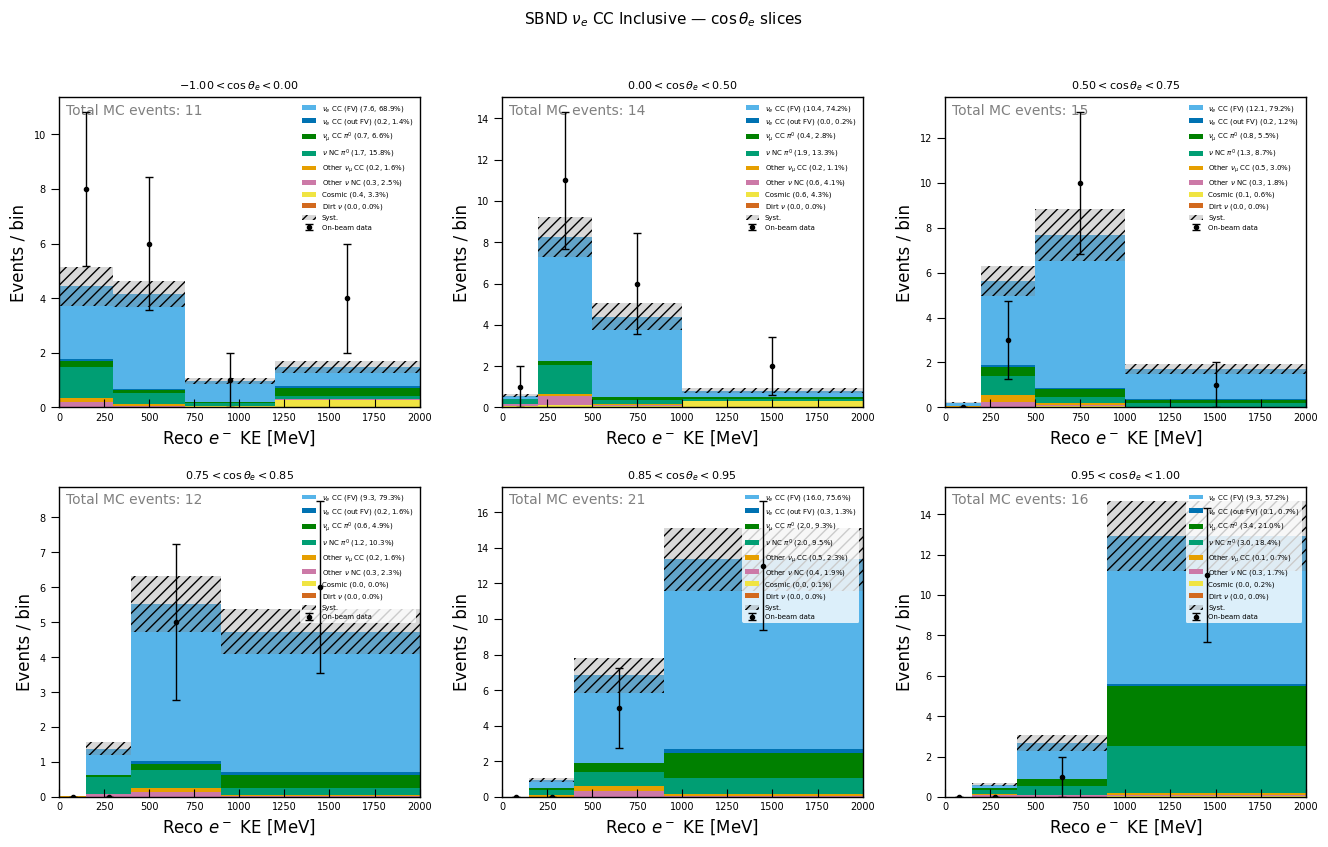

In [77]:
# ══════════════════════════════════════════════════════════════════════════════
# Differential costheta slices
# ══════════════════════════════════════════════════════════════════════════════
from nue_xsec_helpers import make_nuecc_binning2d, plot_nuecc_differential_stacked
import inspect

binning2d_nue = make_nuecc_binning2d()

cv_ke        = cv_results['reco_ke']
covs_ke      = cov_results['reco_ke']
total_var_ke = sum(np.diag(_mat(covs_ke[s]['cov_ms_ms'])).clip(0) for s in covs_ke)
frac_unc_ke  = np.where(cv_ke['sig_cv'] > 0,
                        np.sqrt(total_var_ke) / cv_ke['sig_cv'], 0.0)

_diff_kwargs = dict(
    sel_df               = sel_topo,
    stage_col            = FINAL_STAGE,
    ke_col               = 'reco_ke',
    costheta_col         = 'reco_costheta',
    truth_cat_col        = 'truth_cat',
    binning2d            = binning2d_nue,
    display_cats         = [0,1,2,3,4,5,6,9],
    labels               = [nh.CAT_LABELS[c] for c in [0,1,2,3,4,5,6,9]],
    colors               = [nh.CAT_COLORS[c] for c in [0,1,2,3,4,5,6,9]],
    pot_scale            = pot_scale_to_data,
    pot_label            = f'Data POT: {data_total_pot:.2e}',
    frac_unc_ke          = frac_unc_ke,
    reco_ke_bins         = VAR_CFGS[0].bins,
    title                = fr'{TITLE} — $\cos\theta_e$ slices',
    plot_dir             = PLOT_DIR,
    filename             = 'nuecc_differential_costheta_slices_data',
    plot_stacked_hist_fn = nh.plot_stacked_hist,

    offbeam_ke           = OFFBEAM_RECO.get('reco_ke', np.array([])),
    offbeam_cos          = OFFBEAM_RECO.get('reco_costheta', np.array([])),
    offbeam_weight       = offbeam_scale,

    dirt_ke              = LOWE_RECO_FINAL.get('reco_ke', np.array([])),
    dirt_cos             = LOWE_RECO_FINAL.get('reco_costheta', np.array([])),
    dirt_weight          = lowE_pot_scale_to_data,
)

_sig = inspect.signature(plot_nuecc_differential_stacked)

if 'data_ke' in _sig.parameters:
    _diff_kwargs['data_ke'] = DATA_RECO.get('reco_ke')
    _diff_kwargs['data_cos'] = DATA_RECO.get('reco_costheta')
    _diff_kwargs['data_label'] = 'On-beam data'

if 'dirt_ke' not in _sig.parameters:
    _diff_kwargs.pop('dirt_ke', None)
    _diff_kwargs.pop('dirt_cos', None)
    _diff_kwargs.pop('dirt_weight', None)

if 'offbeam_ke' not in _sig.parameters:
    _diff_kwargs.pop('offbeam_ke', None)
    _diff_kwargs.pop('offbeam_cos', None)
    _diff_kwargs.pop('offbeam_weight', None)

fig, axs = plot_nuecc_differential_stacked(**_diff_kwargs)


load_evtdf_slim  mode='reco_min_true'  key='evt_0'
  Total cols :  393  →  kept:  124  dropped:  269  (68% reduced)
  Group                            all   kept
  ------------------------------------------
  dlp_reco_interaction              32     32
  dlp_reco_particle                 72     72
  dlp_true_interaction              68      0  ← dropped 68
  dlp_true_particle                113     16  ← dropped 97
  mcnu                             104      0  ← dropped 104
  index_artifact                     4      4
  other                              0      0

  Loading full df then dropping columns (fixed-format HDF5) …
  Post-drop complete. Final shape: (4597004, 124)
pid_score: MC=28,494  Data=922  Dirt=6,950
  After topology cut / Leading electron PID score:
    Data/Pred = 1.112 ± 0.037 (stat.) ± 0.037 (syst.)
    chi2/ndf = 12.2/40  p = 1.000


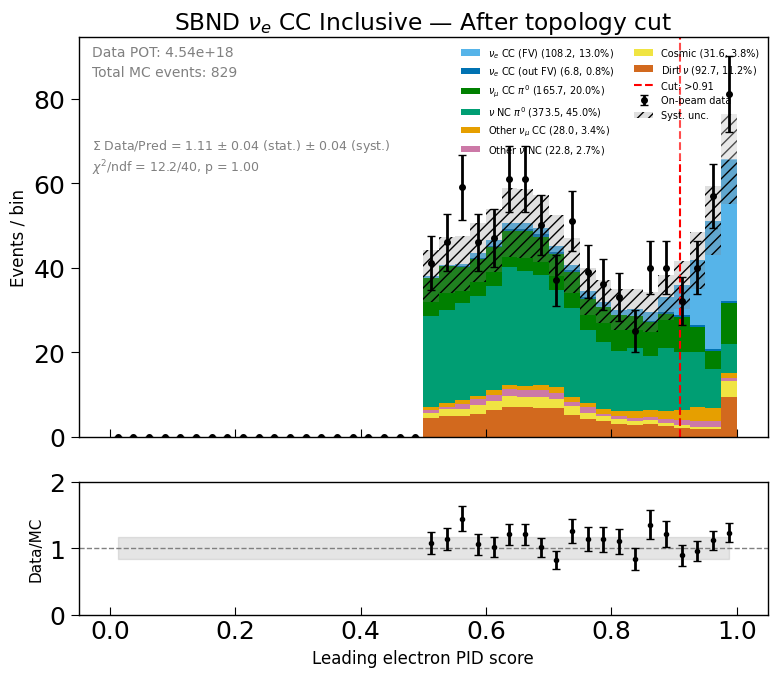

primary_score: MC=28,494  Data=922  Dirt=6,950
  After topology cut / Leading electron primary score:
    Data/Pred = 1.112 ± 0.037 (stat.) ± 0.112 (syst.)
    chi2/ndf = 22.3/40  p = 0.990


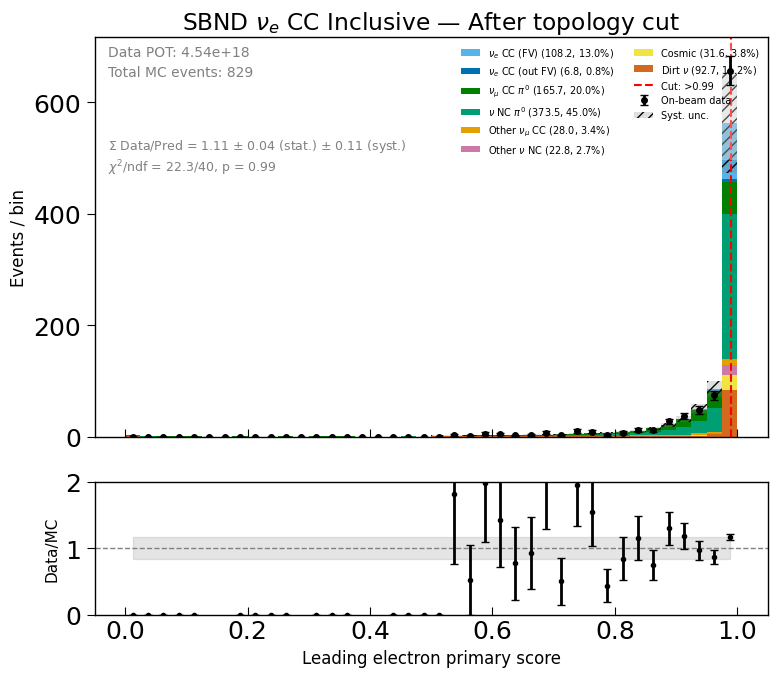

vertex_dist: MC=28,494  Data=922  Dirt=6,950
  After topology cut / Vertex distance [cm]:
    Data/Pred = 1.073 ± 0.039 (stat.) ± 0.075 (syst.)
    chi2/ndf = 49.7/40  p = 0.140


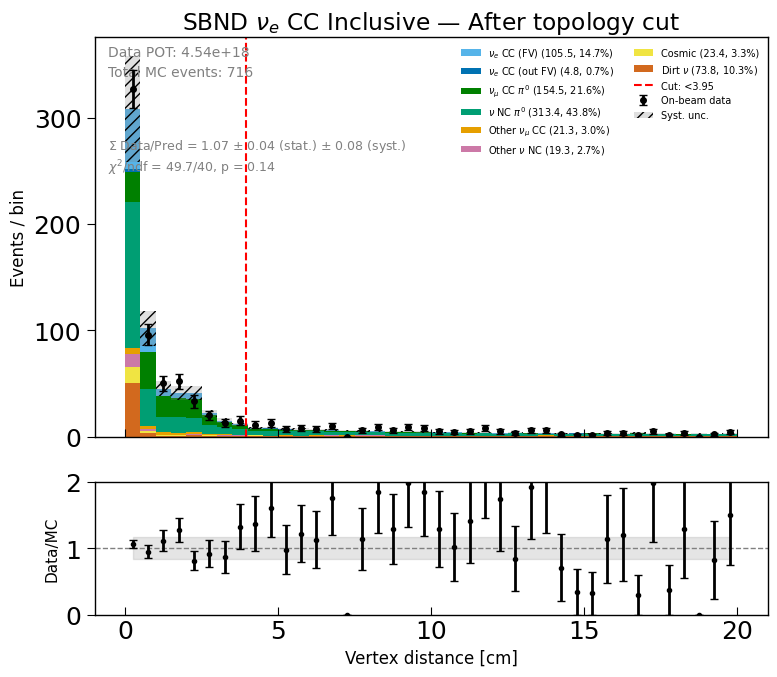

calo_ke: MC=28,494  Data=922  Dirt=6,950
  After topology cut / Leading electron calo KE [MeV]:
    Data/Pred = 1.029 ± 0.034 (stat.) ± 0.047 (syst.)
    chi2/ndf = 54.8/40  p = 0.060


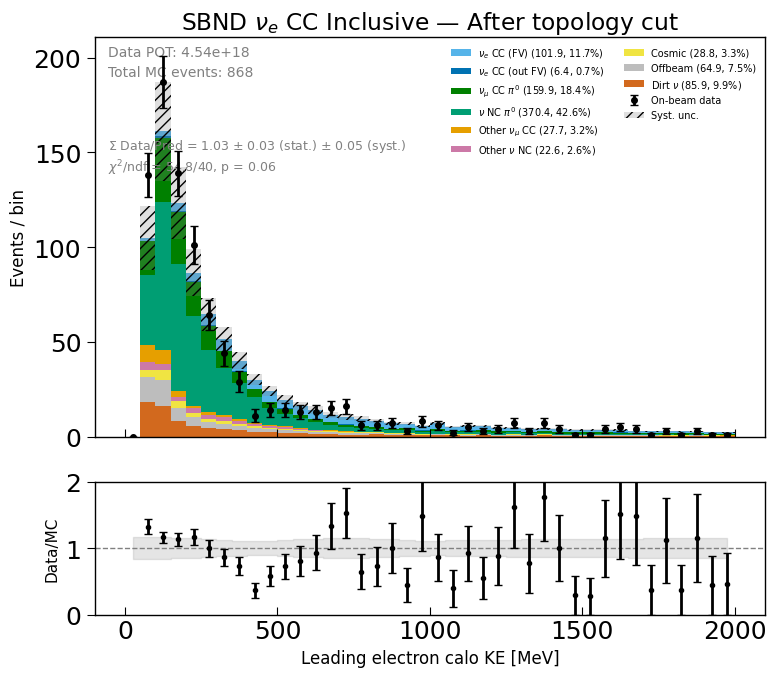

Extra variable plots -> ./plots_syst/


4746

In [78]:
# ══════════════════════════════════════════════════════════════════════════════
# Extra selection variables
# ══════════════════════════════════════════════════════════════════════════════
from mem_optimizer import load_evtdf_slim

mc_evtdf_extra = load_evtdf_slim(DF_FILE, key="evt_0", mode="reco_min_true")
mc_il_extra    = list(range(mc_evtdf_extra.index.nlevels - 1))

mc_se_idx      = sel_topo.index[sel_topo["sel_single_electron"]]
truth_cat_topo = sel_topo.loc[mc_se_idx,"truth_cat"]

lowE_se_idx = lowE_cut_flow["single_electron"]["inter_index"]

nh.plot_extra_selection_vars(
    mc_evtdf=mc_evtdf_extra,
    data_evtdf=data_evtdf_patched,
    sel_topo=sel_topo,
    mc_se_idx=mc_se_idx,
    data_se_idx=data_cut_flow["single_electron"]["inter_index"],
    mc_il=mc_il_extra,
    data_il=data_il,
    truth_cat_at_topo=truth_cat_topo,
    pot_scale_to_data=pot_scale_to_data,
    data_total_pot=data_total_pot,
    cov_results=cov_results,
    cv_results=cv_results,
    var_cfgs=VAR_CFGS,
    chi2_text_fn=chi2_text,
    savefig_fn=savefig,
    title=TITLE,
    data_label='On-beam data',
    plot_dir=PLOT_DIR,
    offbeam_shower_vars=OFFBEAM_SHOWER_VARS,
    offbeam_weight=offbeam_scale,
    dirt_evtdf=lowE_evtdf,
    dirt_se_idx=lowE_cut_flow["single_electron"]["inter_index"],
    dirt_il=lowE_il,
    dirt_weight=lowE_pot_scale_to_data,
)

del mc_evtdf_extra
gc.collect()

In [79]:
# # Check what fraction of weights are NaN in wgt_aligned
# nan_frac = wgt_aligned[bnb_cols_aligned].isna().mean().mean()
# print(f'NaN fraction in BNB weights: {nan_frac:.1%}')

# # Check a few weight values for matched rows
# matched = wgt_aligned[bnb_cols_aligned[0]].notna()
# print(f'Matched interactions: {matched.sum()} / {len(matched)}')
# print(wgt_aligned.loc[matched, bnb_cols_aligned[:3]].describe())

In [80]:
for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    scale = pot_scale  # your pot_scale from the selection notebook
    print(f"\n{vcfg.name} — estimated raw MC events per bin:")
    print(f"  signal : {np.round(cv['sig_cv'] / scale, 1)}")
    print(f"  bkg    : {np.round(cv['bkg_cv'] / scale, 1)}")


reco_ke — estimated raw MC events per bin:
  signal : [145. 619. 476. 354. 254. 174. 314.]
  bkg    : [129. 238.  80.  81.  98. 105. 279.]

reco_costheta — estimated raw MC events per bin:
  signal : [  63.   44.   43.   56.   59.   99.  144.  213.  431. 1184.]
  bkg    : [ 37.  35.  21.  21.  37.  61.  51.  75. 107. 565.]


## 17. Unfolding with Omnifold 

In [81]:
# ── Export per-bin efficiency + flux/targets for OmniFold xsec ────────────────
import numpy as np, os

OMNIFOLD_OUT = '/home/castalyf/Omnifold_SBND/sbnd/exported_weights/'
os.makedirs(OMNIFOLD_OUT, exist_ok=True)

RECO_VARS   = ['reco_ke', 'reco_costheta', 'reco_p']
FINAL_STAGE = 'sel_vertex_distance'

sig_all = sel_topo[sel_topo['is_sig']]
sig_sel = sel_topo[sel_topo['is_sig'] & sel_topo[FINAL_STAGE]].copy()
reco_raw = sig_sel[RECO_VARS].values.astype(np.float32)
sig_sel_valid = sig_sel[~np.isnan(reco_raw).any(axis=1)]

bins_ke  = np.array([0, 200, 400, 600, 800, 1000, 1400, 2000])
bins_cos = np.linspace(-1, 1, 11)

for var, bins, label in [('true_ke', bins_ke, 'true_ke'),
                          ('true_costheta', bins_cos, 'true_costheta')]:
    N_all, _ = np.histogram(sig_all[var].dropna(), bins=bins)
    N_sel, _ = np.histogram(sig_sel_valid[var].dropna(), bins=bins)
    eff = N_sel / N_all.clip(1)
    np.save(OMNIFOLD_OUT + f'efficiency_{label}.npy', eff)
    centers = 0.5 * (bins[:-1] + bins[1:])
    print(f"\n{label} efficiency:")
    for c, e, na, ns in zip(centers, eff, N_all, N_sel):
        print(f"  {c:8.1f}: {e:.4f}  ({ns}/{na})")

# Save pot_scale and N_targets for cross-section normalization
pot_scale = float(sel_topo['pot_scale'].iloc[0])
np.save(OMNIFOLD_OUT + 'pot_scale.npy', np.array([pot_scale]))
print(f"\npot_scale: {pot_scale}")
print("Saved efficiency and normalization files.")


true_ke efficiency:
     100.0: 0.0879  (24/273)
     300.0: 0.4639  (347/748)
     500.0: 0.5835  (395/677)
     700.0: 0.6090  (324/532)
     900.0: 0.7147  (278/389)
    1200.0: 0.7854  (410/522)
    1700.0: 0.8150  (326/400)

true_costheta efficiency:
      -0.9: 0.3333  (20/60)
      -0.7: 0.4156  (32/77)
      -0.5: 0.2857  (34/119)
      -0.3: 0.3590  (42/117)
      -0.1: 0.4388  (61/139)
       0.1: 0.5112  (91/178)
       0.3: 0.4743  (129/272)
       0.5: 0.5470  (221/404)
       0.7: 0.6364  (427/671)
       0.9: 0.7267  (1279/1760)

pot_scale: 4.386173725128174
Saved efficiency and normalization files.
